In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import os 
import shutil
# below imports are used to print out pretty pandas dataframes
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
plt.style.use('ggplot')

# information used to create a database connection
sqluser = 'postgres'
dbname = 'mimic'
schema_name = 'mimiciii'

# Connect to postgres with a copy of the MIMIC-III database
con = psycopg2.connect(dbname=dbname, user=sqluser, password=sqluser)

# the below statement is prepended to queries to ensure they select from the right schema
query_schema = 'set search_path to ' + schema_name + ';'

In [23]:
query = query_schema + """
SELECT DISTINCT DIAGNOSES_ICD.subject_id
FROM icustays
JOIN DIAGNOSES_ICD ON DIAGNOSES_ICD.subject_id = icustays.subject_id
WHERE icd9_code IN {ARDS_list}
"""

ARDS_list = ('51881', '51882', '51884', '51851', '51852', '51853', '769')
ARDS_list = ('51882', 'None')
# df = pd.read_sql_query(query, con)
df = pd.read_sql_query(query.format(ARDS_list=ARDS_list), con)

# df = pd.read_sql_query(query, con)

subject_id = df.sample(1, random_state=0).values[0, 0]

print(f"Subject {subject_id} selected randomly from a cohort of {len(df)} patients.")

Subject 30941 selected randomly from a cohort of 404 patients.


In [25]:
patient_path = "patients/" + str(subject_id) + "/"
info_path = patient_path + "info/"
if os.path.exists(patient_path):
    shutil.rmtree(patient_path)
    
os.mkdir(patient_path)
os.mkdir(info_path)

def save_info(df, info_name):
    path_csv = info_path + info_name + ".csv"
    df.head(100).to_csv(path_csv)

In [26]:
query = query_schema + """
SELECT *
FROM PATIENTS
WHERE subject_id = {subject_id}
"""
df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "PATIENT")
df.head()

Number of rows : 1


,row_id,subject_id,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,29081,30941,F,2022-01-16,2103-01-06,2103-01-06,2103-01-06,1


In [27]:
query = query_schema + """
SELECT *
FROM ADMISSIONS
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "ADMISSIONS")
df.head()

Number of rows : 1


,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,37664,30941,164022,2102-12-18 18:16:00,2103-01-06 01:30:00,2103-01-06 01:30:00,EMERGENCY,EMERGENCY ROOM ADMIT,DEAD/EXPIRED,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,2102-12-18 14:17:00,2102-12-18 21:03:00,PNEUMONIA,1,1


In [28]:
query = query_schema + """
SELECT *
FROM ICUSTAYS
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "ICUSTAYS")
df.head()

Number of rows : 1


,row_id,subject_id,hadm_id,icustay_id,dbsource,first_careunit,last_careunit,first_wardid,last_wardid,intime,outtime,los
0,39129,30941,164022,276555,carevue,MICU,MICU,52,52,2102-12-18 18:47:37,2103-01-06 05:27:19,18.4442


In [29]:
query = query_schema + """
SELECT *
FROM DIAGNOSES_ICD
JOIN D_ICD_DIAGNOSES ON D_ICD_DIAGNOSES.icd9_code = DIAGNOSES_ICD.icd9_code
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "DIAGNOSES")
df.head(11)

Number of rows : 14


,row_id,subject_id,hadm_id,seq_num,icd9_code,row_id,icd9_code,short_title,long_title
0,355881,30941,164022,1,03843,656,03843,Pseudomonas septicemia,Septicemia due to pseudomonas
1,355882,30941,164022,2,4821,5502,4821,Pseudomonal pneumonia,Pneumonia due to Pseudomonas
2,355883,30941,164022,3,5849,5908,5849,Acute kidney failure NOS,"Acute kidney failure, unspecified"
3,355884,30941,164022,4,2762,2787,2762,Acidosis,Acidosis
4,355885,30941,164022,5,51882,5280,51882,Other pulmonary insuff,"Other pulmonary insufficiency, not elsewhere c..."
5,355886,30941,164022,6,43311,4510,43311,Ocl crtd art w infrct,Occlusion and stenosis of carotid artery with ...
6,355887,30941,164022,7,99592,11404,99592,Severe sepsis,Severe sepsis
7,355888,30941,164022,8,3320,3621,3320,Paralysis agitans,Paralysis agitans
8,355889,30941,164022,9,27651,2155,27651,Dehydration,Dehydration
9,355890,30941,164022,10,4589,5396,4589,Hypotension NOS,"Hypotension, unspecified"


In [30]:
query = query_schema + """
SELECT *
FROM PROCEDURES_ICD
JOIN D_ICD_PROCEDURES ON D_ICD_PROCEDURES.icd9_code = PROCEDURES_ICD.icd9_code
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "PROCEDURES")
df.head(7)

Number of rows : 9


,row_id,subject_id,hadm_id,seq_num,icd9_code,row_id,icd9_code,short_title,long_title
0,155815,30941,164022,1,311,552,311,Temporary tracheostomy,Temporary tracheostomy
1,155816,30941,164022,2,4311,1528,4311,Percu endosc gastrostomy,Percutaneous [endoscopic] gastrostomy [PEG]
2,155817,30941,164022,3,3893,801,3893,Venous cath NEC,"Venous catheterization, not elsewhere classified"
3,155818,30941,164022,4,9604,3607,9604,Insert endotracheal tube,Insertion of endotracheal tube
4,155819,30941,164022,5,9672,3679,9672,Cont inv mec ven 96+ hrs,Continuous invasive mechanical ventilation for...
5,155820,30941,164022,6,966,3676,966,Entral infus nutrit sub,Enteral infusion of concentrated nutritional s...
6,155821,30941,164022,7,9605,3608,9605,Resp tract intubat NEC,Other intubation of respiratory tract


In [31]:
query = query_schema + """
SELECT *
FROM NOTEEVENTS
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
df.head(10)

Number of rows : 105


,row_id,subject_id,hadm_id,chartdate,charttime,storetime,category,description,cgid,iserror,text
0,989277,30941,164022,2102-12-18,2102-12-18 14:58:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-18**] 2:58 PM\n CHEST (PORTABLE AP)...
1,989284,30941,164022,2102-12-18,2102-12-18 15:29:00,NaT,Radiology,CT HEAD W/O CONTRAST,NaN,None,[**2102-12-18**] 3:29 PM\n CT HEAD W/O CONTRAS...
2,990165,30941,164022,2102-12-24,2102-12-24 05:03:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-24**] 5:03 AM\n CHEST (PORTABLE AP)...
3,989329,30941,164022,2102-12-19,2102-12-19 05:50:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-19**] 5:50 AM\n CHEST (PORTABLE AP)...
4,989387,30941,164022,2102-12-19,2102-12-19 11:09:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-19**] 11:09 AM\n CHEST (PORTABLE AP...
5,989459,30941,164022,2102-12-19,2102-12-19 18:12:00,NaT,Radiology,CHEST PORT. LINE PLACEMENT,NaN,None,[**2102-12-19**] 6:12 PM\n CHEST PORT. LINE PL...
6,989490,30941,164022,2102-12-19,2102-12-19 23:35:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-19**] 11:35 PM\n CHEST (PORTABLE AP...
7,989690,30941,164022,2102-12-21,2102-12-21 04:55:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-21**] 4:55 AM\n CHEST (PORTABLE AP)...
8,989865,30941,164022,2102-12-22,2102-12-22 05:36:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-22**] 5:36 AM\n CHEST (PORTABLE AP)...
9,990032,30941,164022,2102-12-23,2102-12-23 05:20:00,NaT,Radiology,CHEST (PORTABLE AP),NaN,None,[**2102-12-23**] 5:20 AM\n CHEST (PORTABLE AP)...


In [32]:
note_path = patient_path + "doctor_notes" + "/"
if not os.path.exists(note_path):
    os.mkdir(note_path)
else:
    shutil.rmtree(note_path)
    os.mkdir(note_path)
    
notes = df["text"]
notes_all = ""
for i, note in enumerate(notes):
    with open(note_path+f"note_{i}.txt", 'w') as f:
        f.write(note)
    print(note)
    notes_all += note
with open(note_path+f"all_notes.txt", 'w') as f:
        f.write(notes_all)

[**2102-12-18**] 2:58 PM
 CHEST (PORTABLE AP)                                             Clip # [**Clip Number (Radiology) 95185**]
 Reason: please eval for PNA
 ______________________________________________________________________________
 [**Hospital 2**] MEDICAL CONDITION:
  80 yo F p/w ALOC and cough recently, afebrile, diminished bibasilar lung sounds
 REASON FOR THIS EXAMINATION:
  please eval for PNA
 ______________________________________________________________________________
                                 FINAL REPORT
 AP CHEST

 INDICATION:  80-year-old female with acute loss of consciousness and cough.
 Diminished bibasilar lung sounds.

 COMPARISON:  Not available.

 FINDINGS:  Evaluation is limited by suboptimal technique, patient is markedly
 rotated to the right. Cardiac silhouette is enlarged.  Lung volumes are low,
 with a greater degree of volume loss on the left. Left lower lobe opacity
 likely represents combination of consolidation and collapse; pleural effus

In [33]:
query = query_schema + """
SELECT *
FROM PROCEDUREEVENTS_MV
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
df.head()

Number of rows : 0


,row_id,subject_id,hadm_id,icustay_id,starttime,endtime,itemid,value,valueuom,location,...,ordercategoryname,secondaryordercategoryname,ordercategorydescription,isopenbag,continueinnextdept,cancelreason,statusdescription,comments_editedby,comments_canceledby,comments_date


In [34]:
query = query_schema + """
SELECT *
FROM CHARTEVENTS
JOIN D_ITEMS ON CHARTEVENTS.itemid = D_ITEMS.itemid
WHERE subject_id = {subject_id}
"""

df_CHARTEVENTS = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df_CHARTEVENTS))
df_CHARTEVENTS.head()

Number of rows : 25015


,row_id,subject_id,hadm_id,icustay_id,itemid,charttime,storetime,cgid,value,valuenum,...,row_id,itemid,label,abbreviation,dbsource,linksto,category,unitname,param_type,conceptid
0,186096739,30941,164022,276555,1089,2102-12-19 08:00:00,2102-12-19 09:24:00,20814,Yes,NaN,...,1236,1089,PainLevel Acceptable,None,carevue,chartevents,None,None,None,None
1,186110535,30941,164022,276555,1089,2103-01-03 04:00:00,2103-01-03 06:51:00,14605,Yes,NaN,...,1236,1089,PainLevel Acceptable,None,carevue,chartevents,None,None,None,None
2,186110611,30941,164022,276555,1089,2103-01-03 06:30:00,2103-01-03 06:51:00,14605,Yes,NaN,...,1236,1089,PainLevel Acceptable,None,carevue,chartevents,None,None,None,None
3,186110893,30941,164022,276555,1089,2103-01-03 14:00:00,2103-01-03 14:25:00,20814,Other/Remarks,NaN,...,1236,1089,PainLevel Acceptable,None,carevue,chartevents,None,None,None,None
4,186096659,30941,164022,276555,50,2102-12-19 08:00:00,2102-12-19 10:48:00,21319,20,20.0,...,56,50,Apnea Time Interval,None,carevue,chartevents,None,None,None,None


In [35]:
query = query_schema + """
SELECT DISTINCT label
FROM CHARTEVENTS
JOIN D_ITEMS ON CHARTEVENTS.itemid = D_ITEMS.itemid
WHERE subject_id = {subject_id}
"""
df_CHARTEVENTS = pd.read_sql_query(query.format(subject_id=subject_id), con)
save_info(df_CHARTEVENTS, "LABELS_CHARTEVENTS")

query = query_schema + """
SELECT charttime, label, value, valueuom
FROM CHARTEVENTS
JOIN D_ITEMS ON CHARTEVENTS.itemid = D_ITEMS.itemid
WHERE subject_id = {subject_id}
"""

df_CHARTEVENTS = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df_CHARTEVENTS))
df_CHARTEVENTS.sample(frac=1, random_state=0).head(50)

Number of rows : 25015


,charttime,label,value,valueuom
6151,2102-12-26 12:00:00,Turn,Side to Side,None
17527,2103-01-03 04:00:00,Pain Level,Unable to score,None
8272,2102-12-25 08:00:00,INV Line#1 [Type],Multi-lumen,None
12177,2102-12-29 22:00:00,Heart Rhythm,Normal Sinus,None
9187,2102-12-29 10:00:00,ETT Position Change,Done,None
18618,2102-12-25 21:00:00,Arterial BP Mean,63,mmHg
16352,2102-12-22 17:00:00,Service Type,MSICU,None
18795,2102-12-25 18:00:00,Risk for Falls,Yes,None
5435,2102-12-24 09:00:00,Heart Rate,98,BPM
6010,2102-12-28 12:00:00,HOB,30 degrees,None


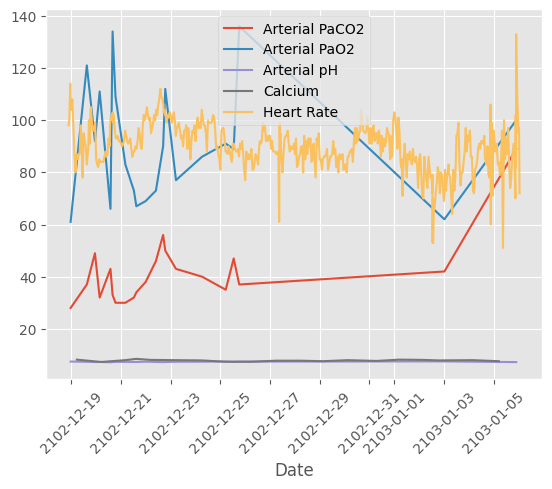

In [36]:
plot_path = patient_path + "plots" + "/"
if not os.path.exists(plot_path):
    os.mkdir(plot_path)
else:
    shutil.rmtree(plot_path)
    os.mkdir(plot_path)

num_list = ["temp axiliary", "SaO2", "Resp Rate", "Present Weight (kg)",
            "Heart Rate", "Glucometer", "BP Cuff [Systolic]", "Arterial PaCO2", "Arterial PaO2", "Arterial pH", "Calcium"]

for label in np.unique(num_list):
    # try:
    df_work_of_breathing = df_CHARTEVENTS[df_CHARTEVENTS["label"]==label]
    if len(df_work_of_breathing) != 0:
    # if None not in list(df_work_of_breathing["value"]) and len(list(df_work_of_breathing["value"]))>1:
    #     try:
    # print(label)
    # print(list(df_work_of_breathing["value"]))
        list_plot = list(map(float, list(df_work_of_breathing["value"])))
        plt.plot(df_work_of_breathing["charttime"], list_plot, '-', label=label)
        plt.xlabel("Date")
        plt.xticks(rotation=45)
            # except Exception as e:
            # 	print("ERROR 1: "+str(e))
            #     # list_plot = df_work_of_breathing["value"]
            
    # except Exception as e:
    # 	print("ERROR : "+str(e))
        # pass

plt.legend()
plt.savefig(plot_path+f'a_total.png')
plt.show()

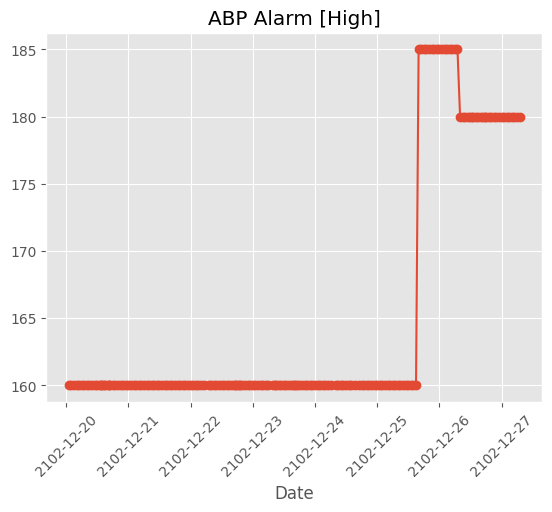

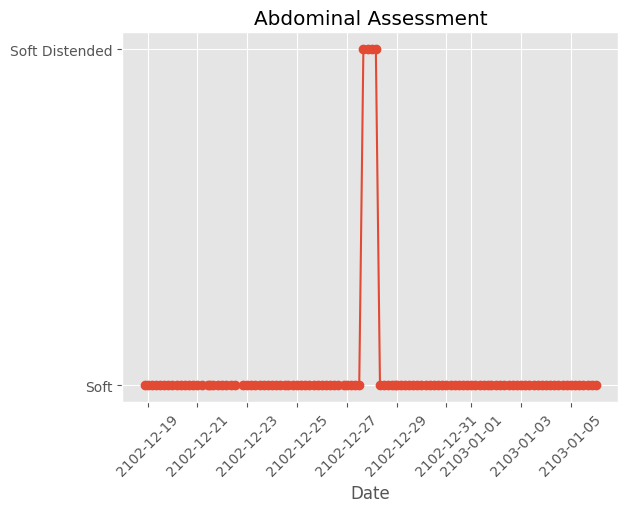

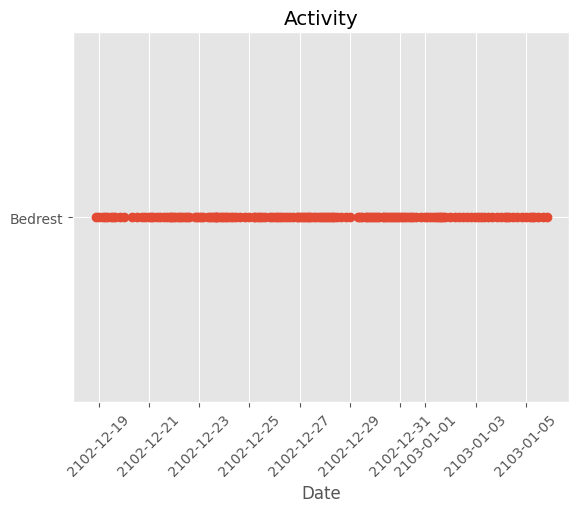

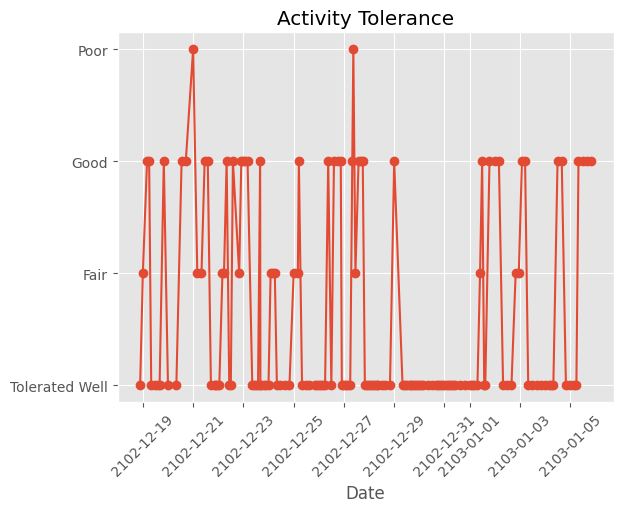

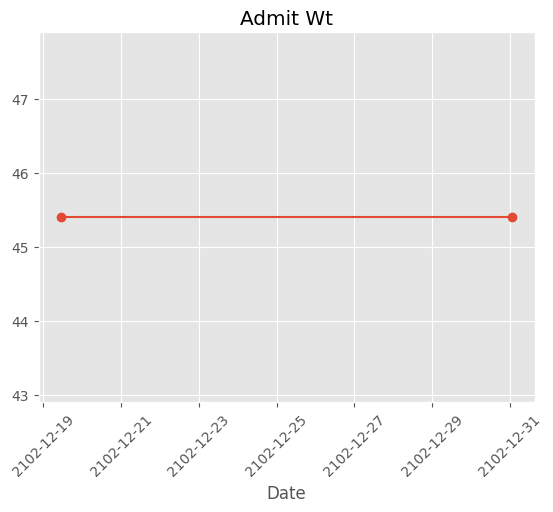

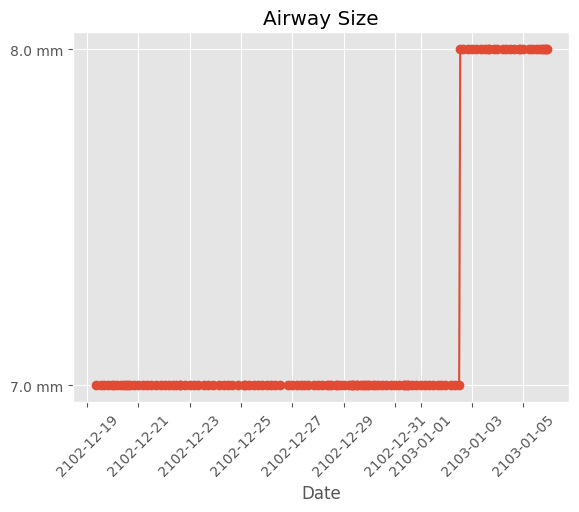

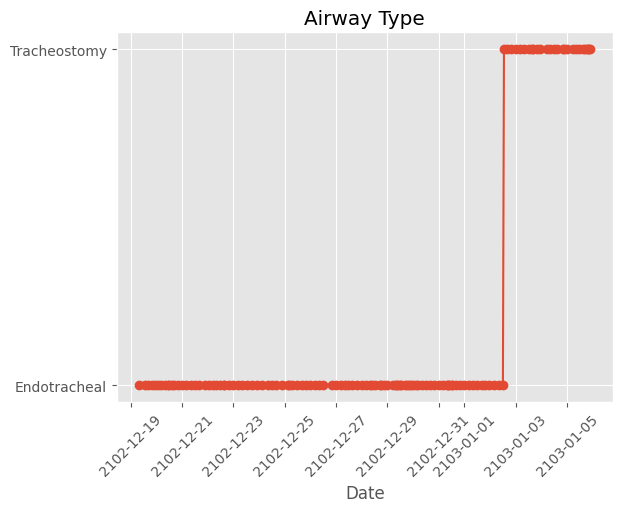

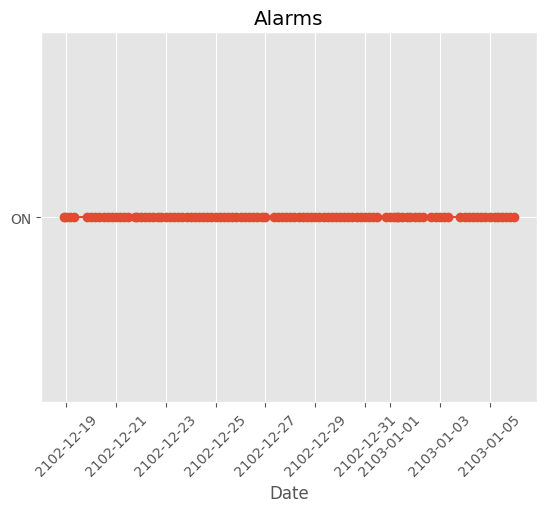

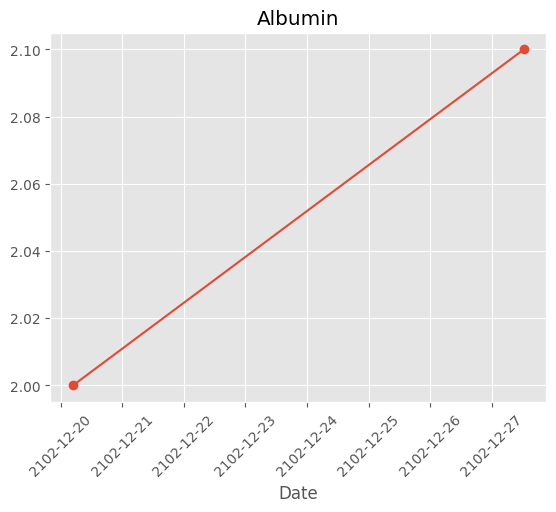

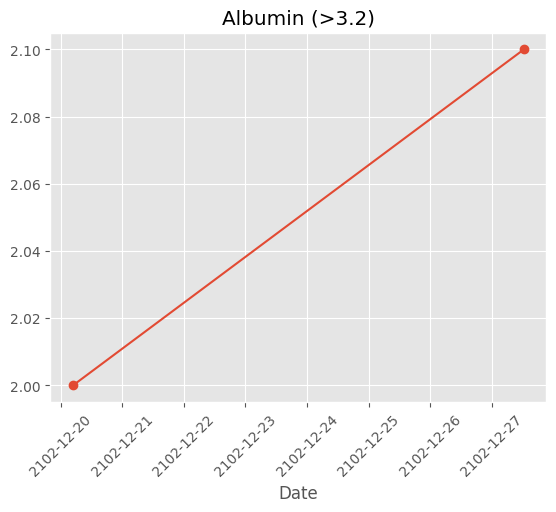

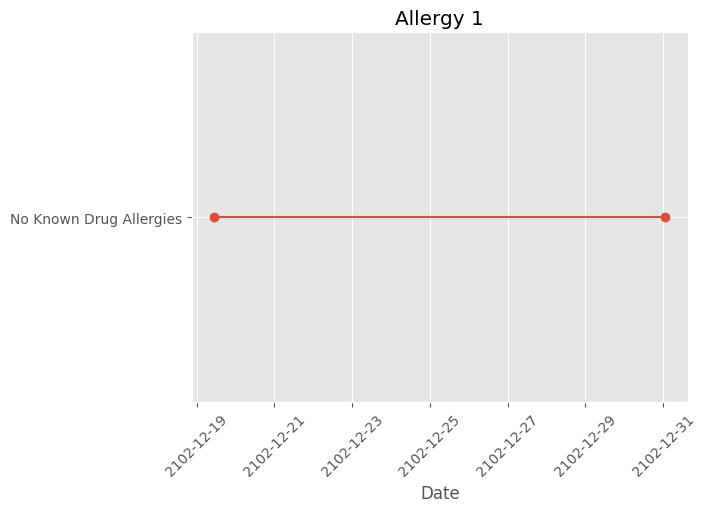

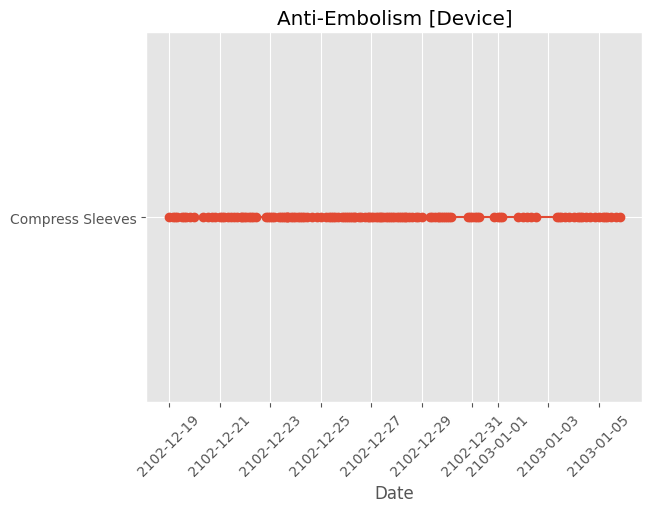

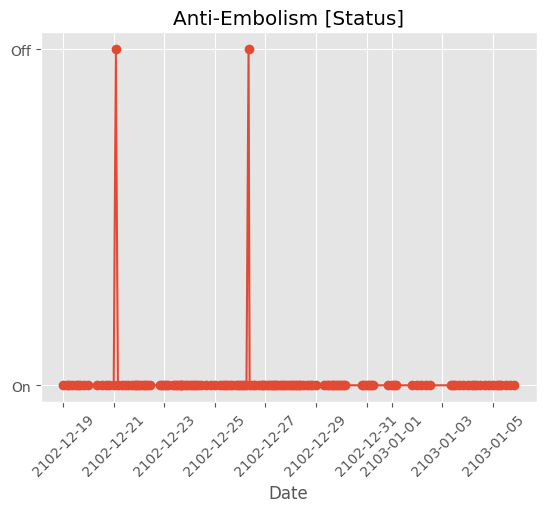

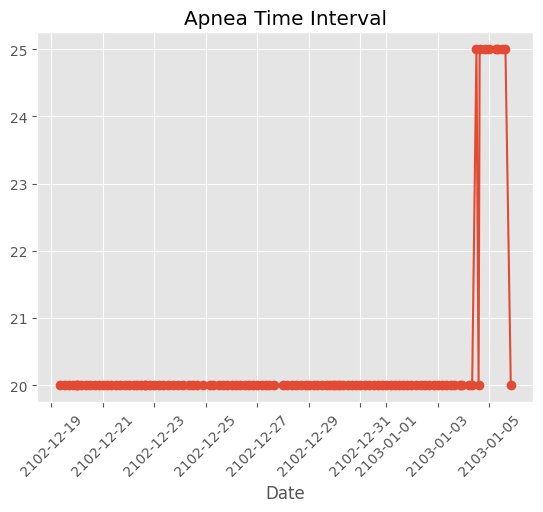

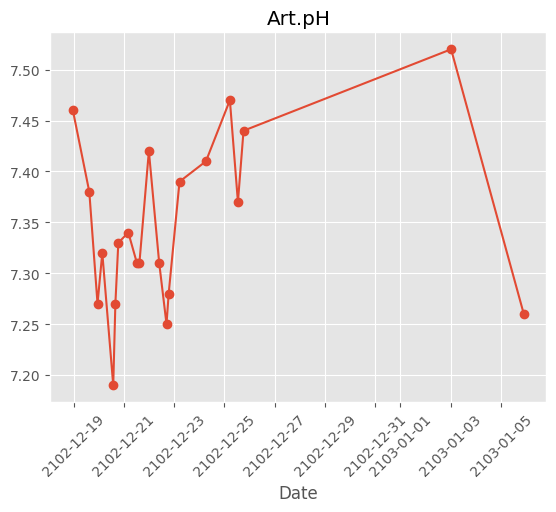

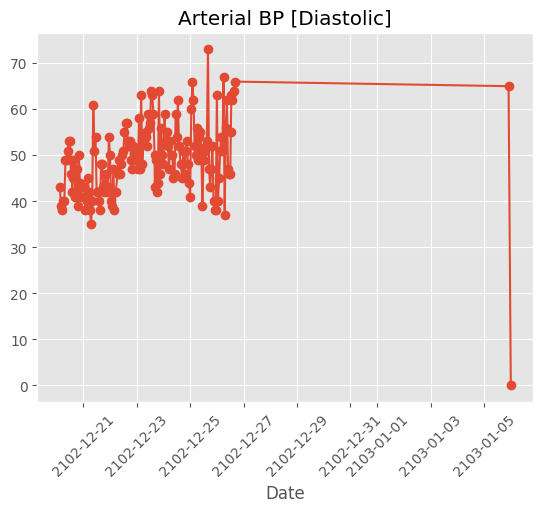

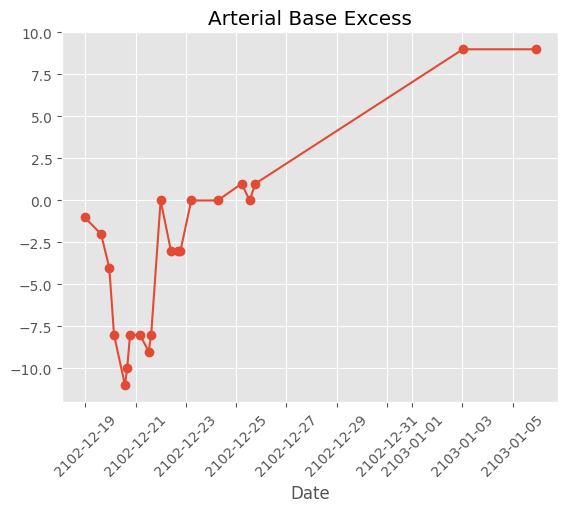

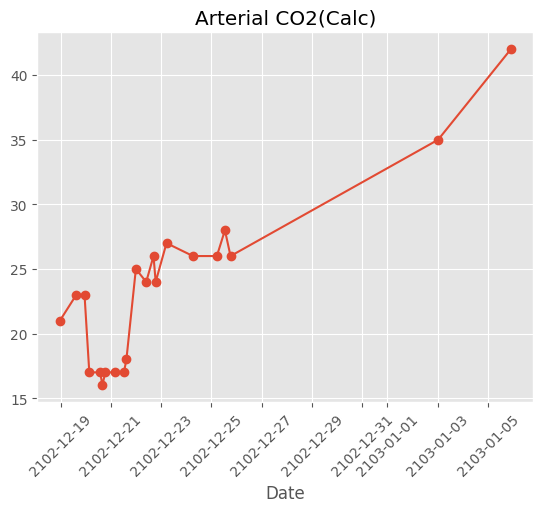

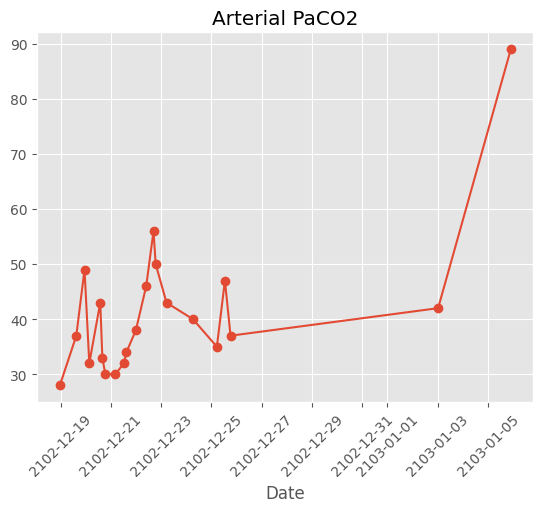

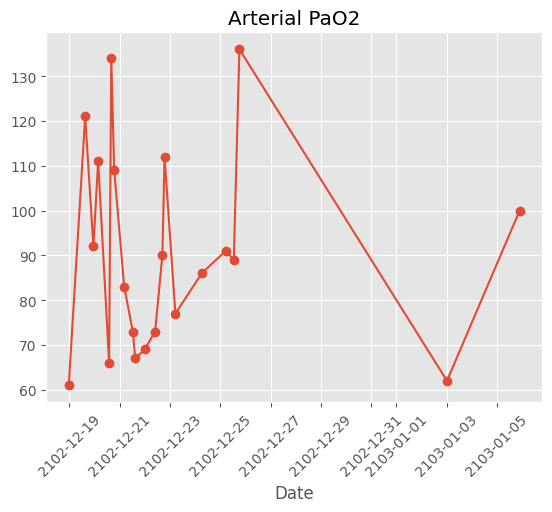

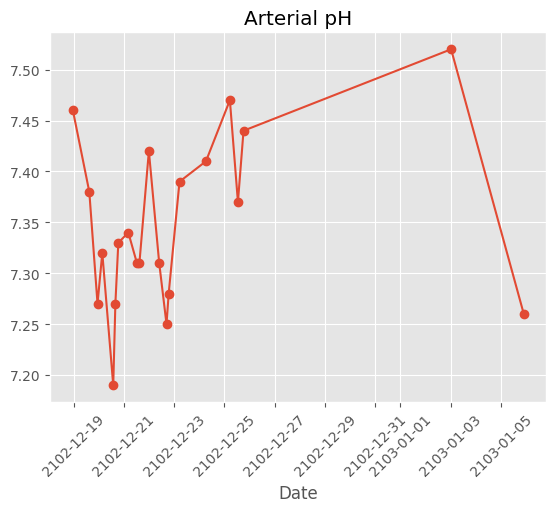

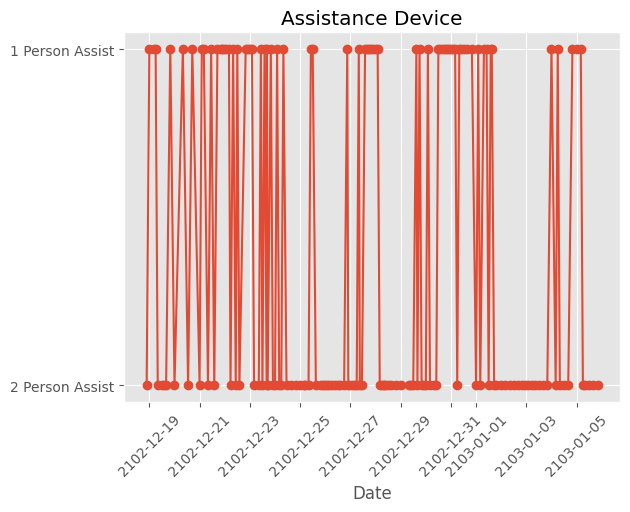

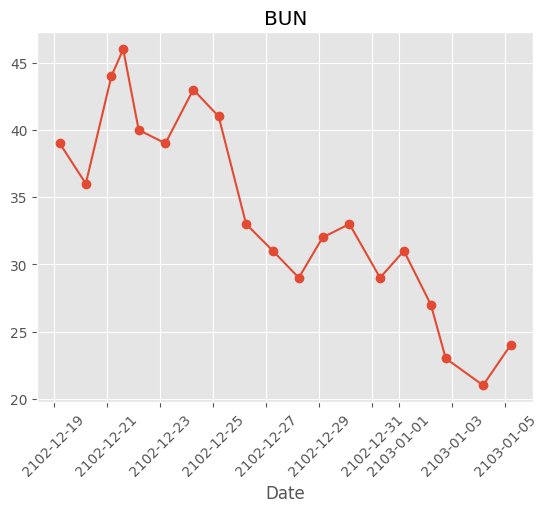

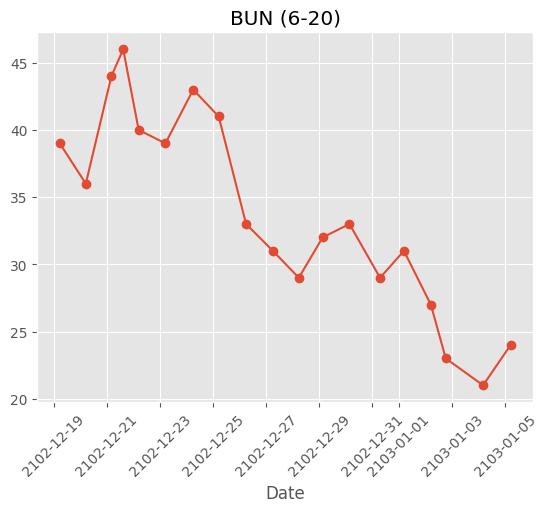

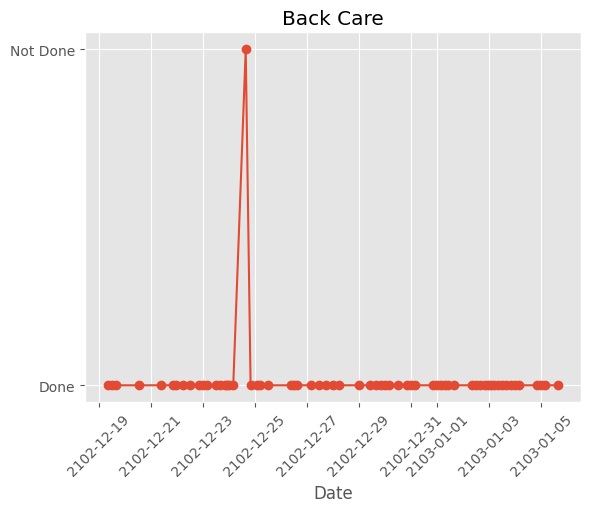

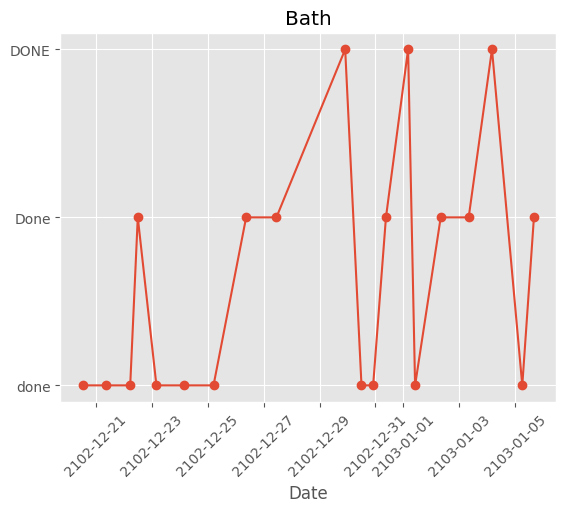

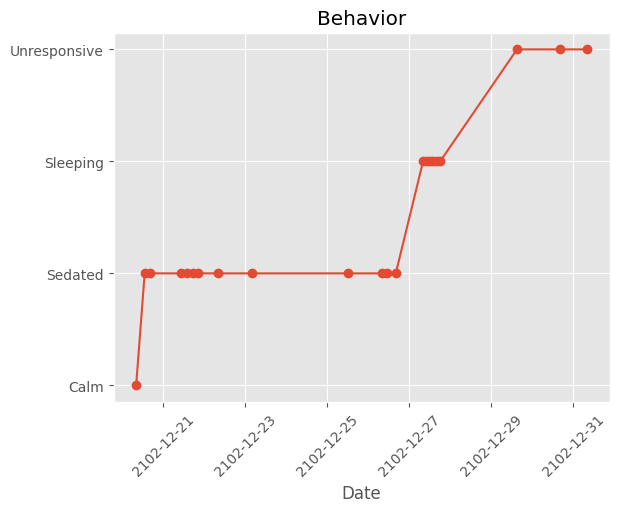

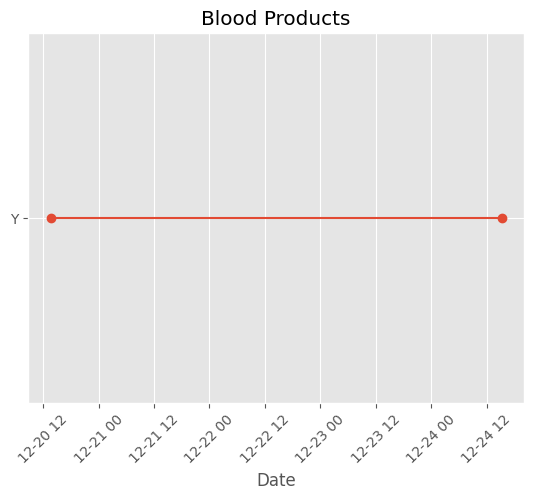

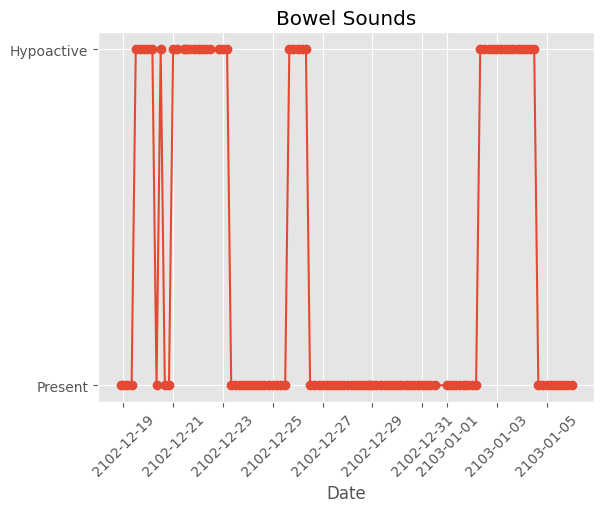

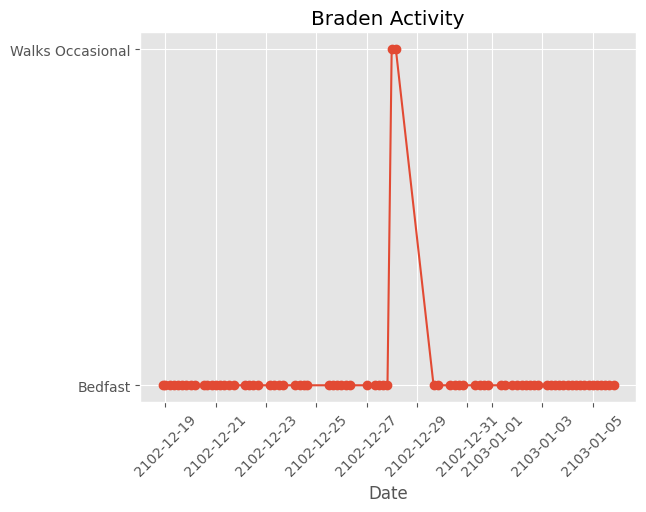

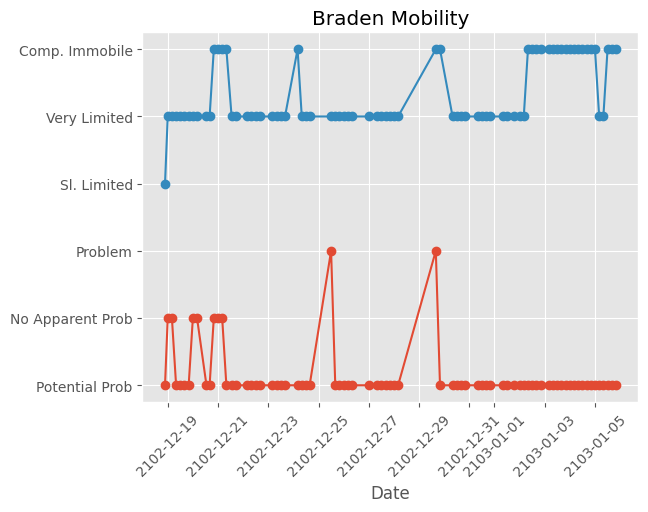

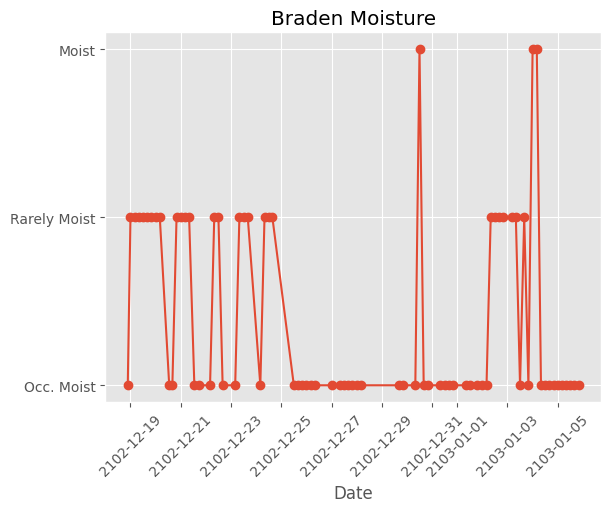

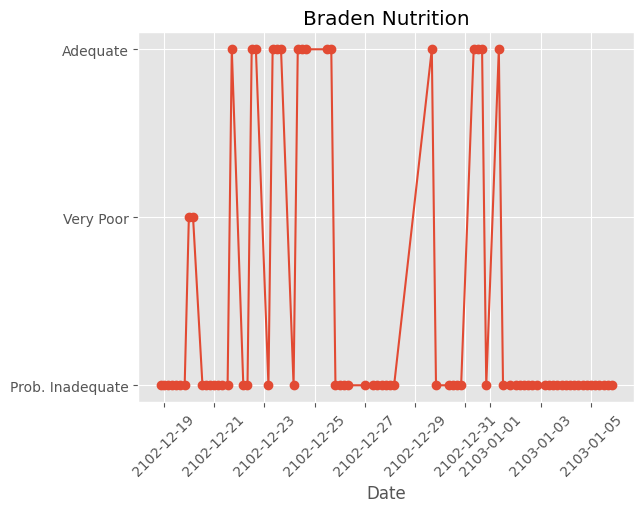

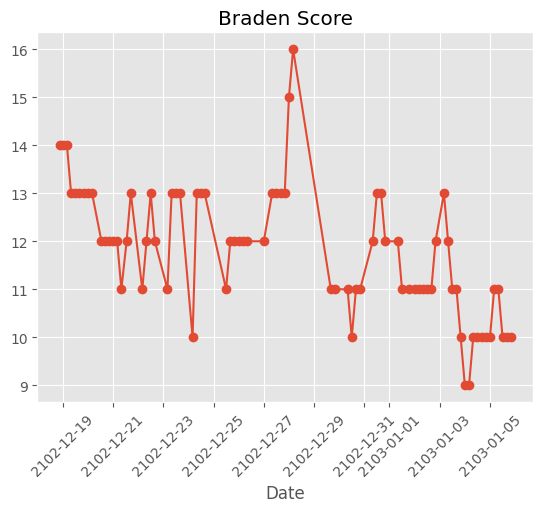

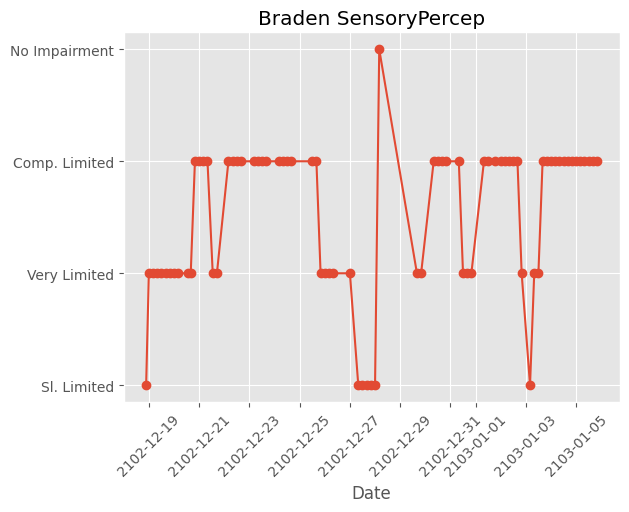

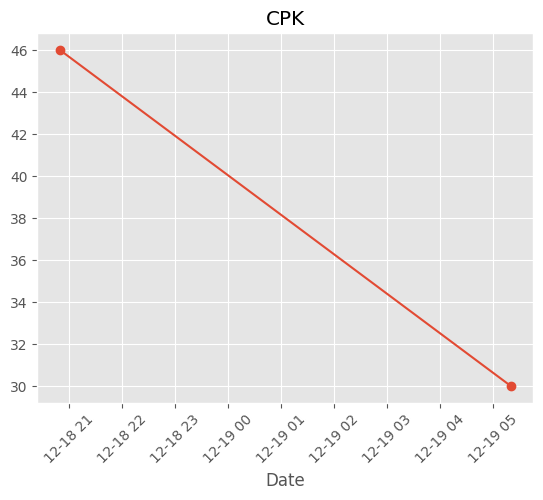

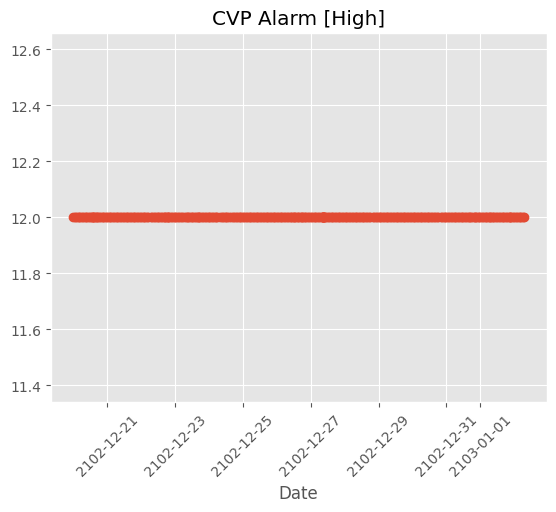

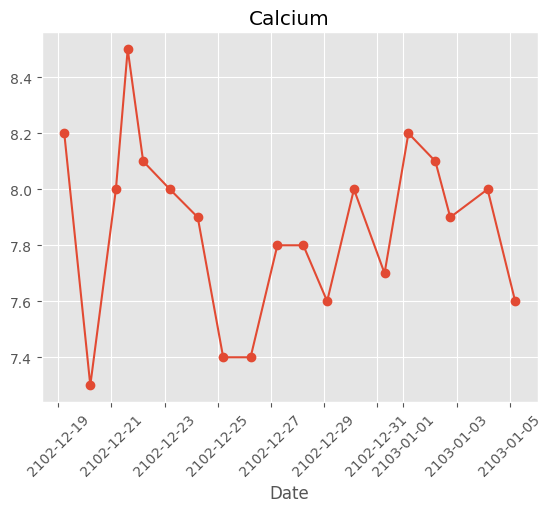

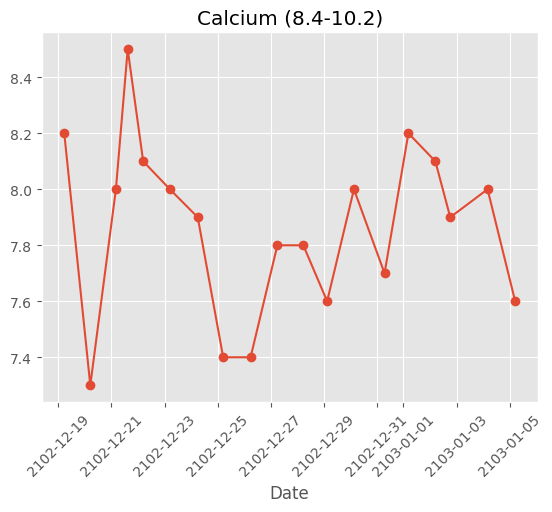

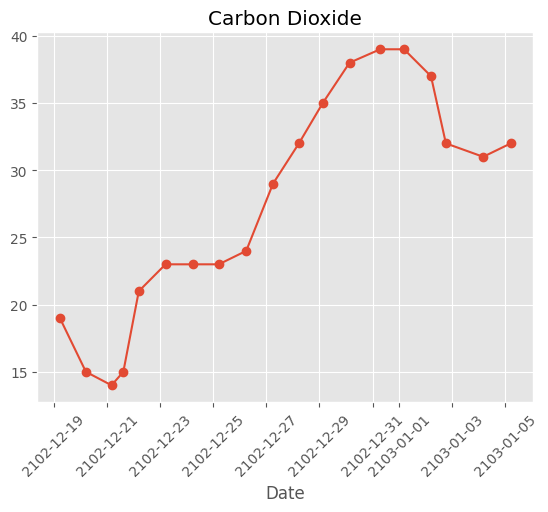

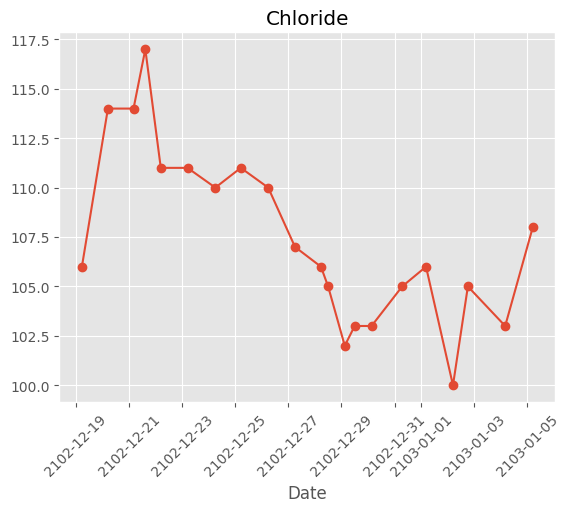

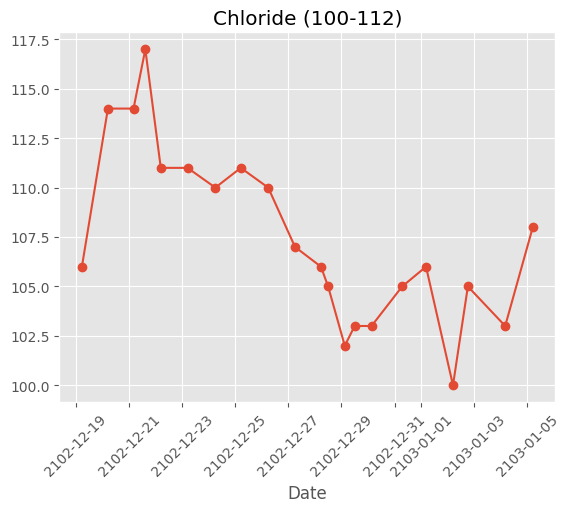

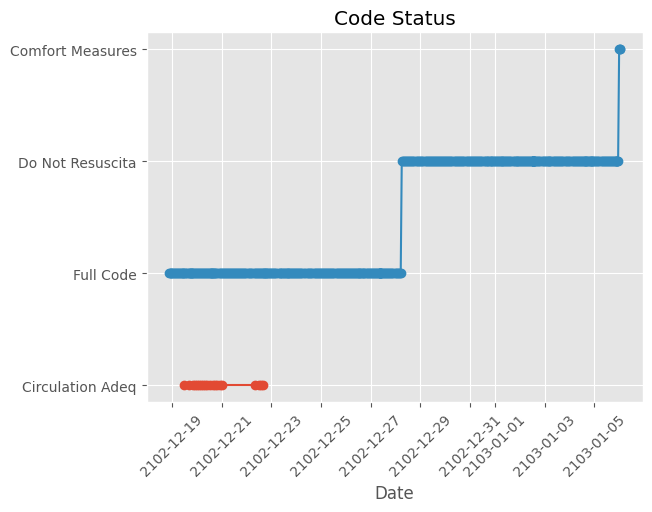

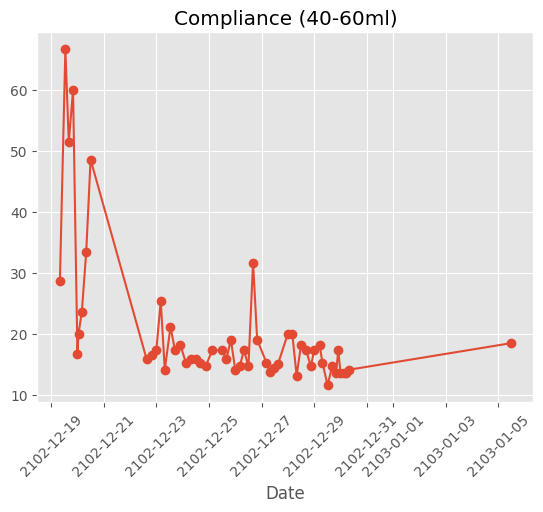

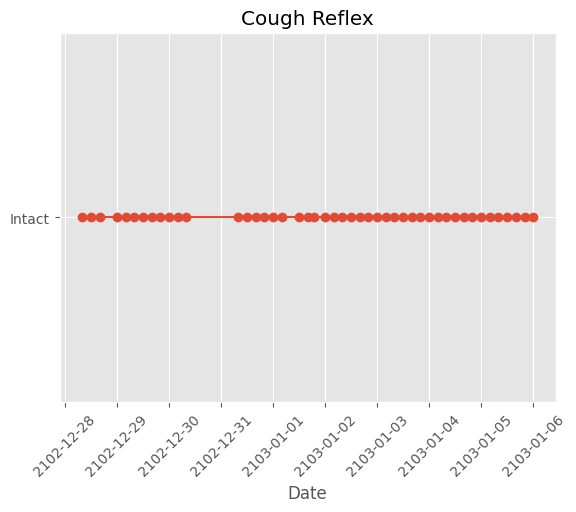

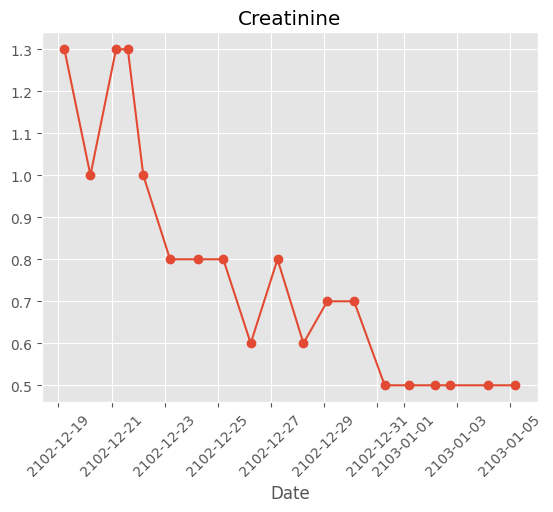

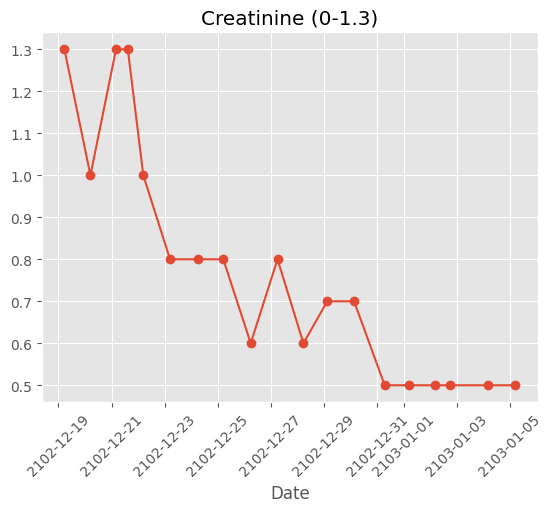

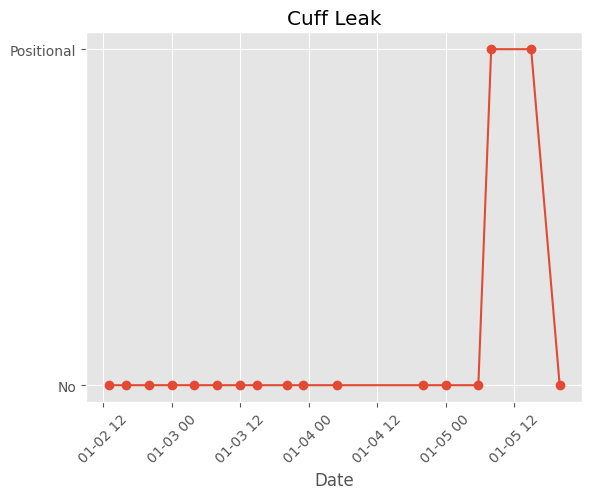

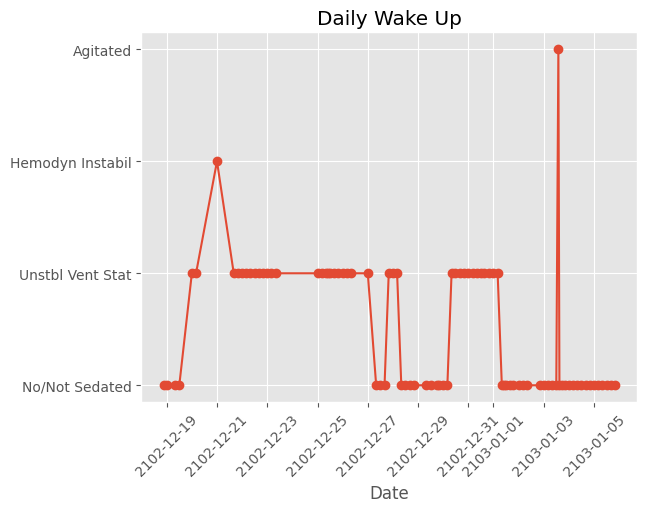

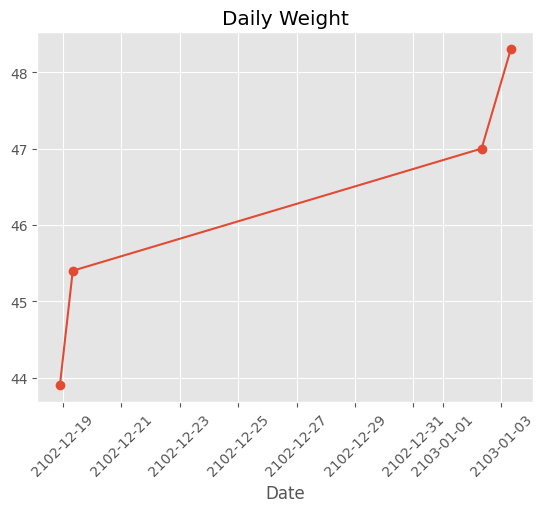

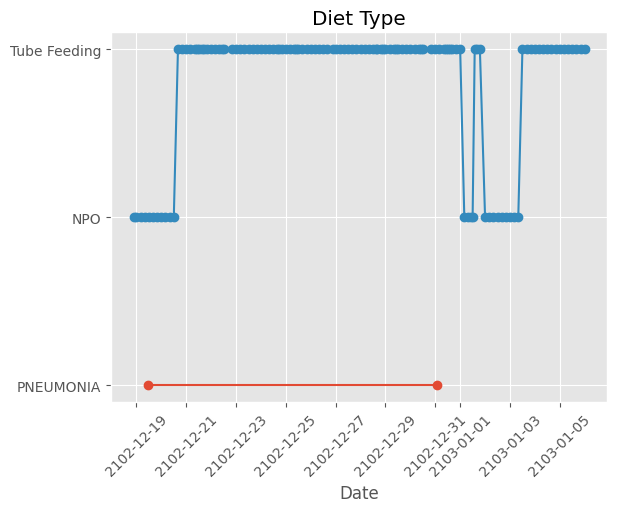

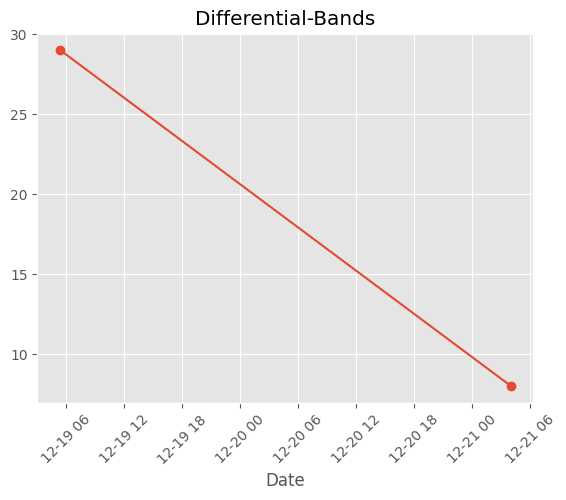

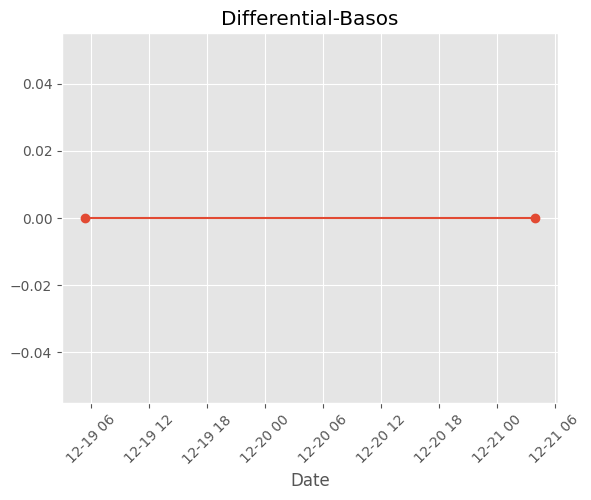

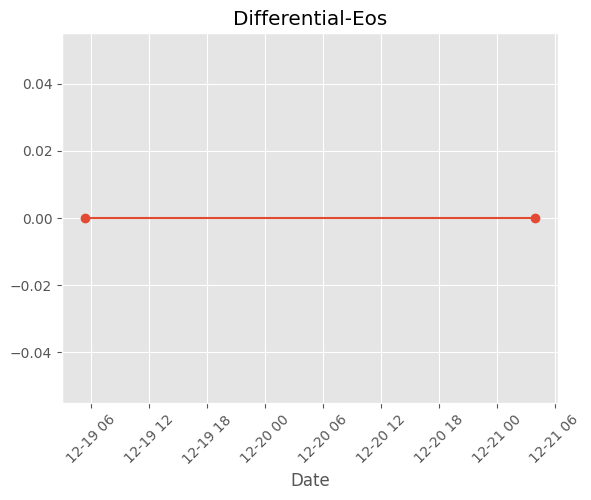

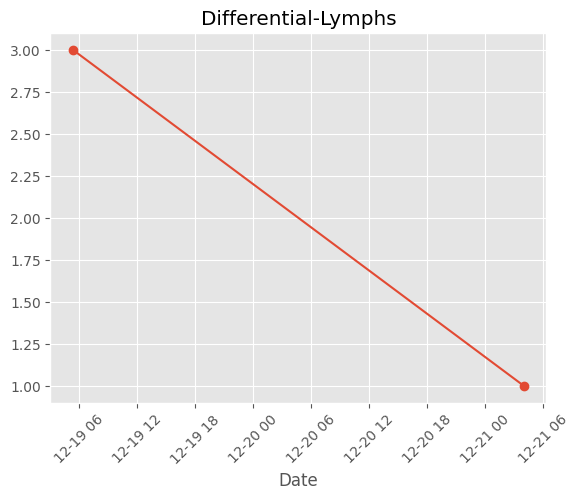

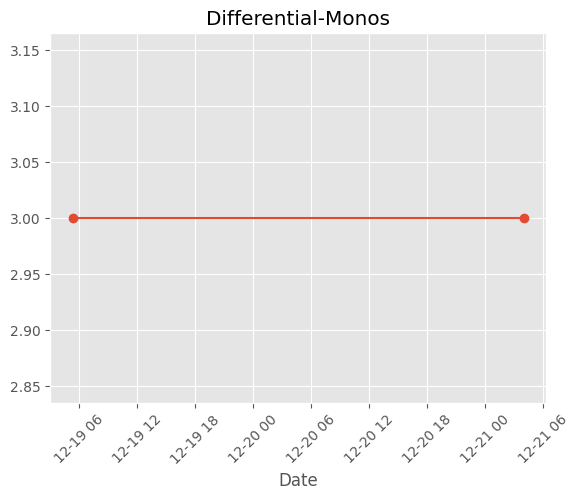

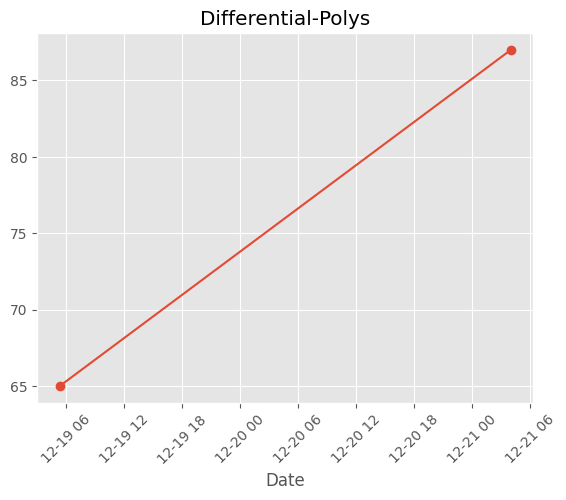

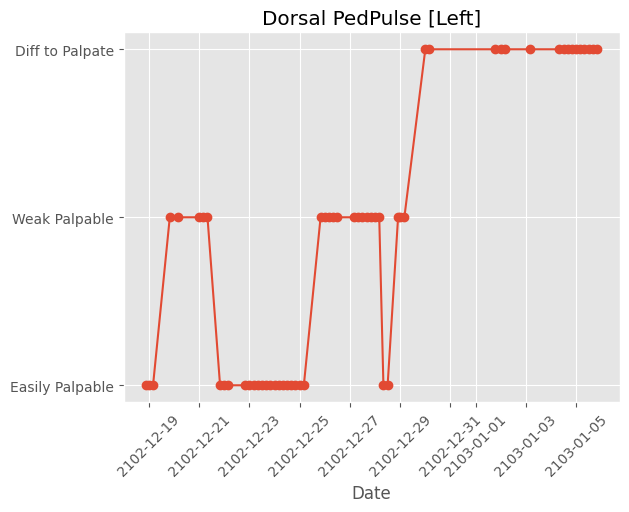

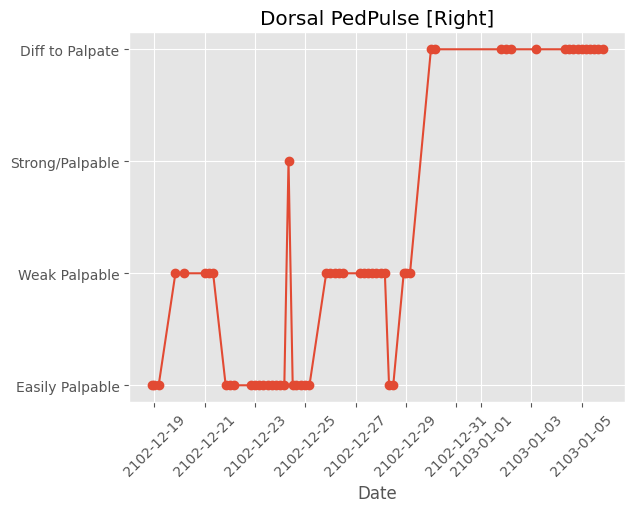

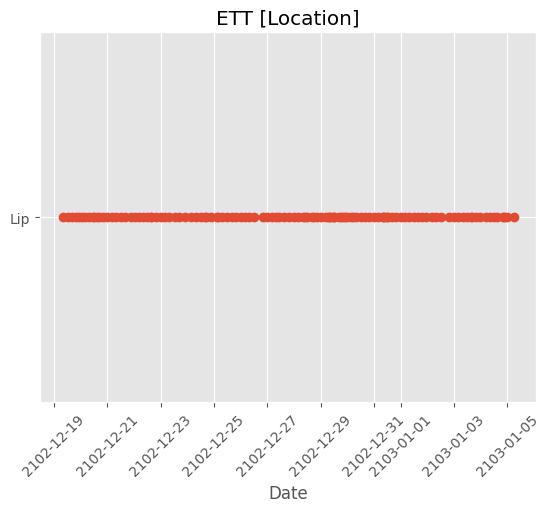

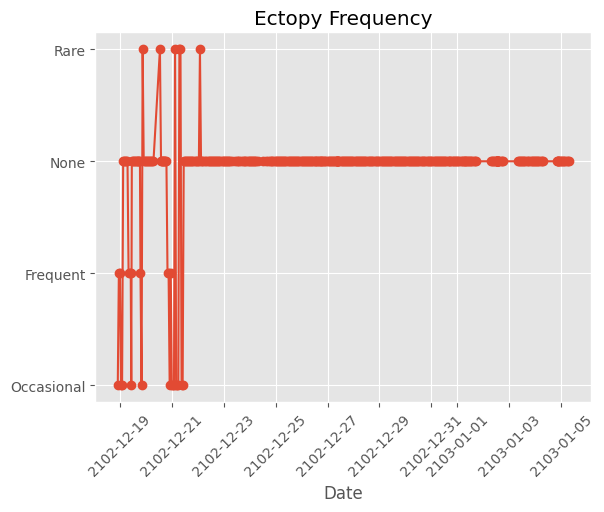

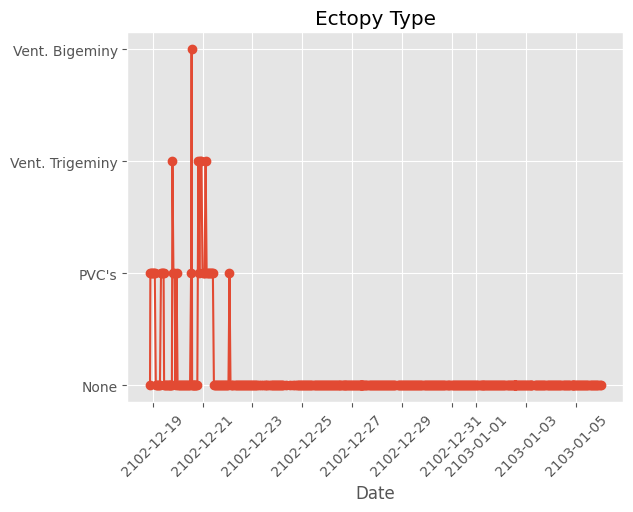

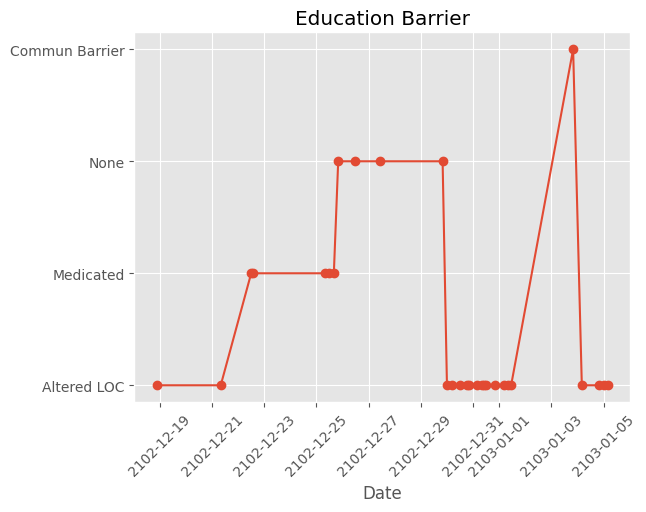

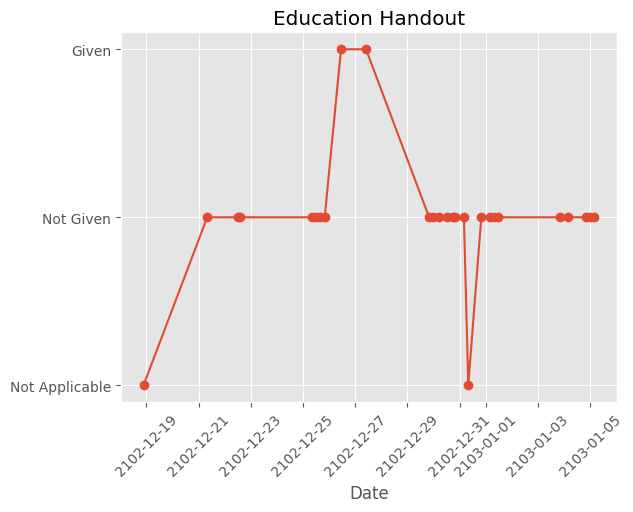

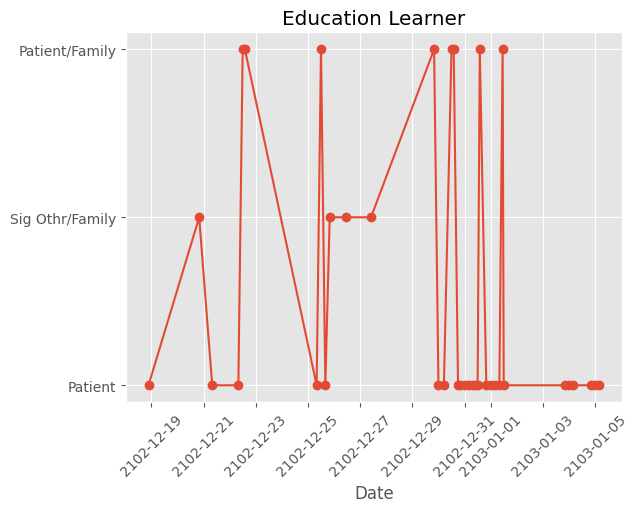

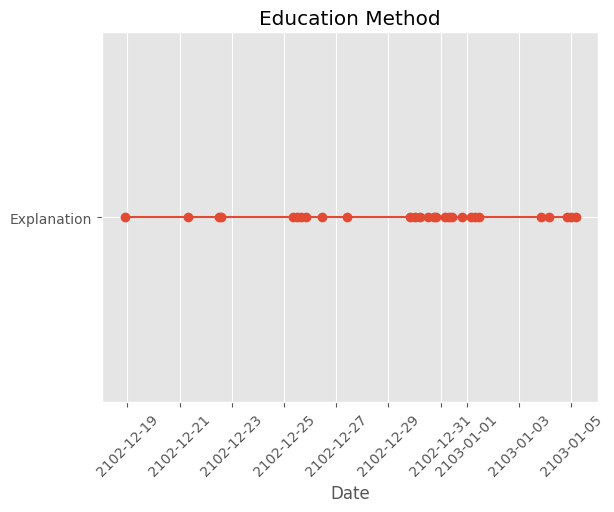

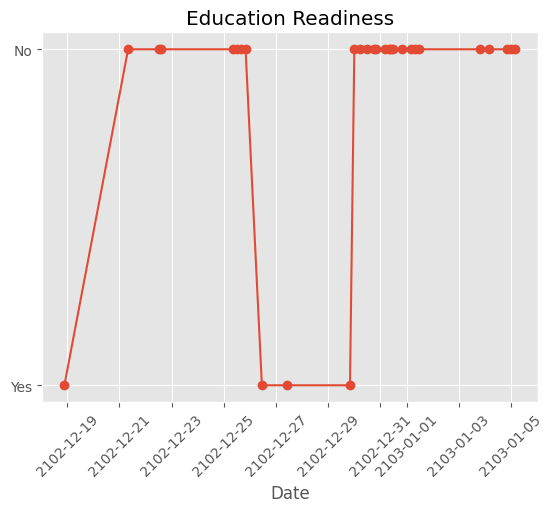

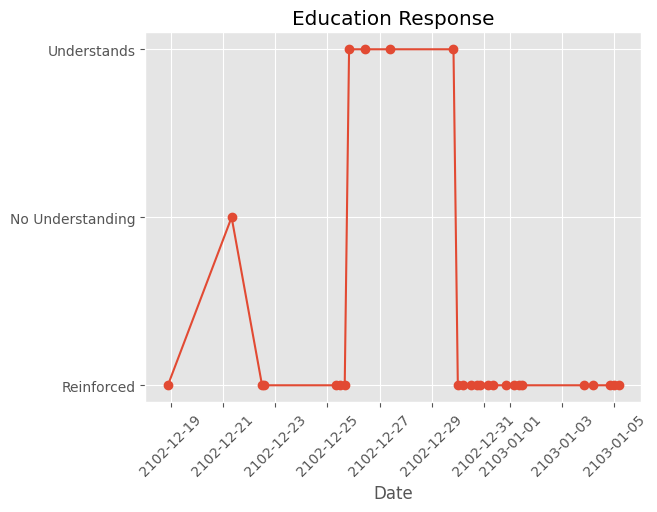

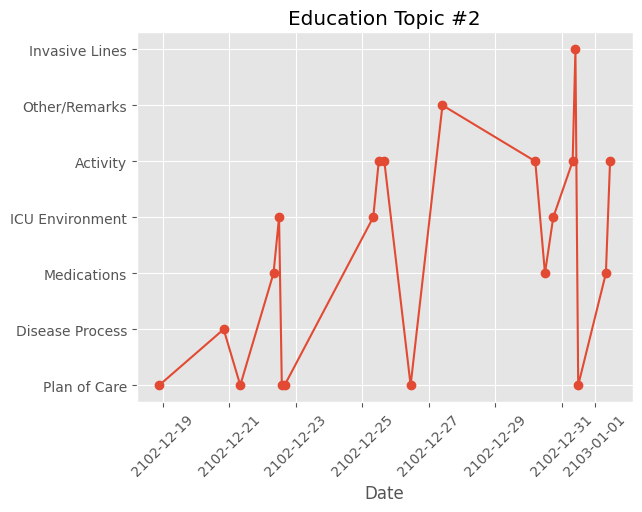

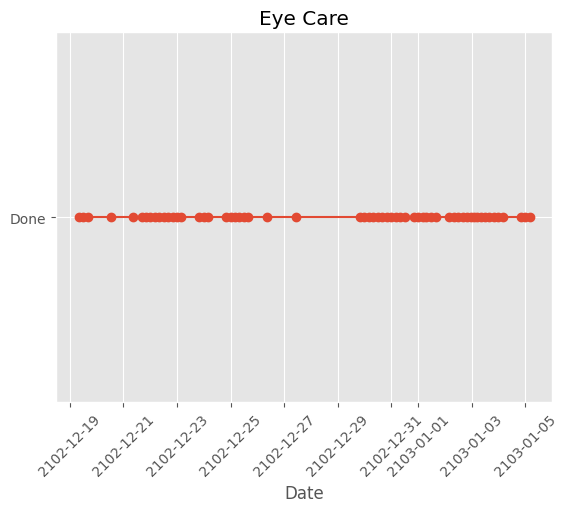

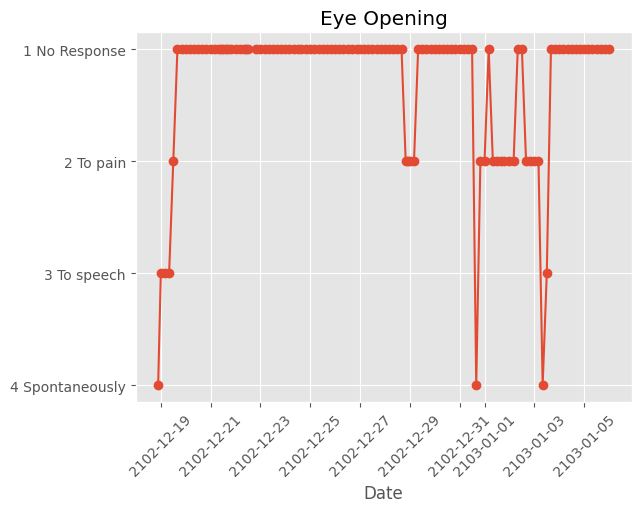

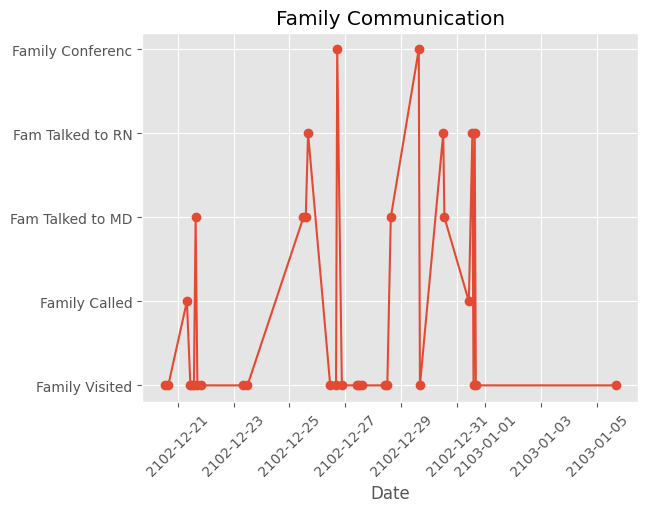

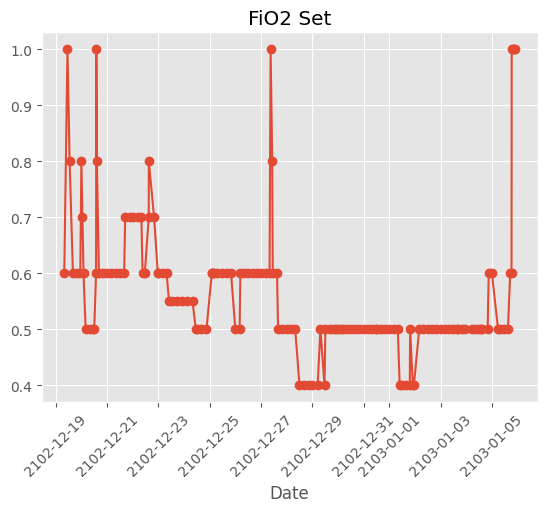

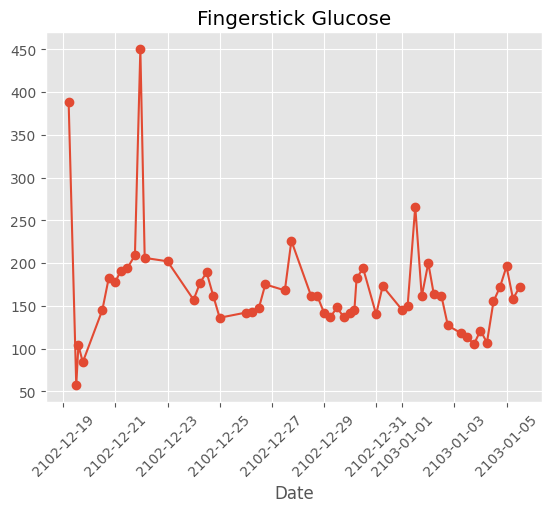

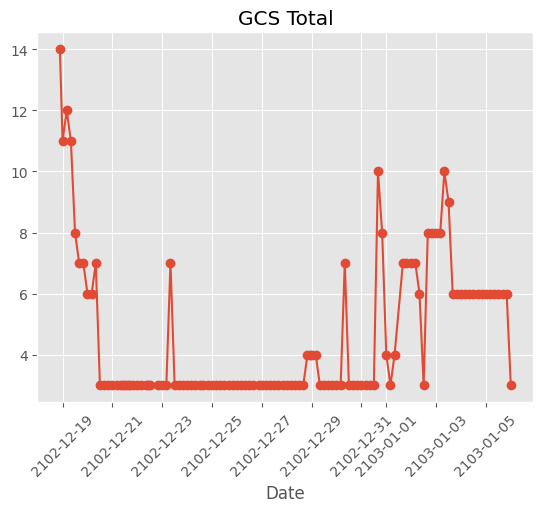

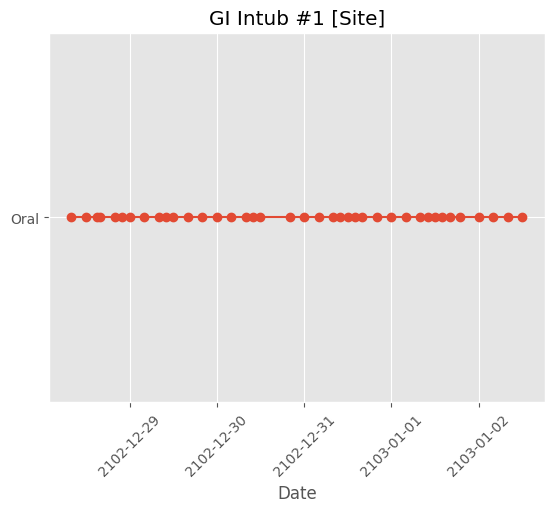

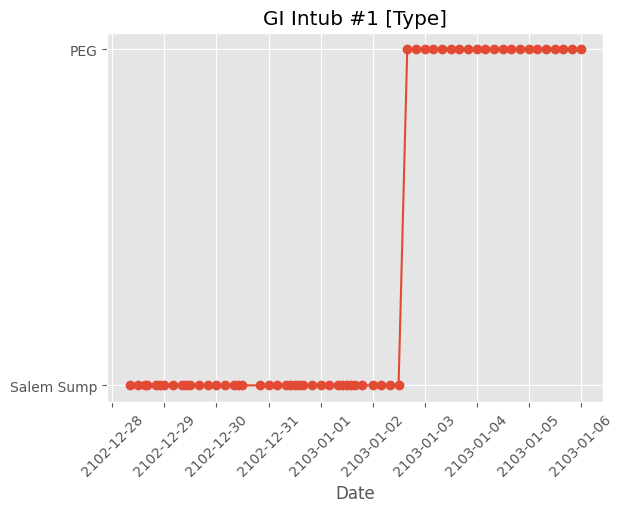

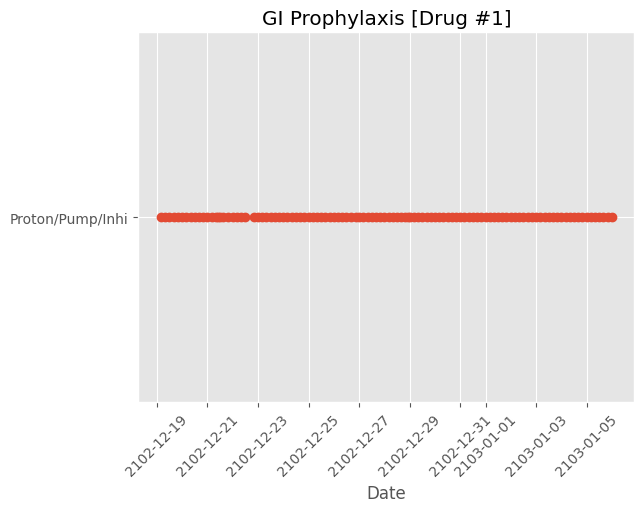

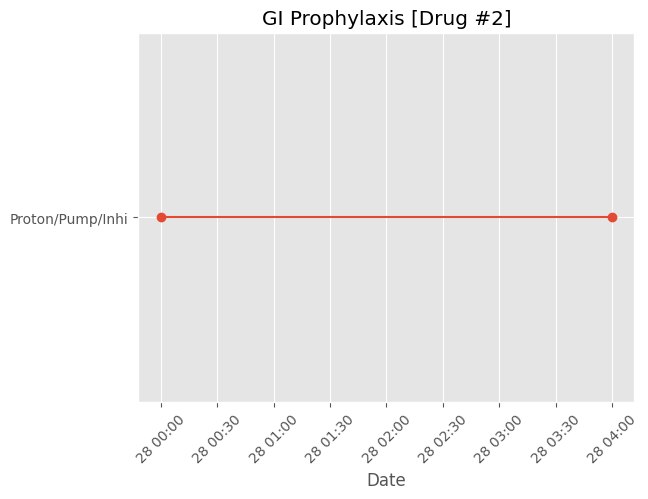

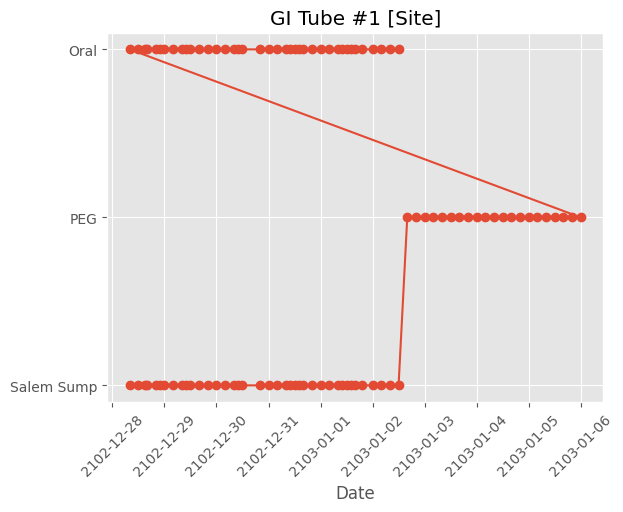

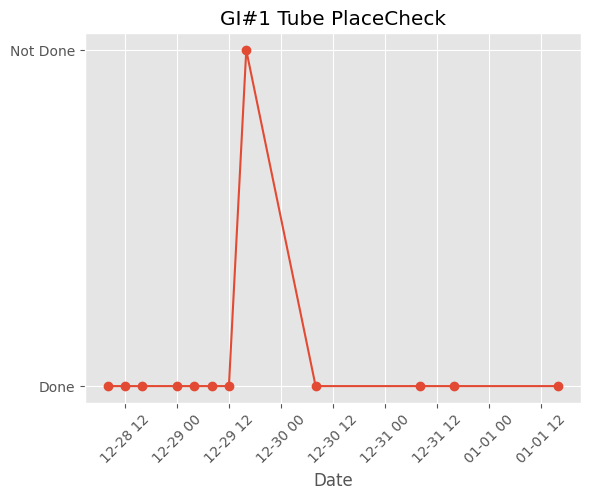

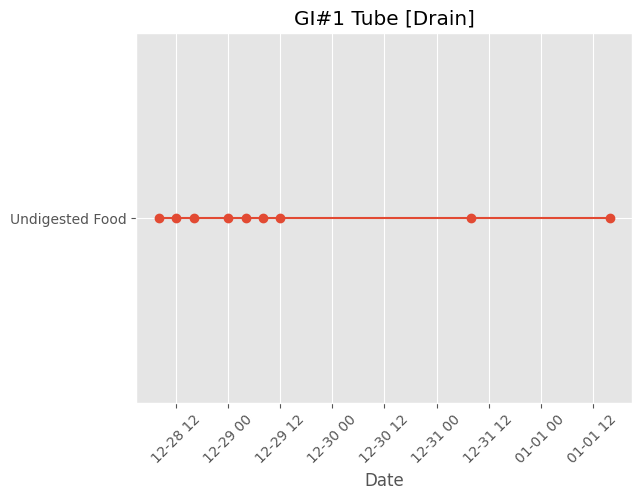

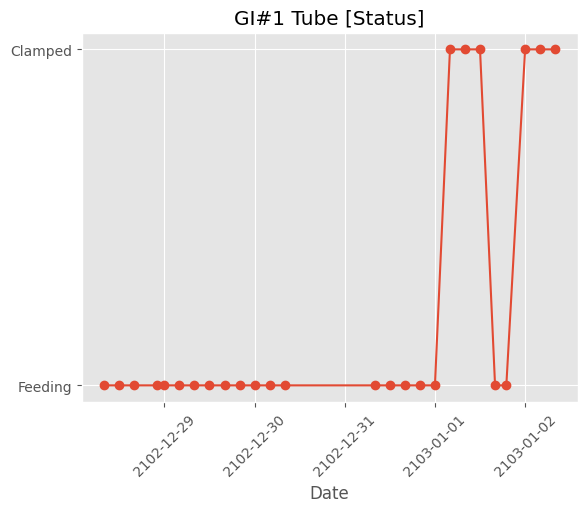

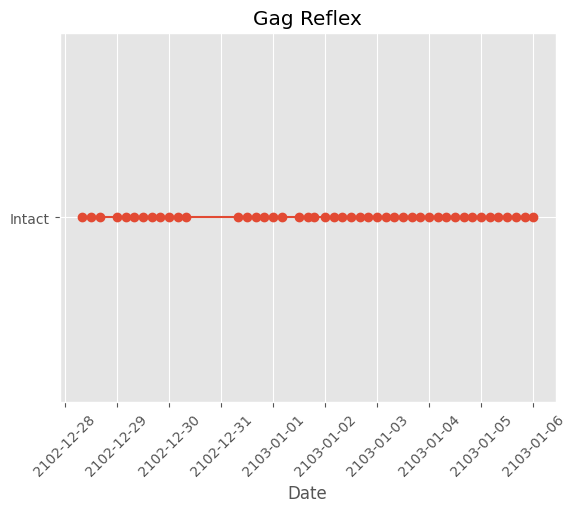

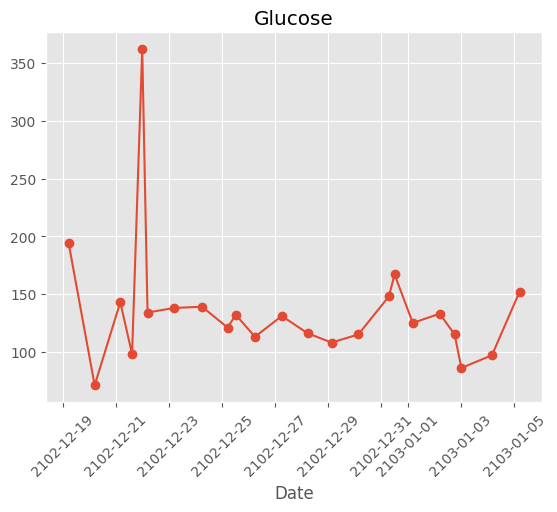

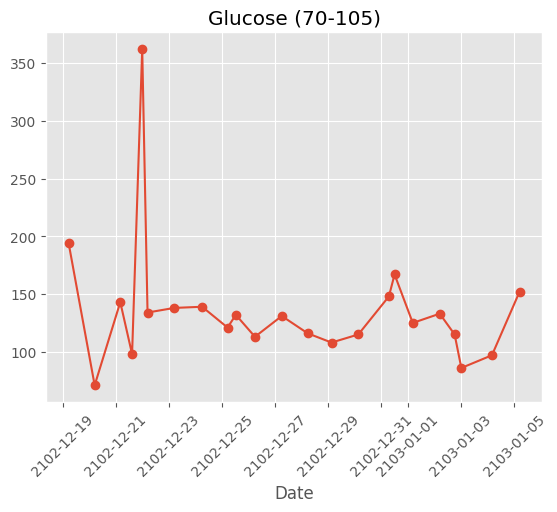

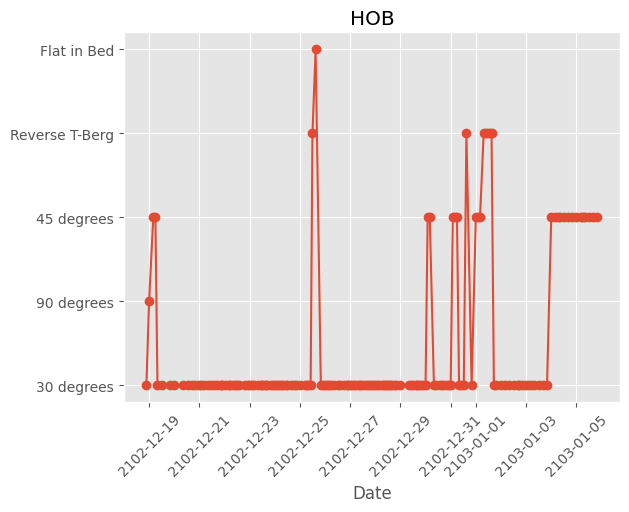

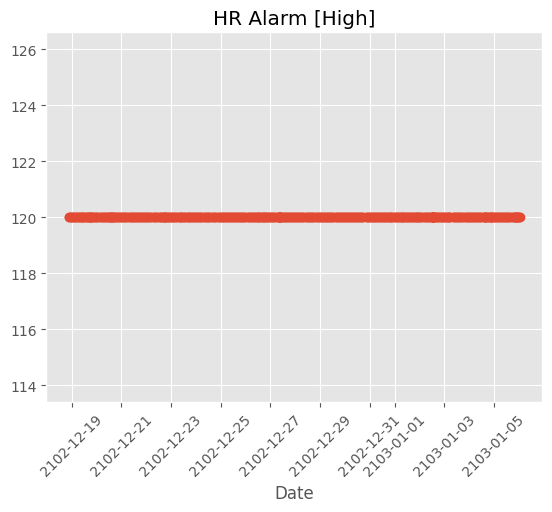

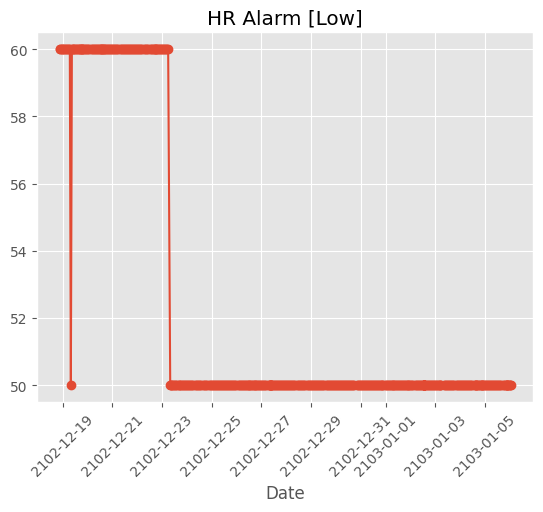

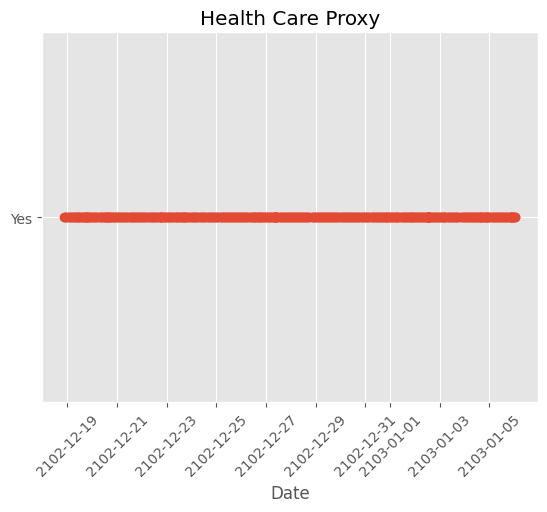

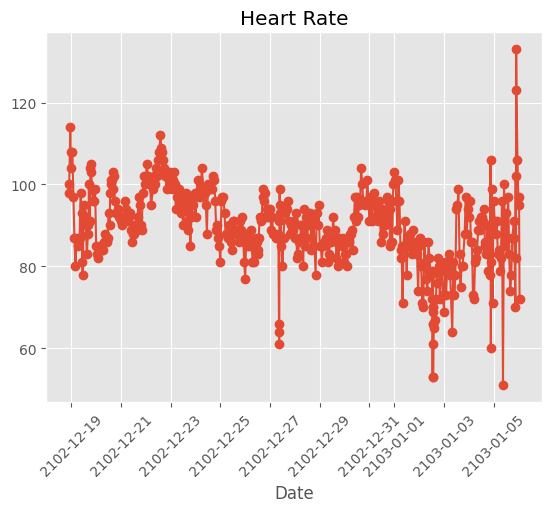

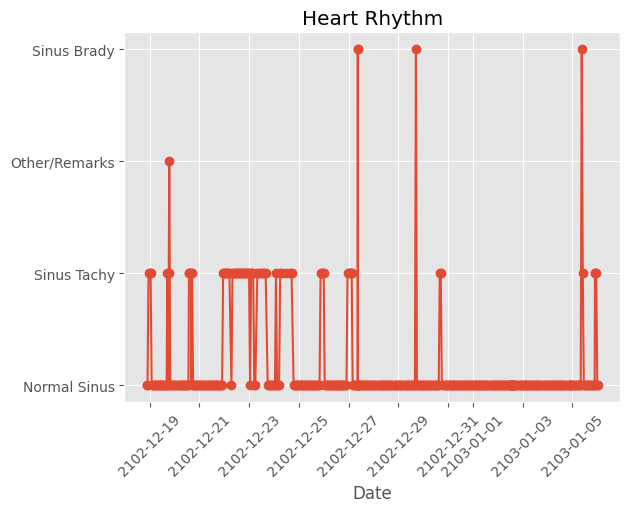

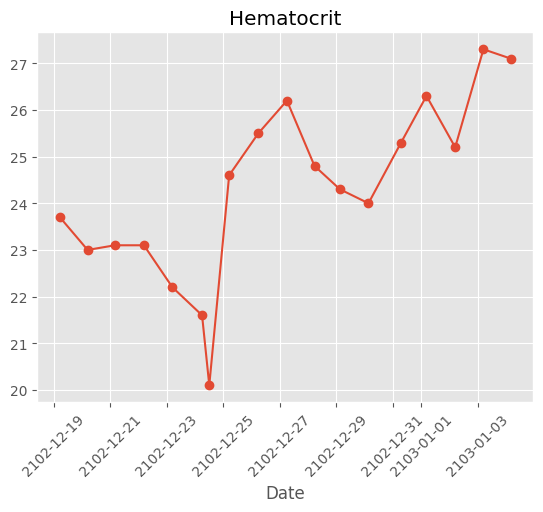

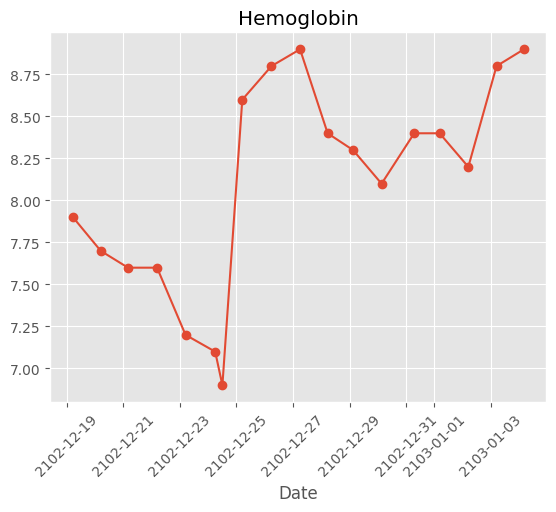

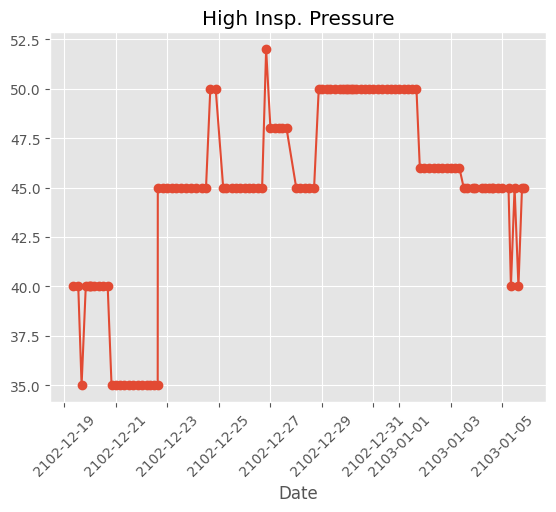

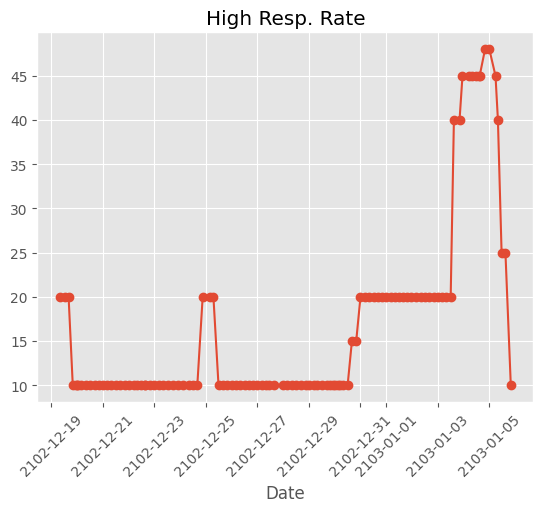

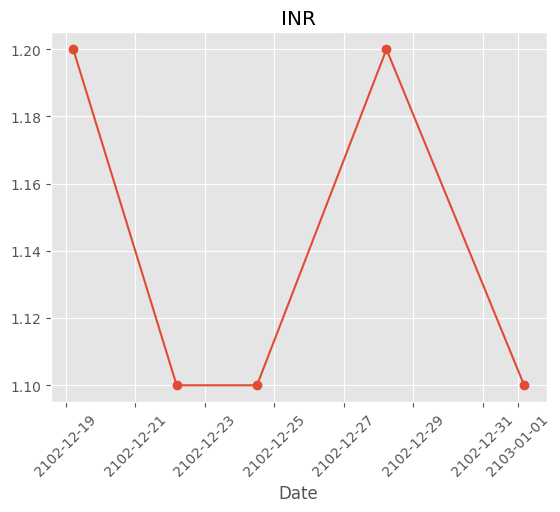

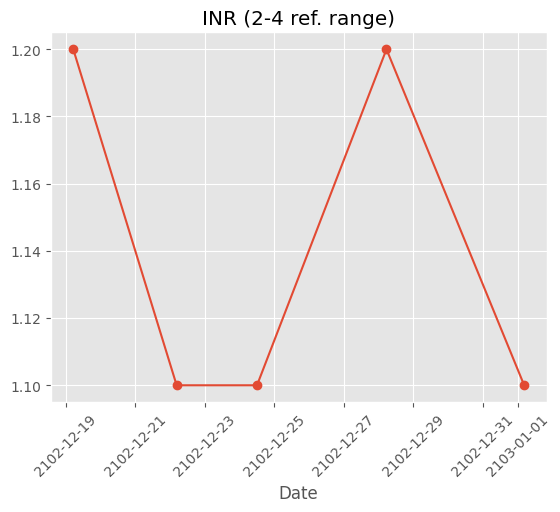

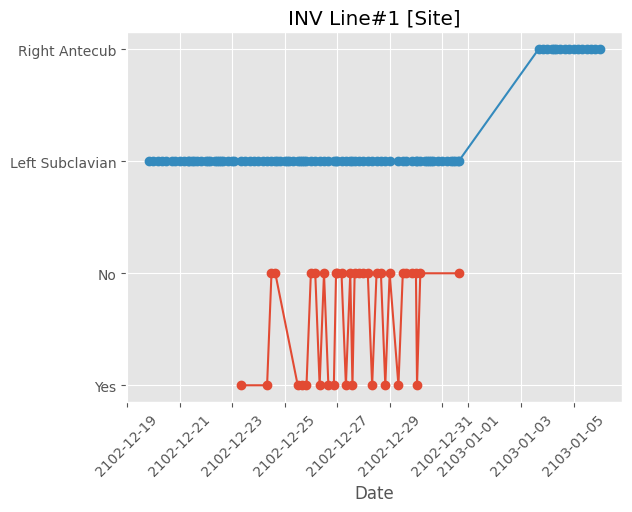

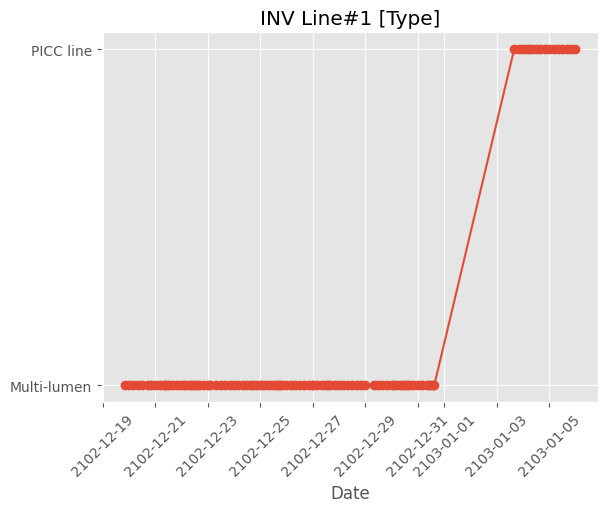

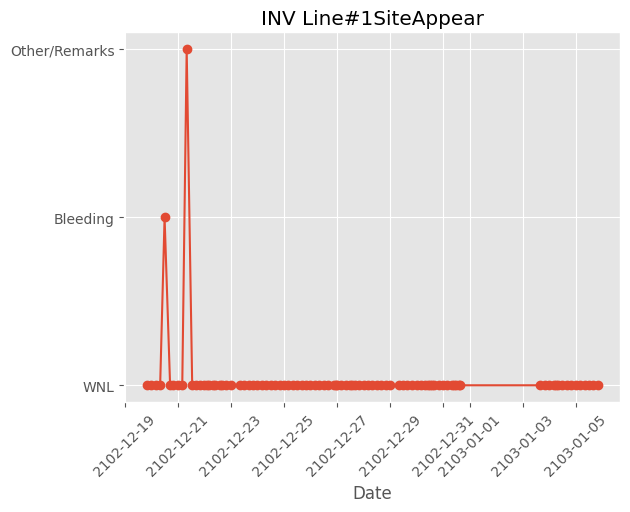

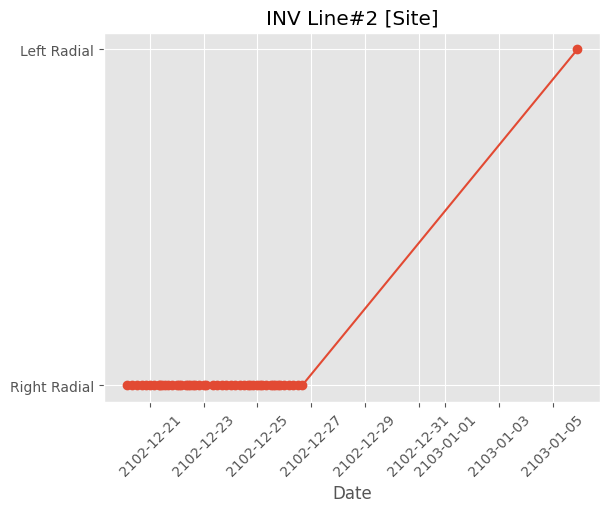

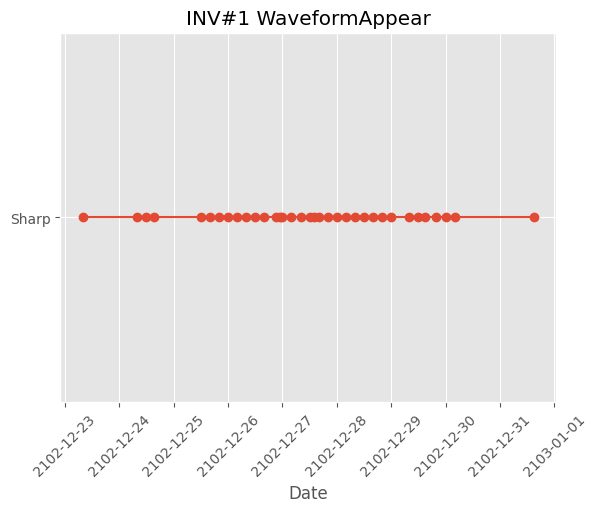

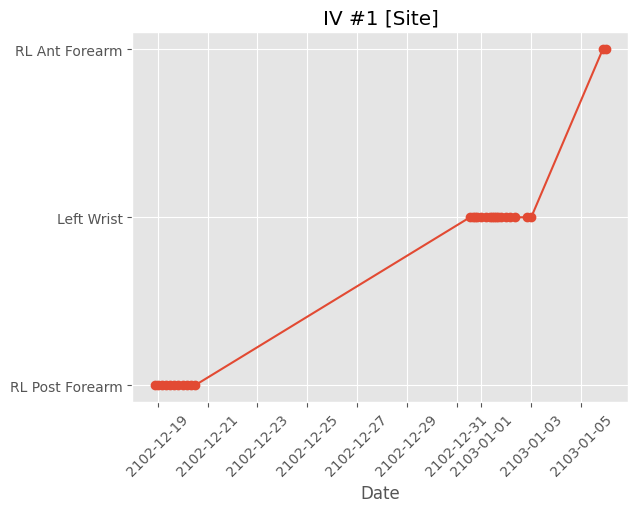

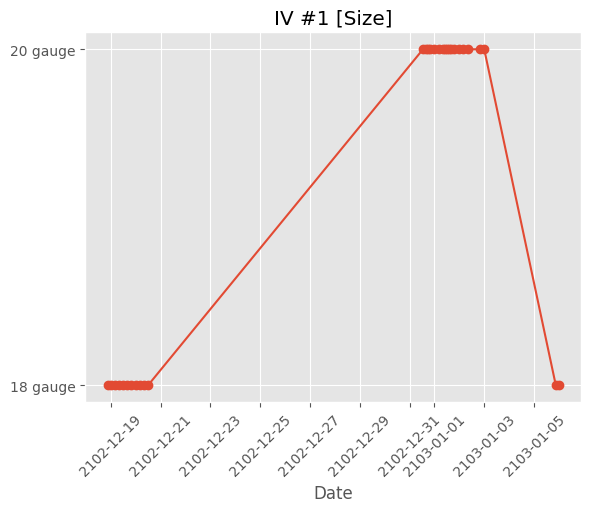

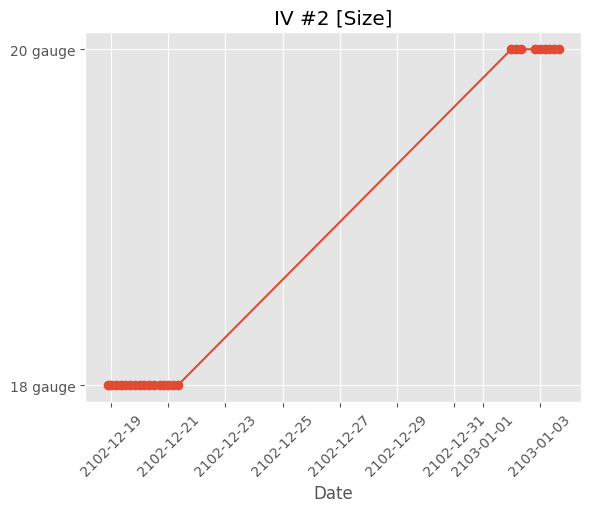

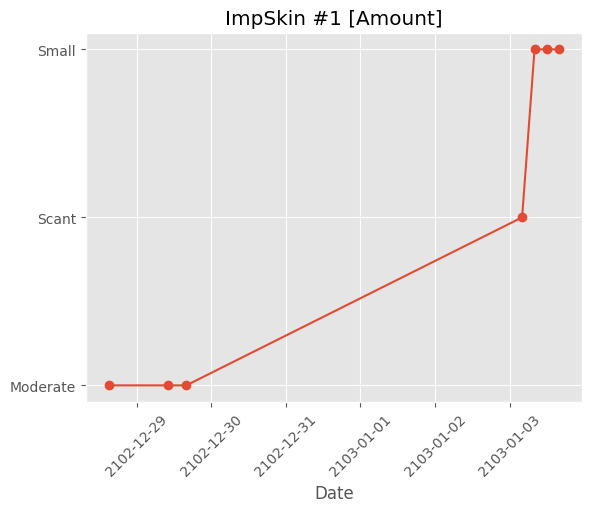

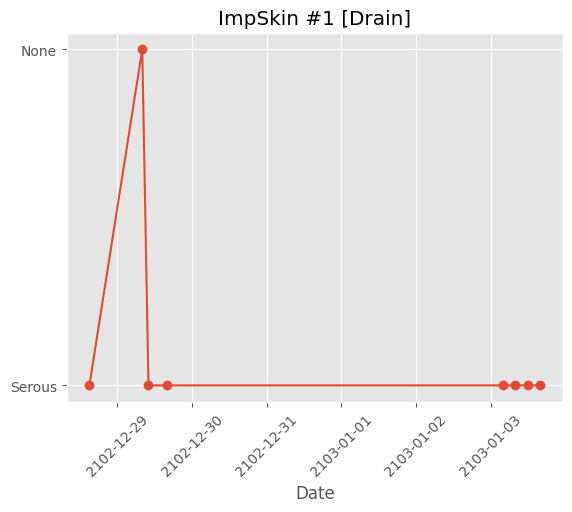

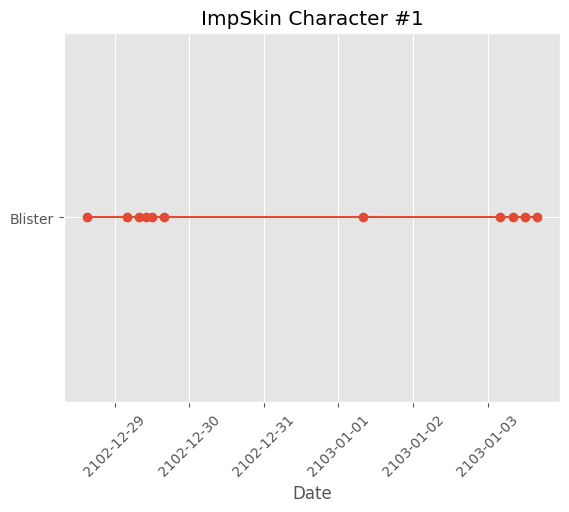

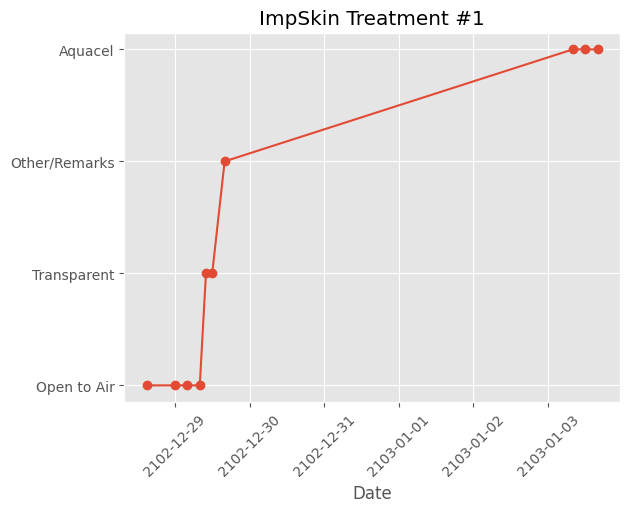

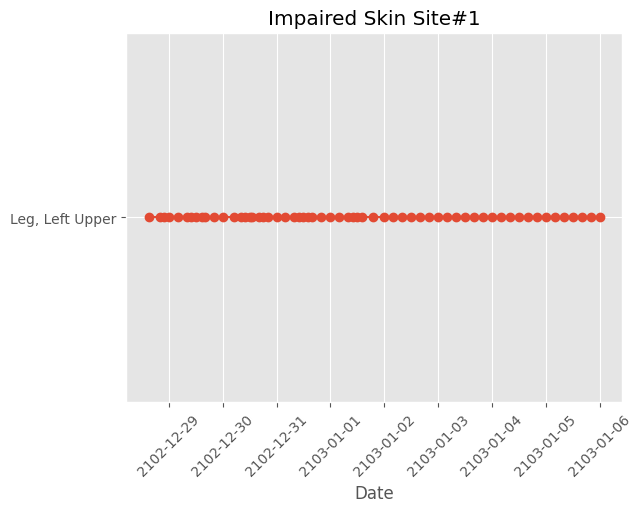

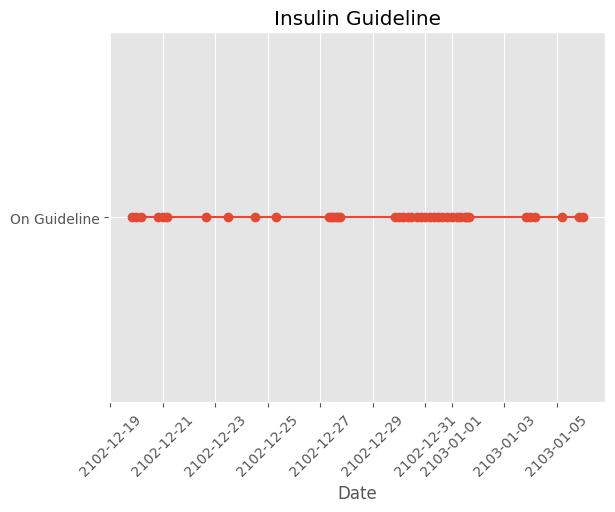

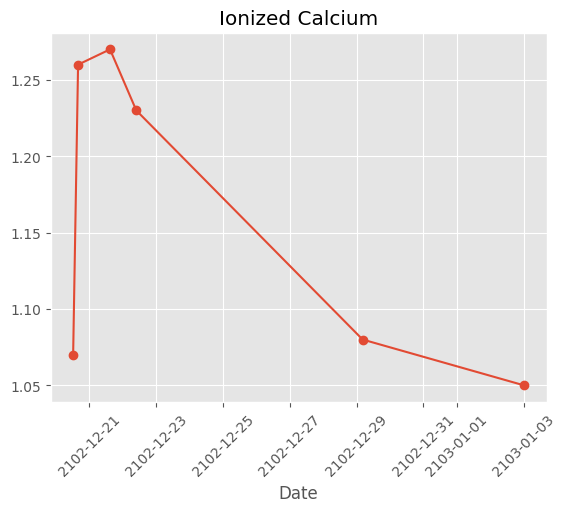

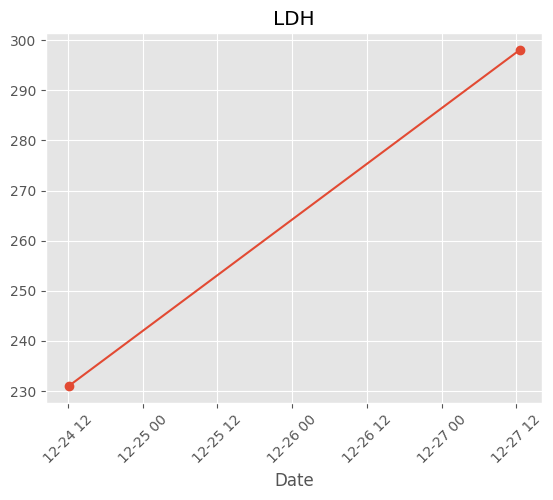

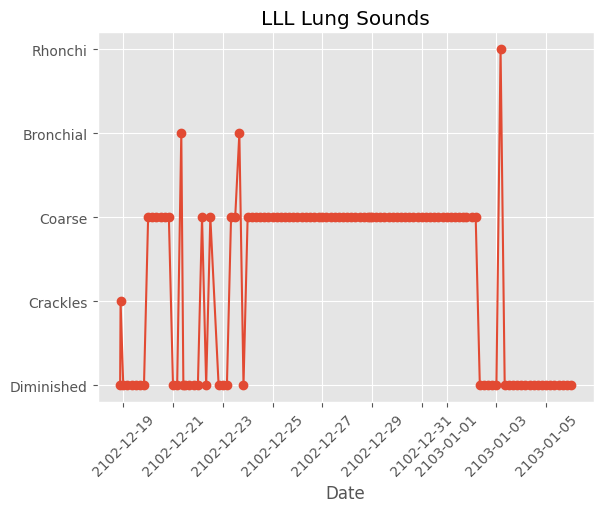

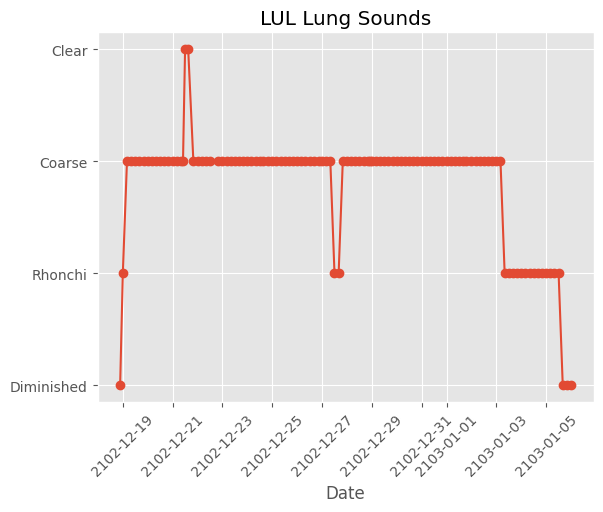

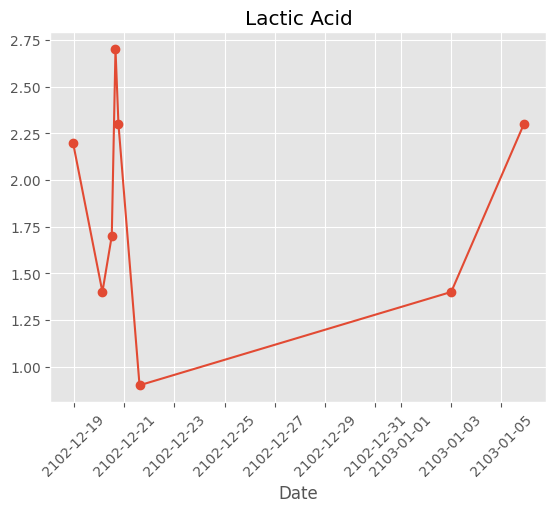

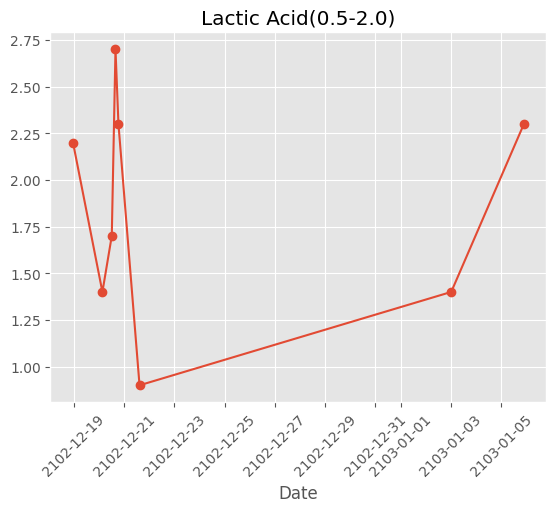

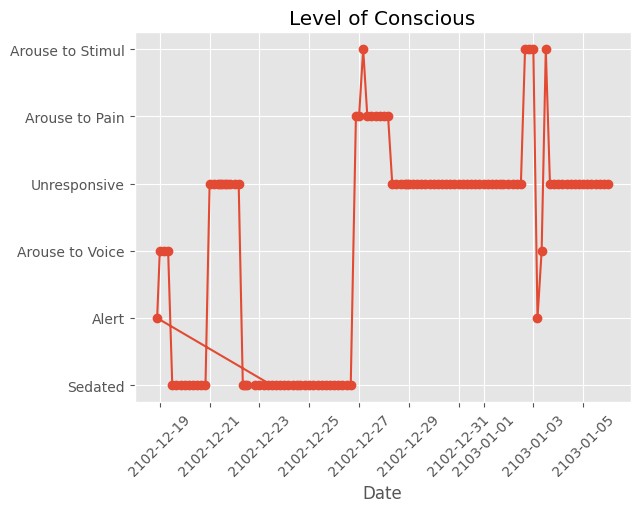

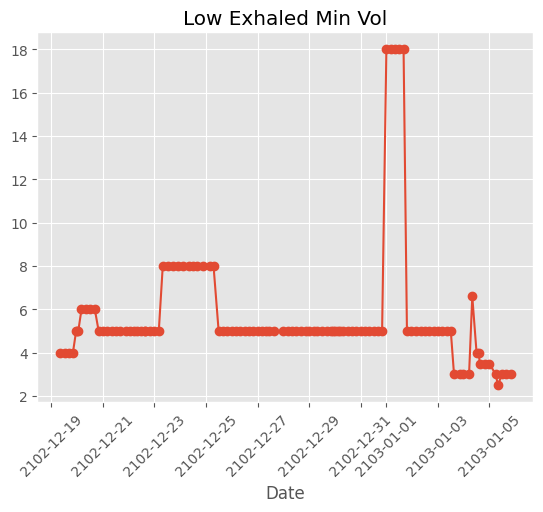

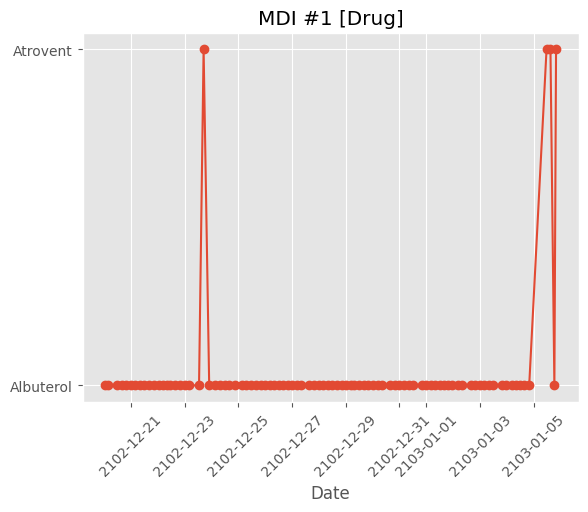

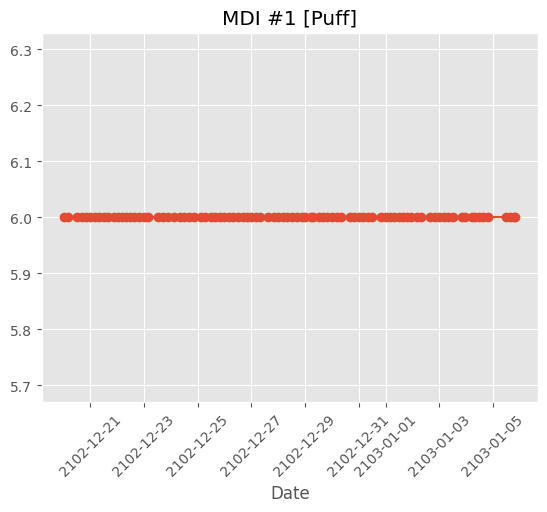

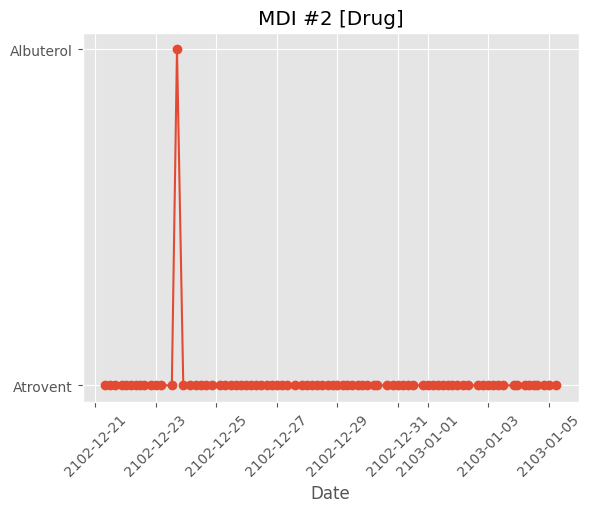

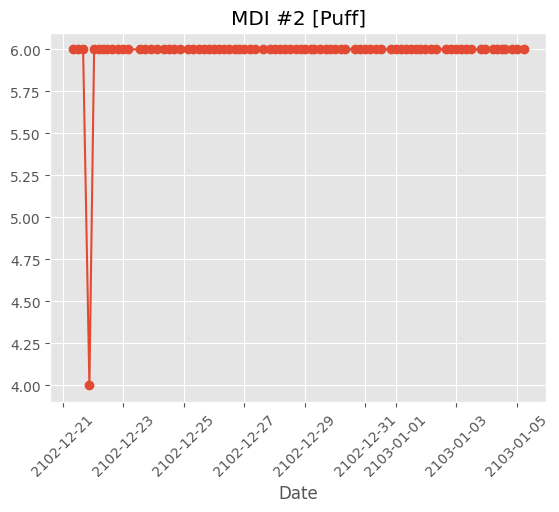

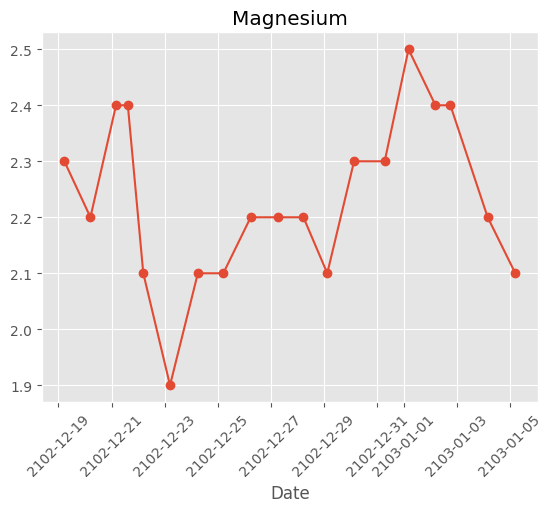

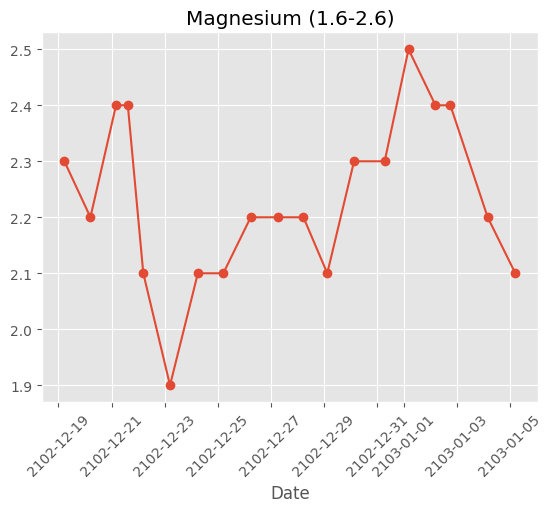

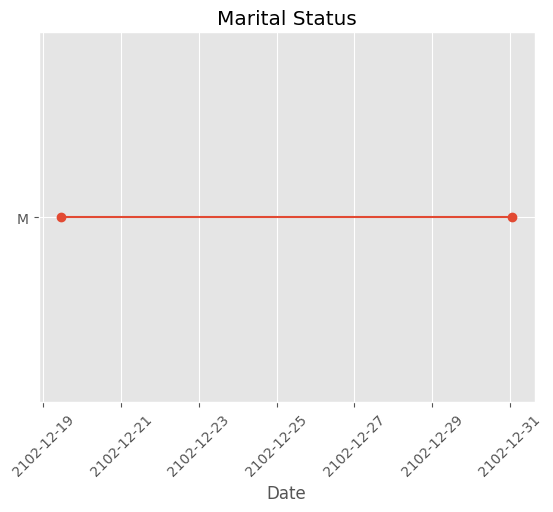

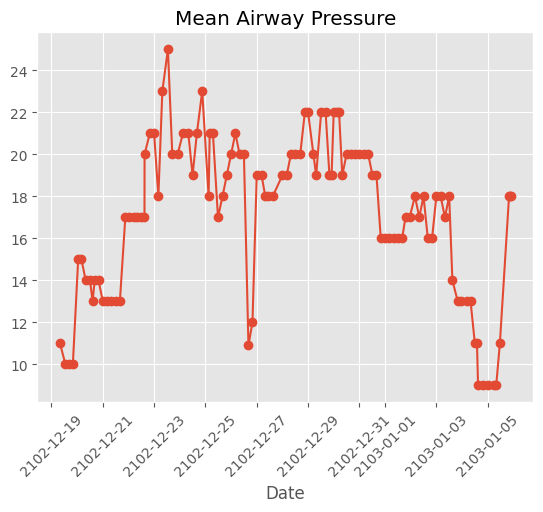

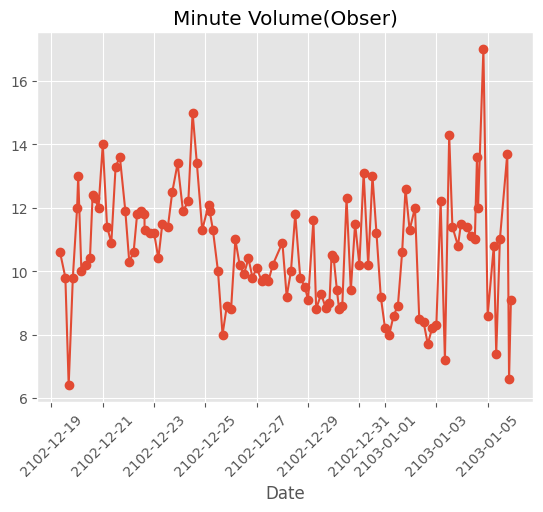

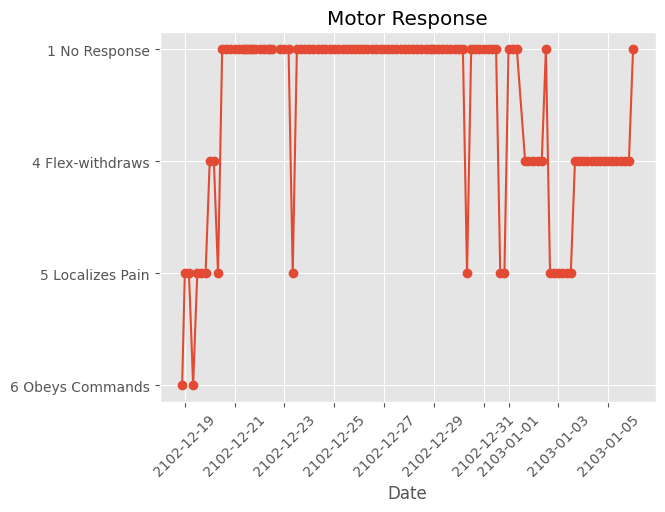

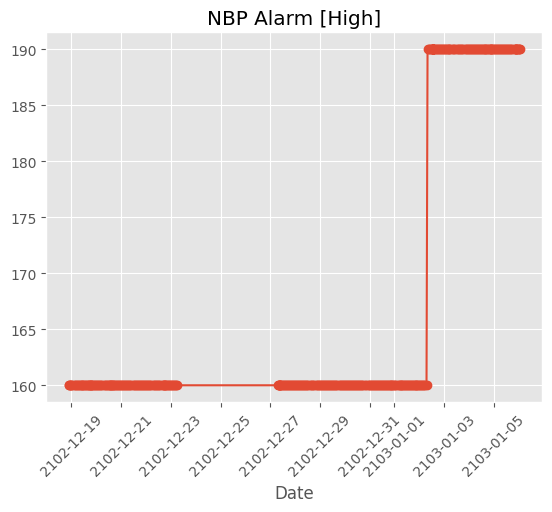

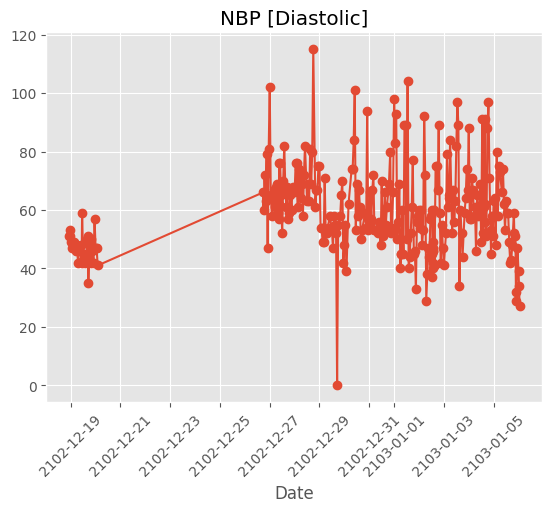

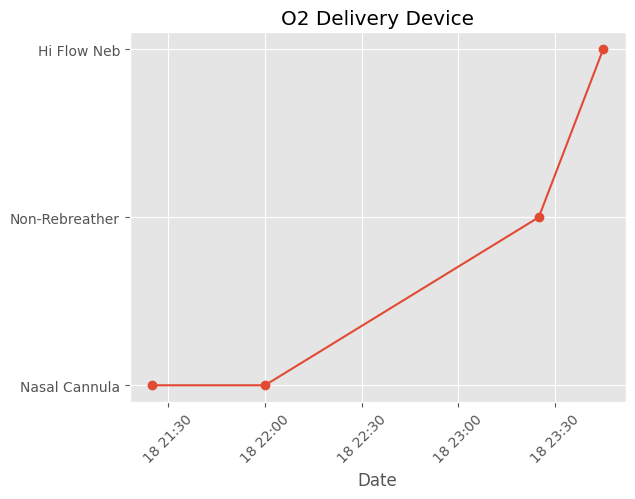

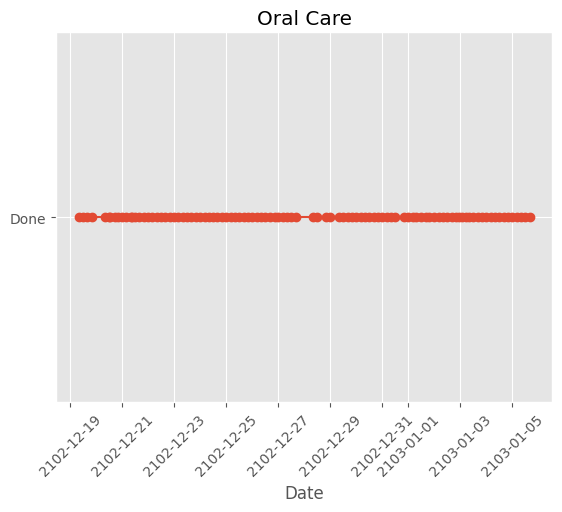

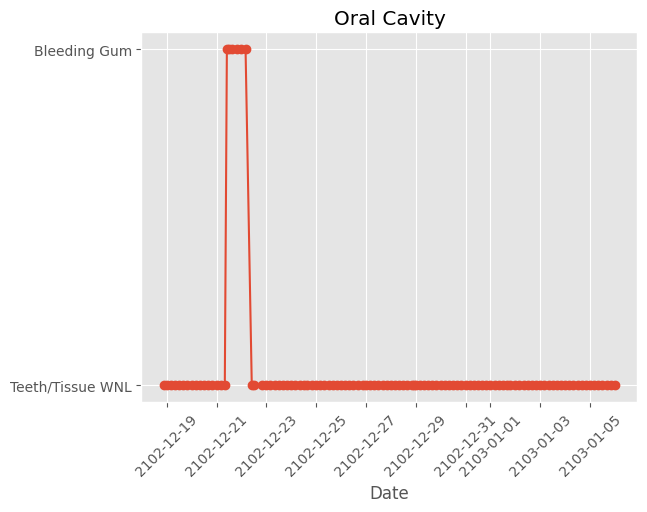

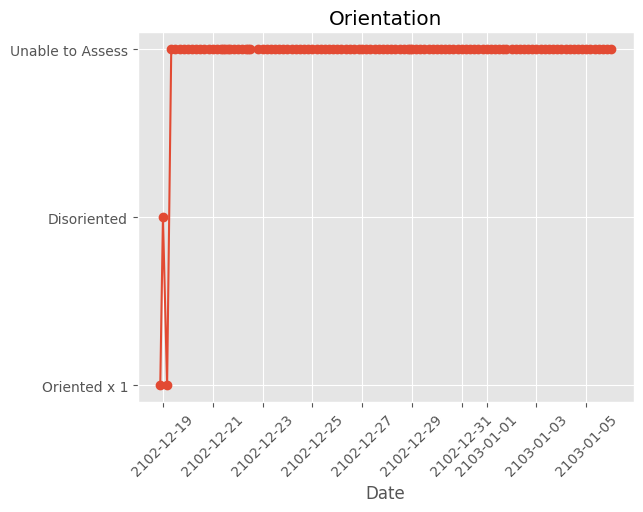

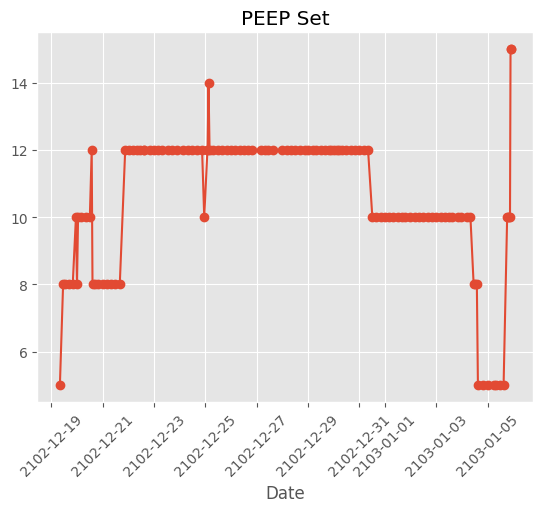

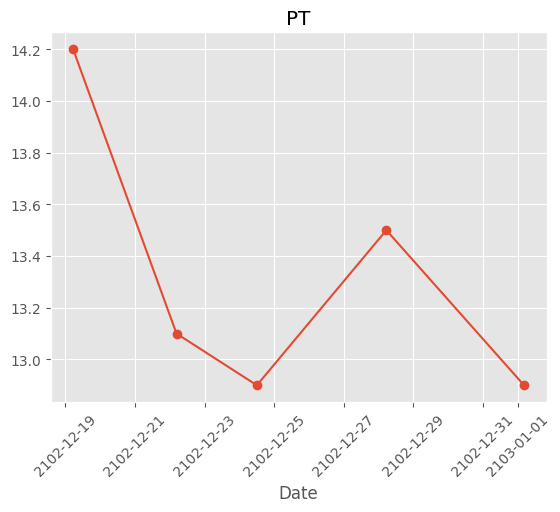

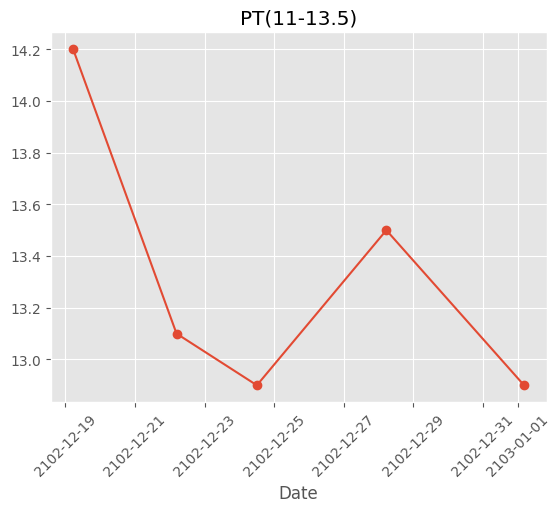

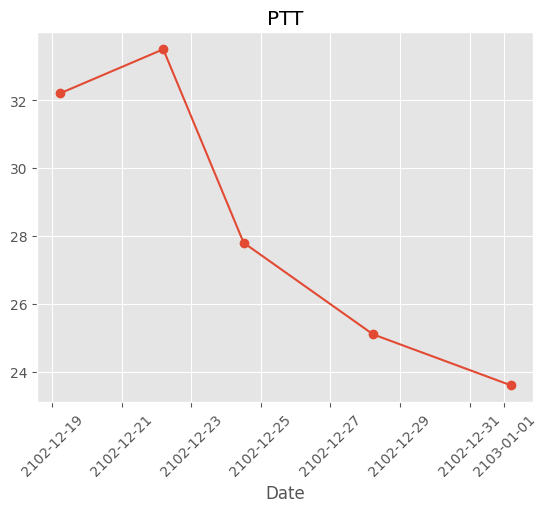

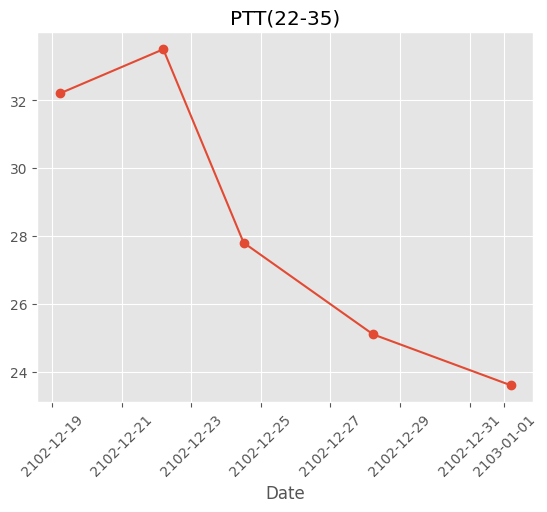

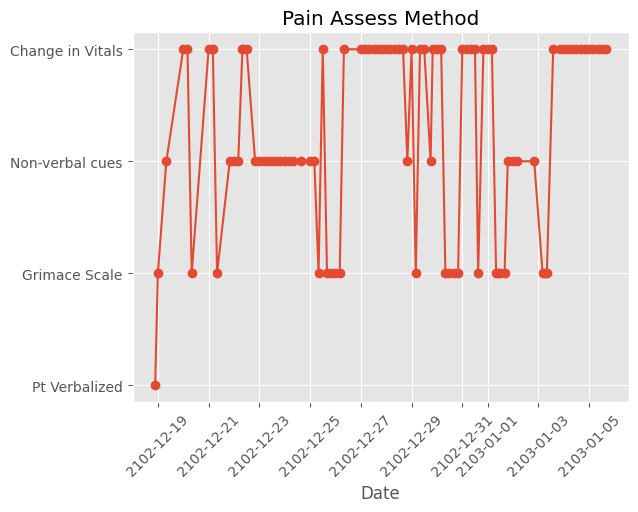

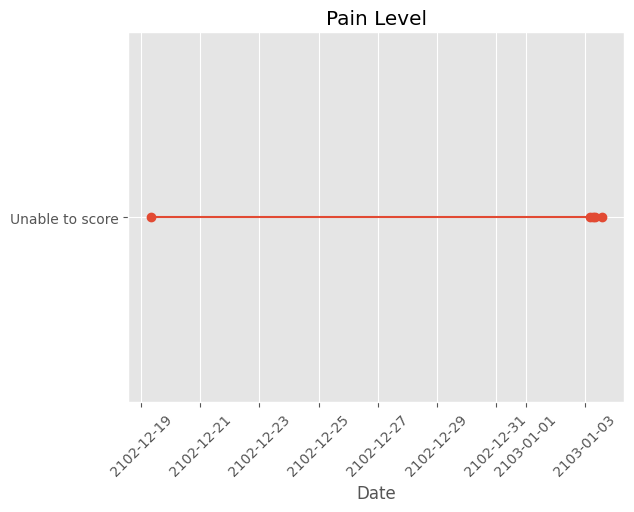

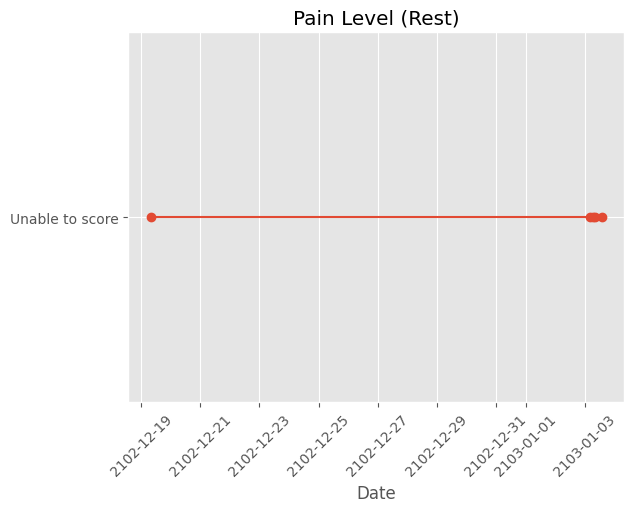

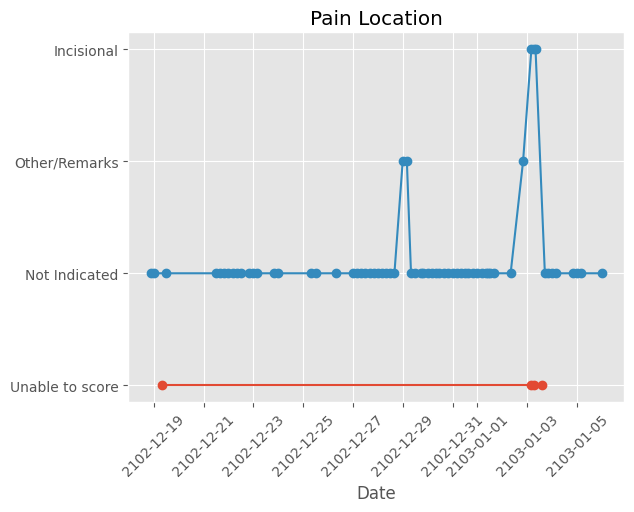

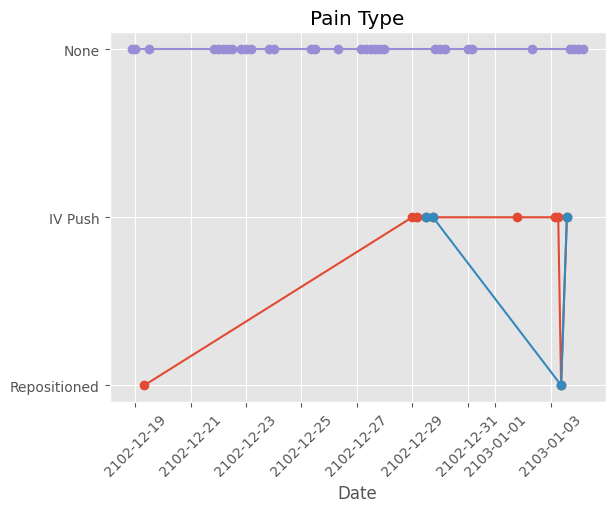

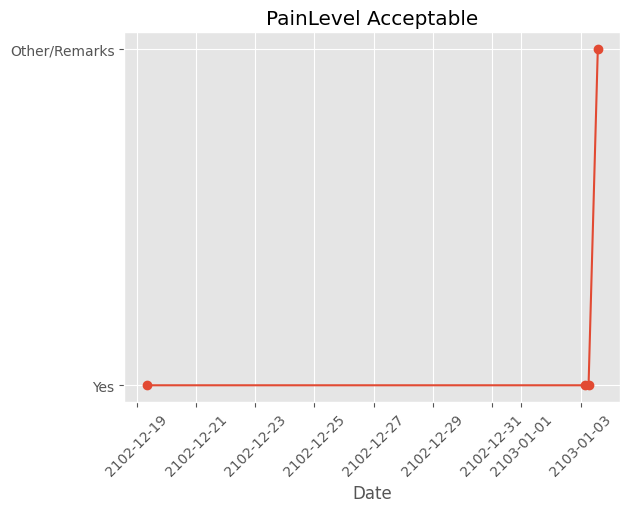

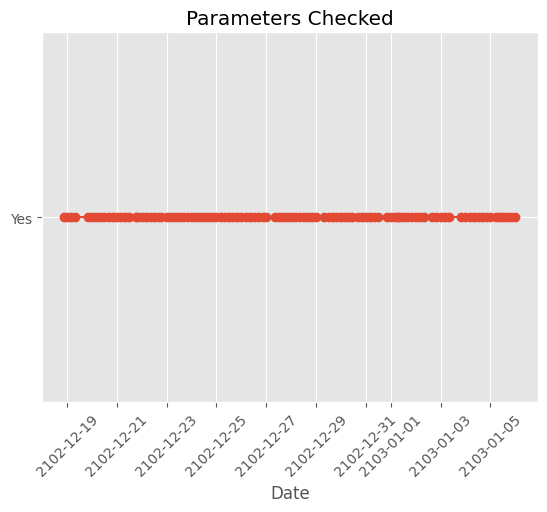

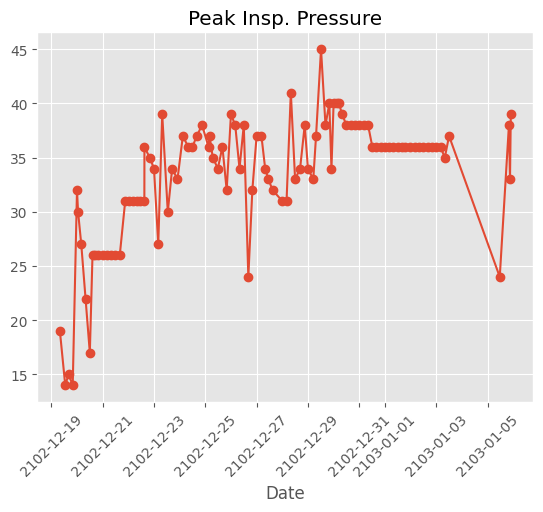

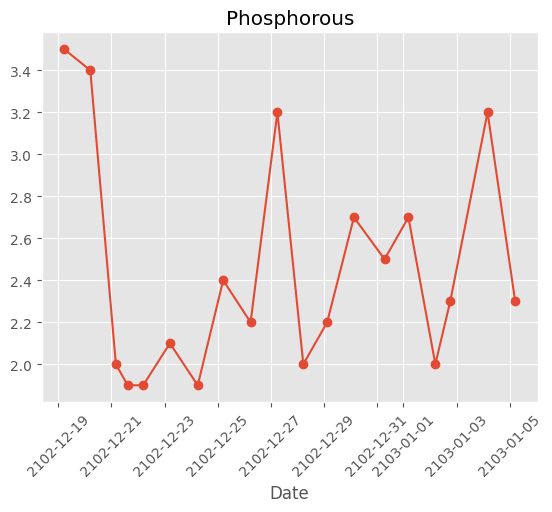

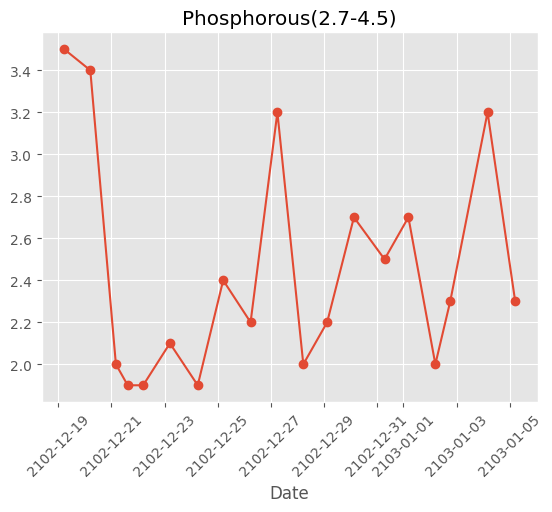

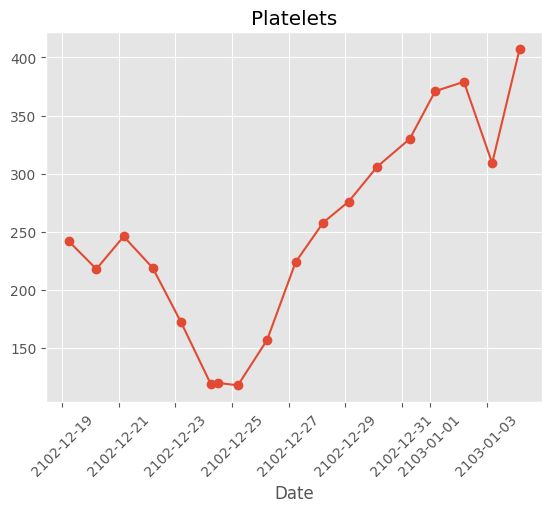

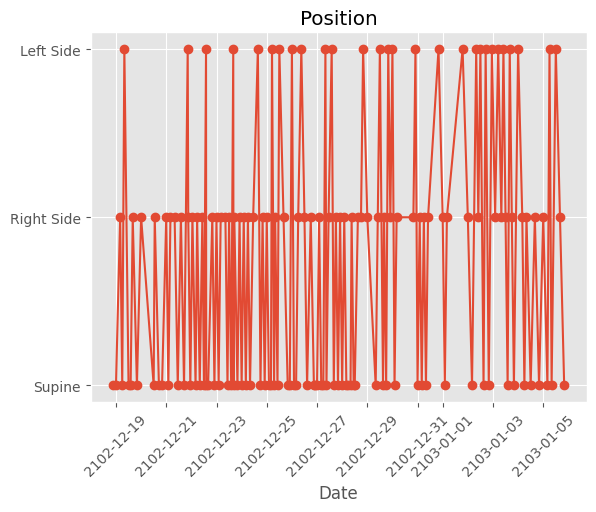

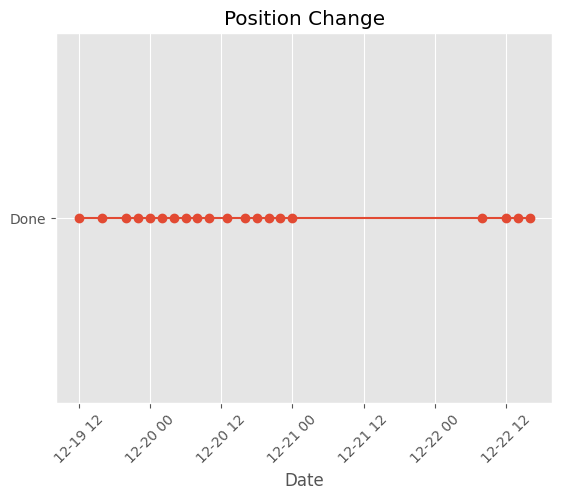

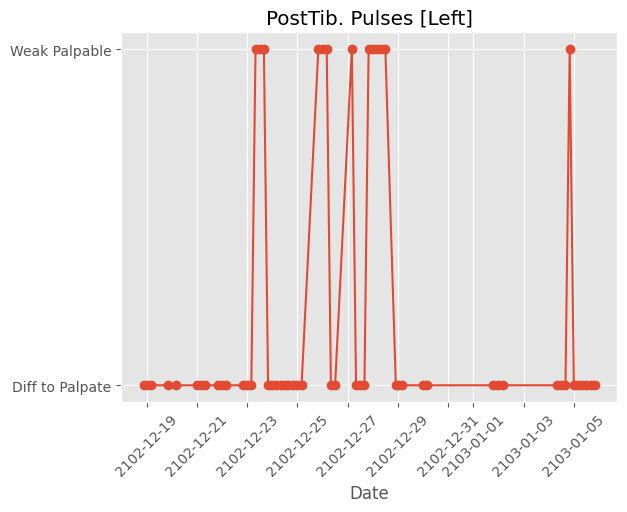

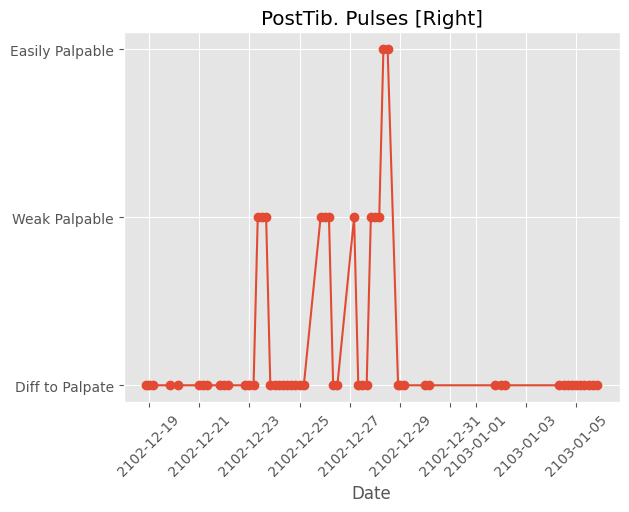

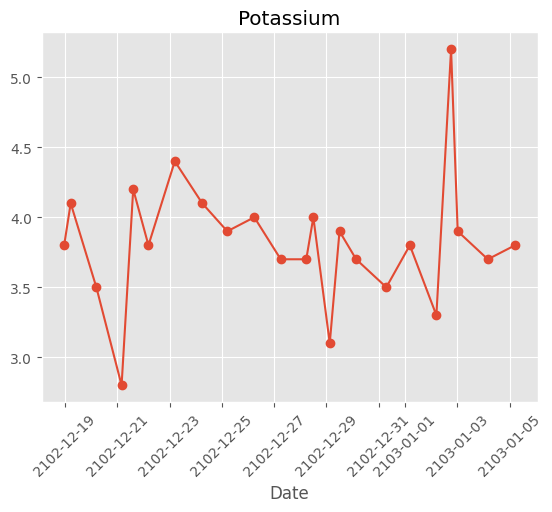

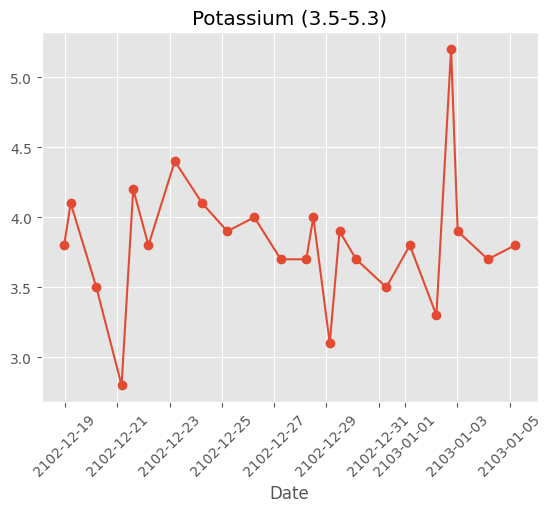

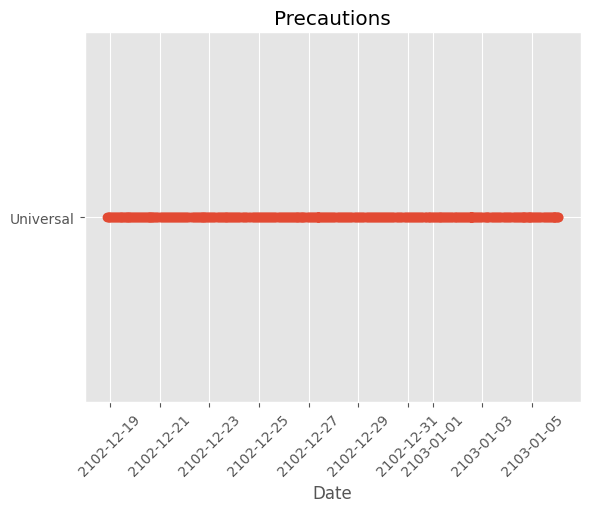

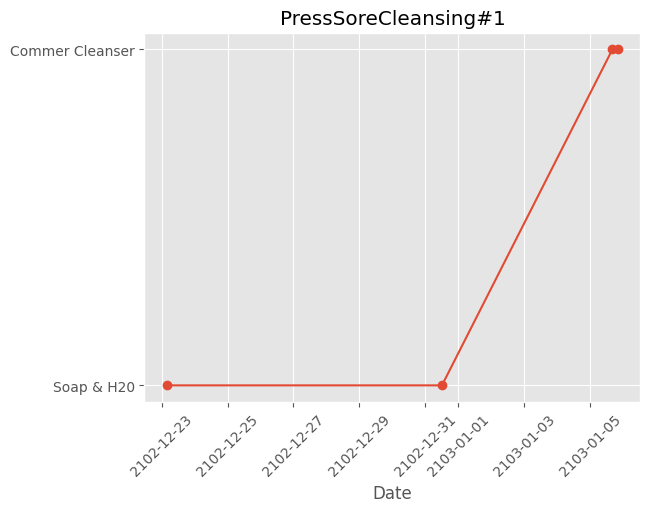

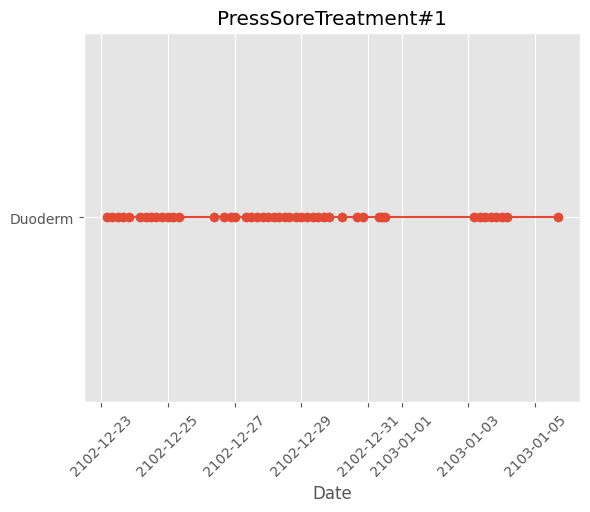

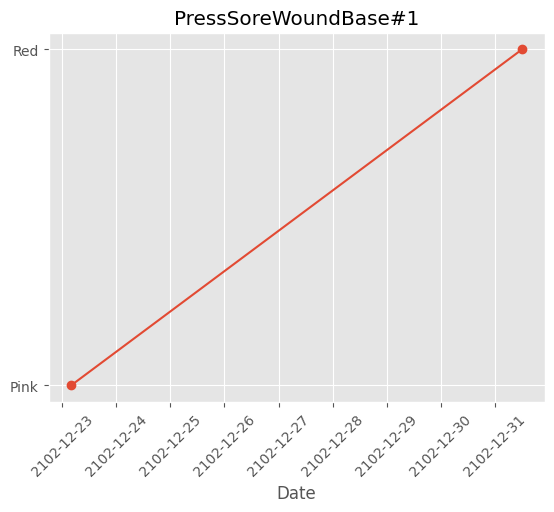

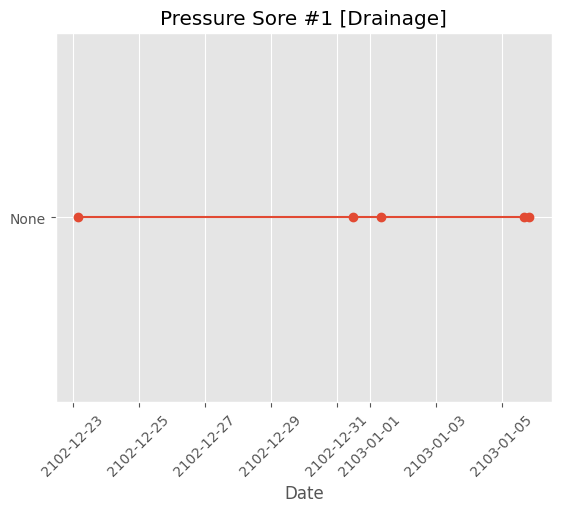

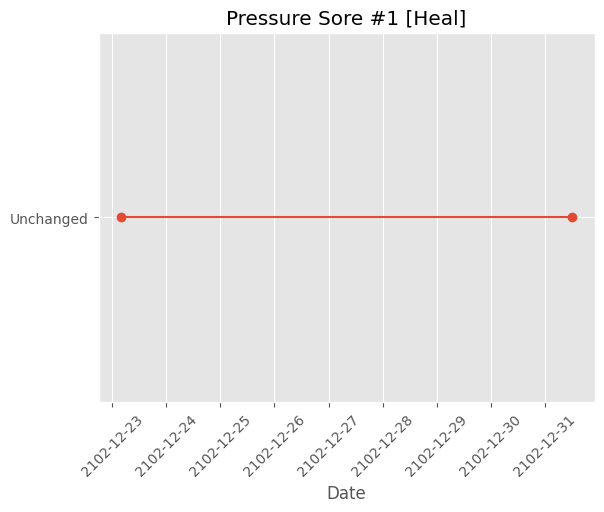

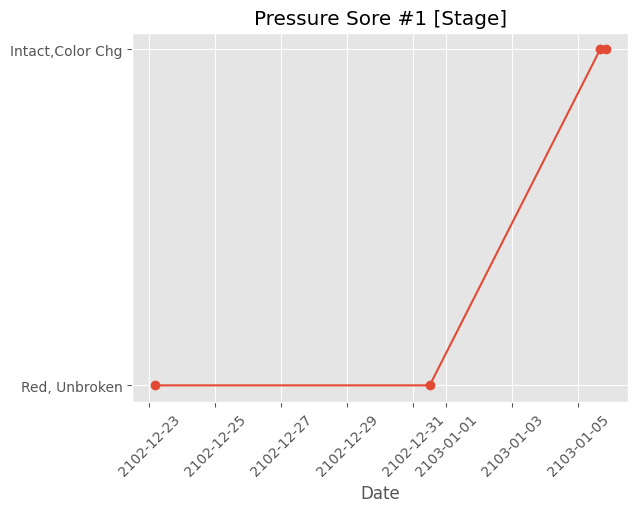

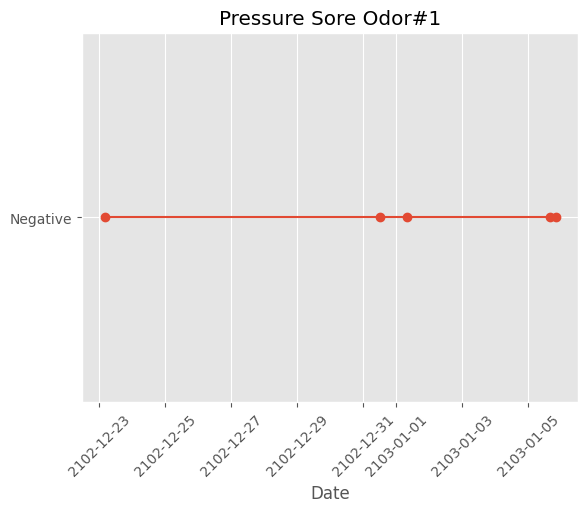

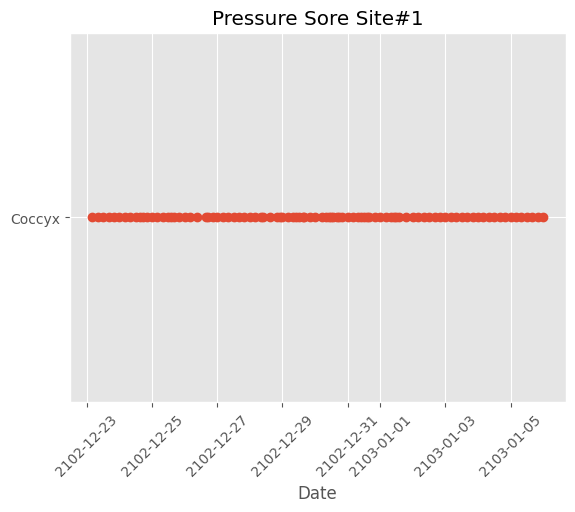

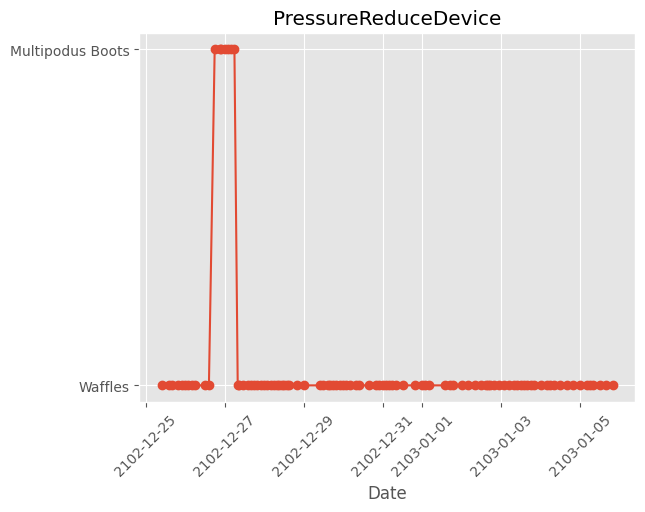

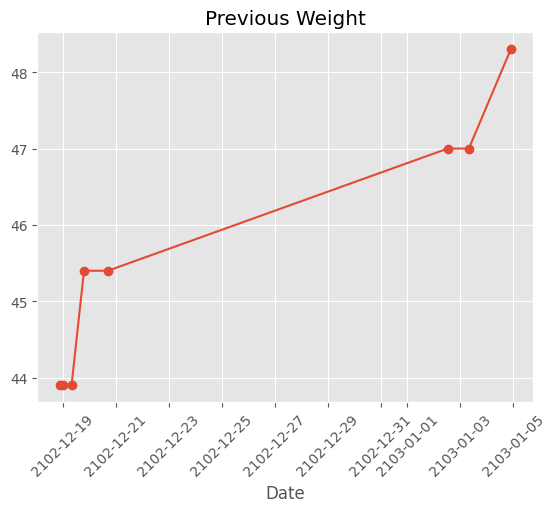

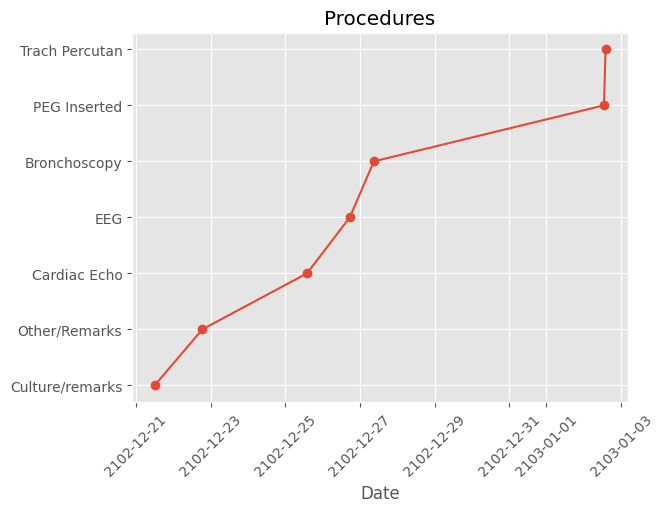

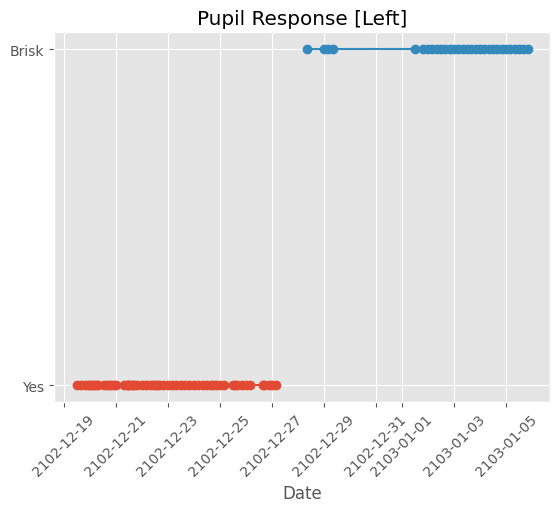

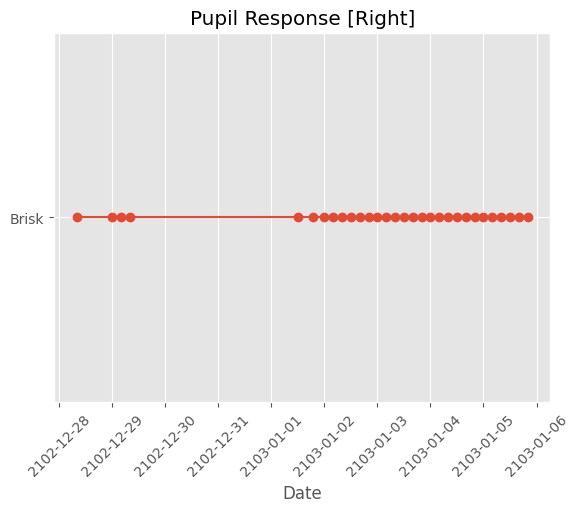

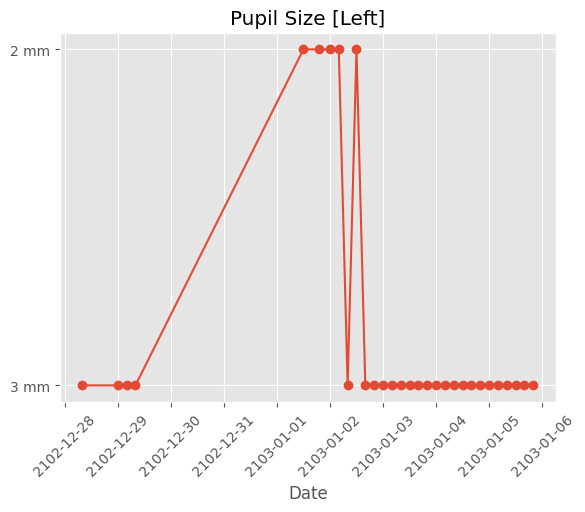

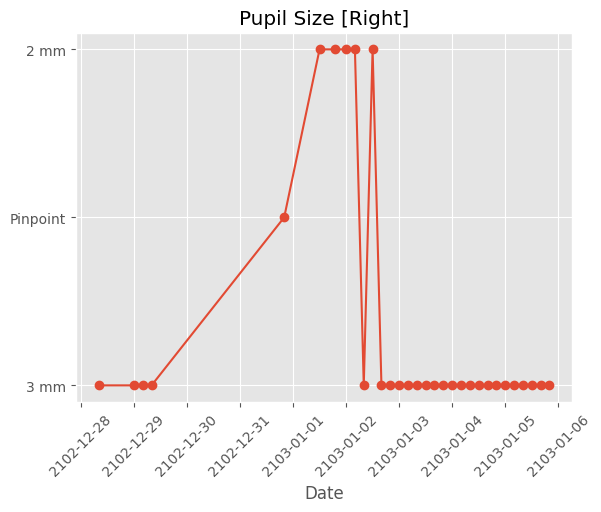

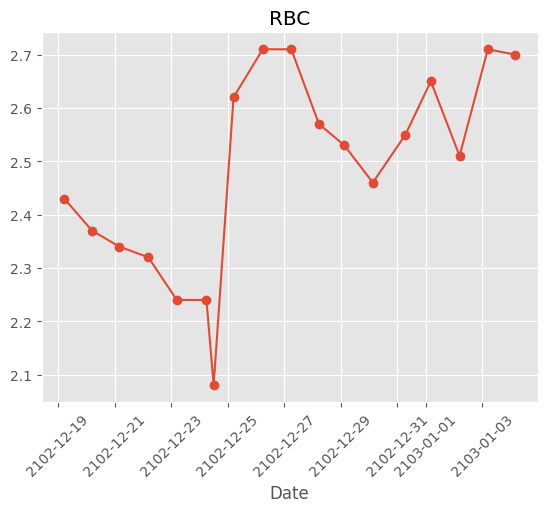

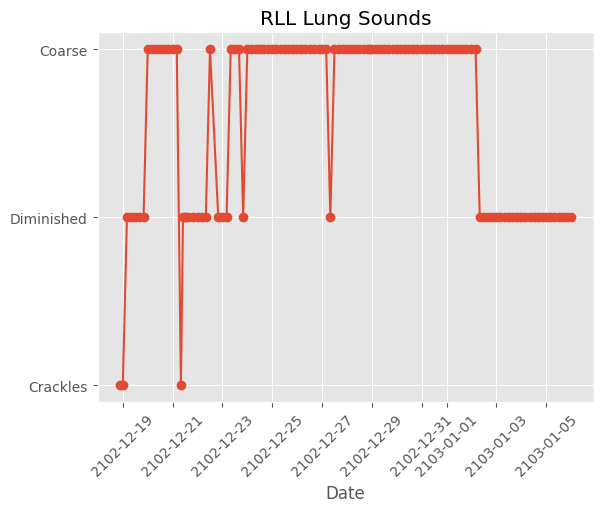

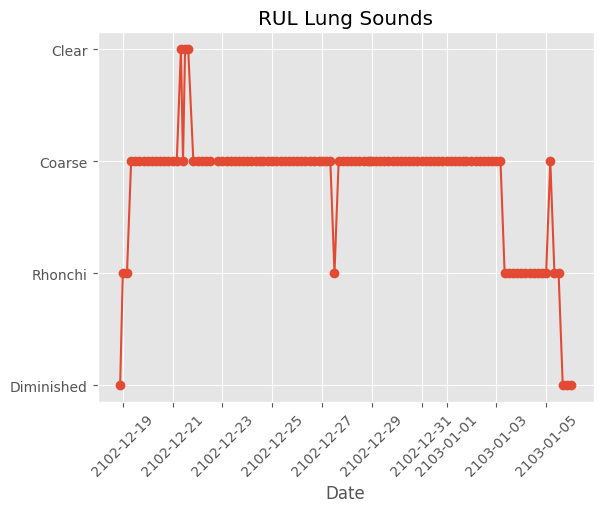

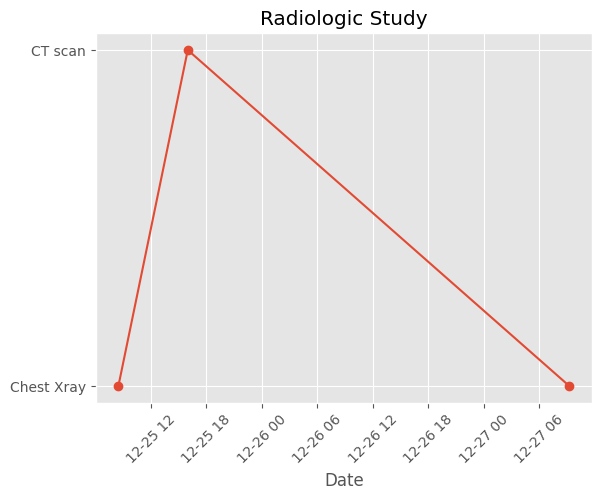

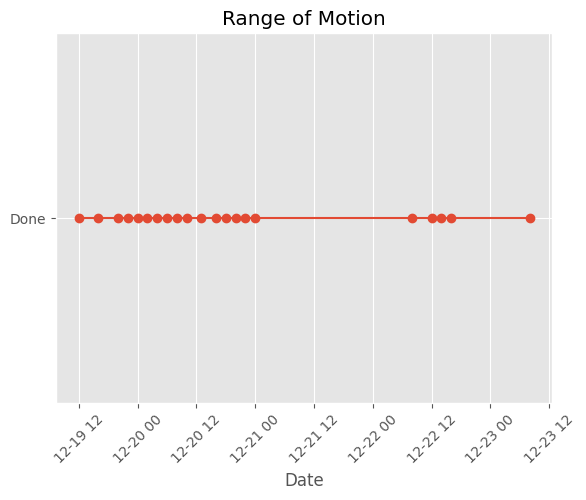

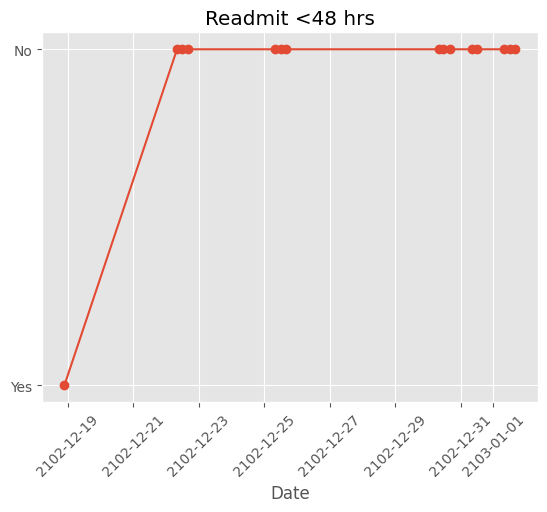

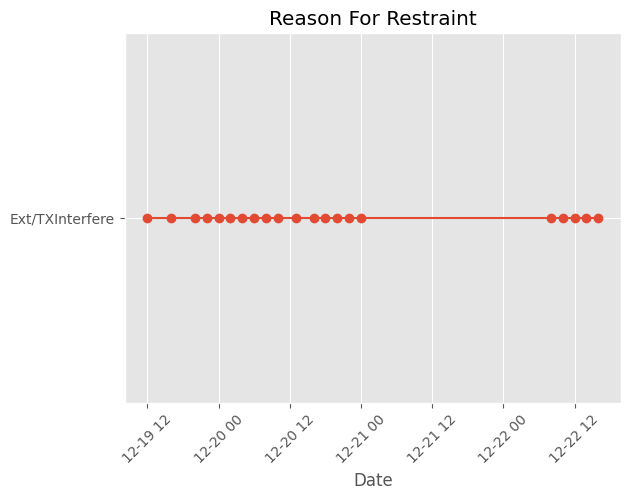

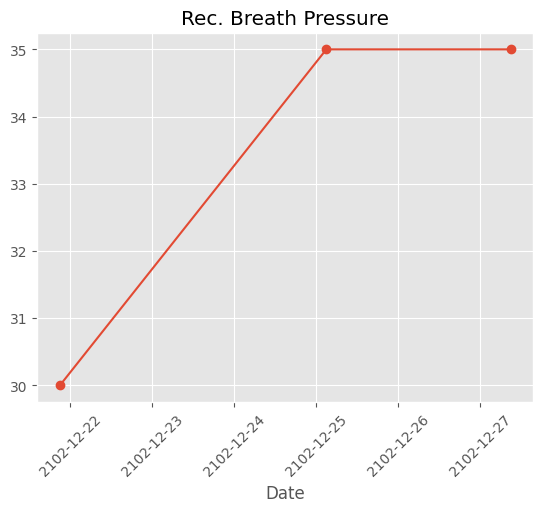

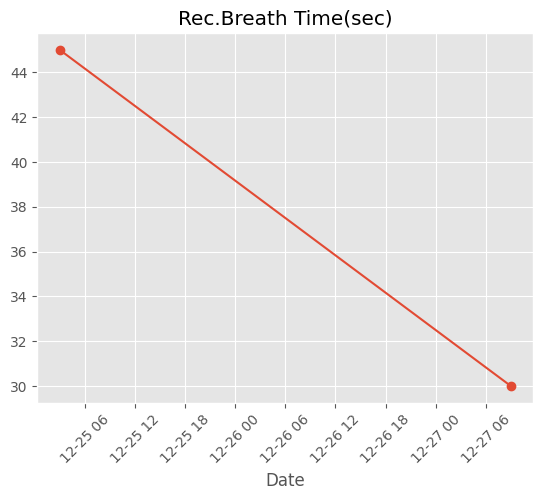

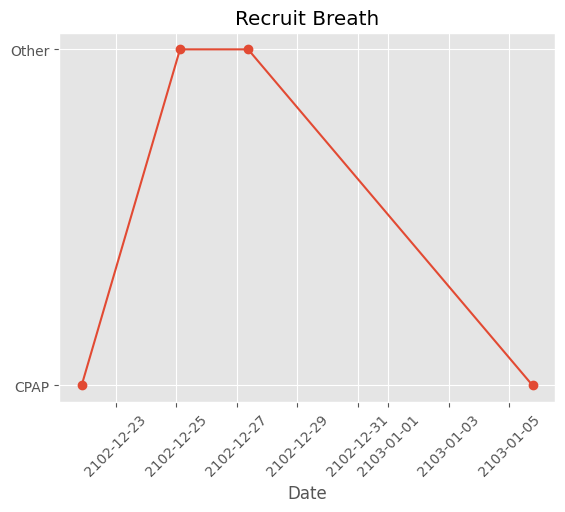

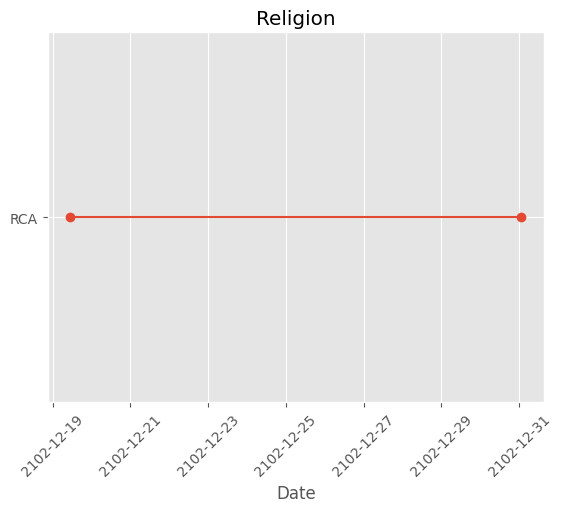

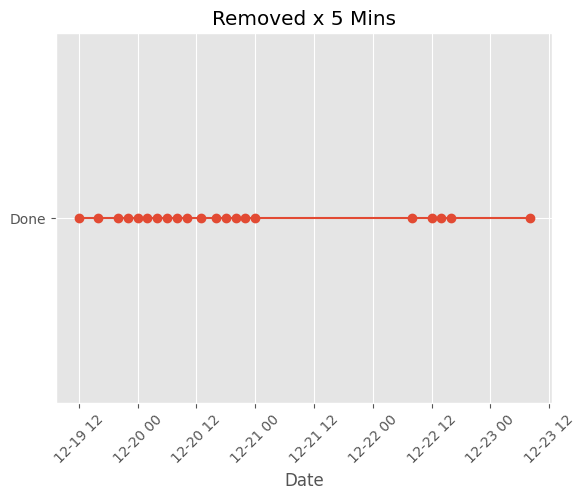

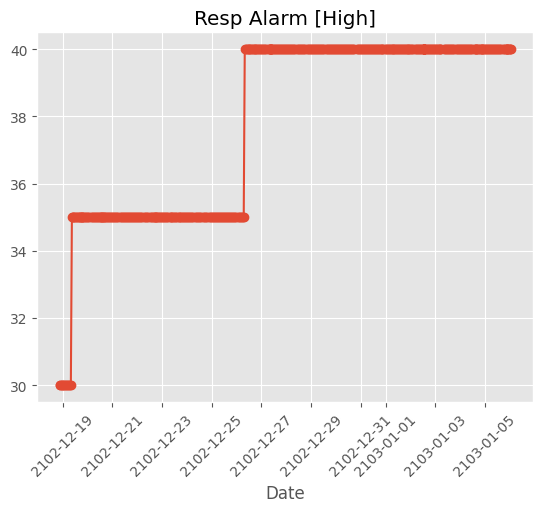

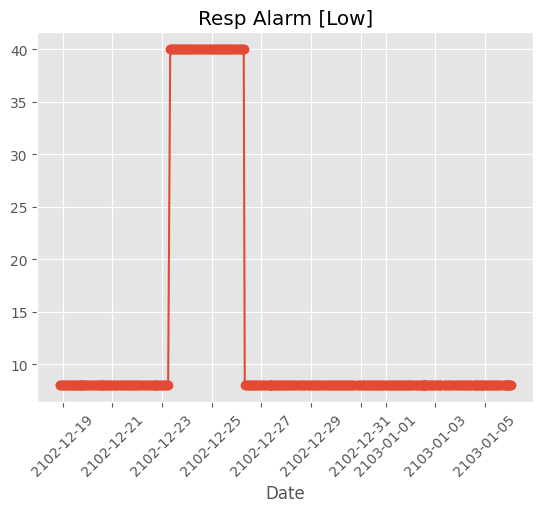

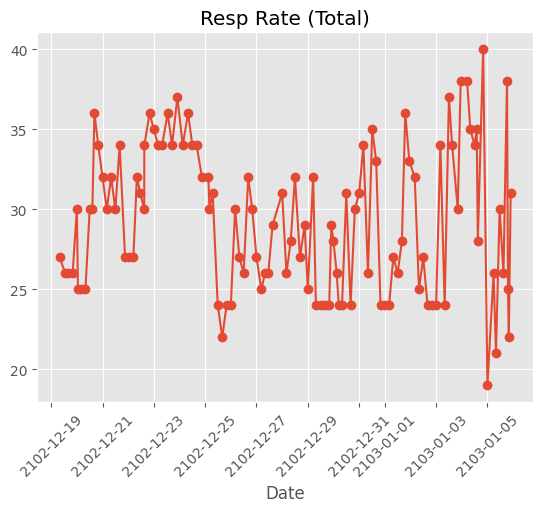

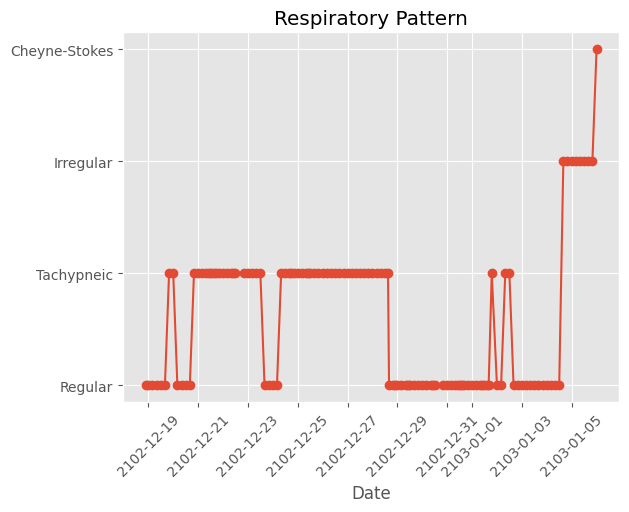

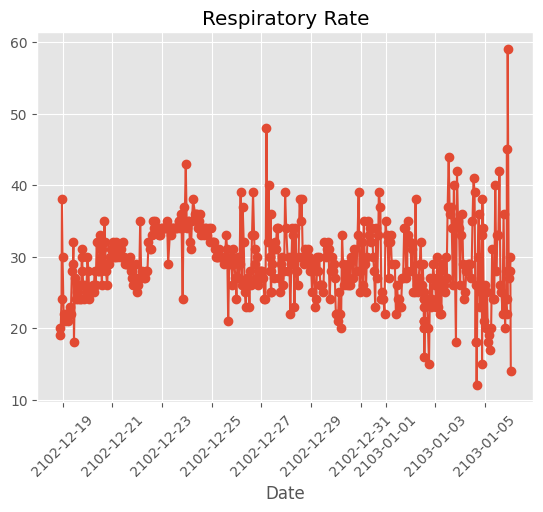

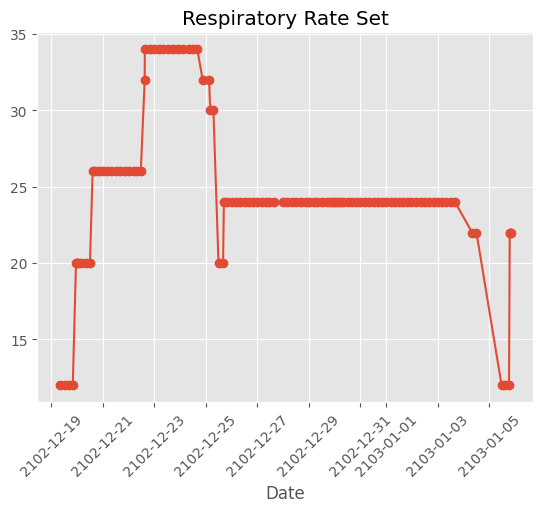

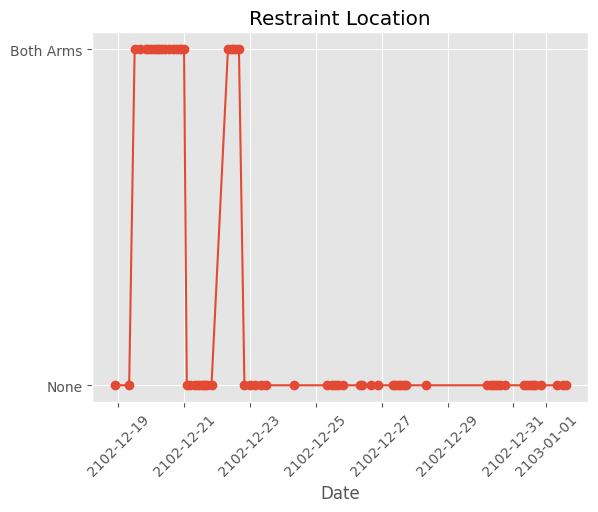

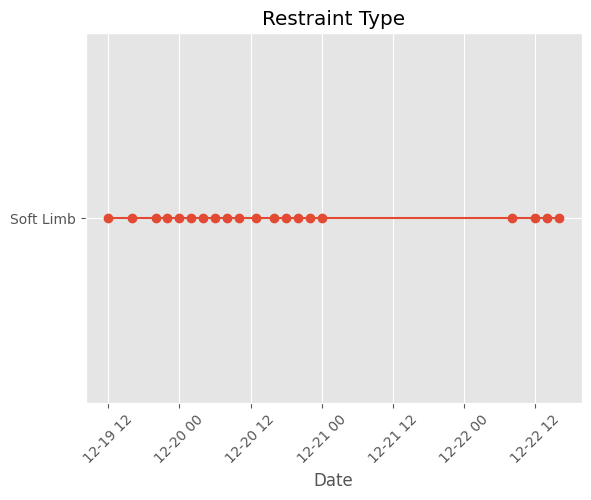

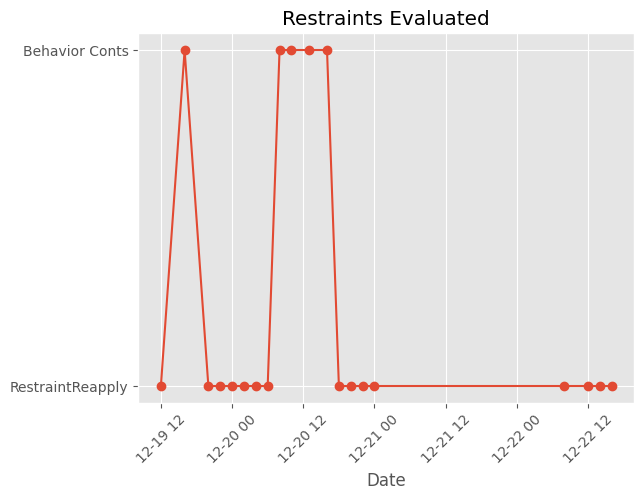

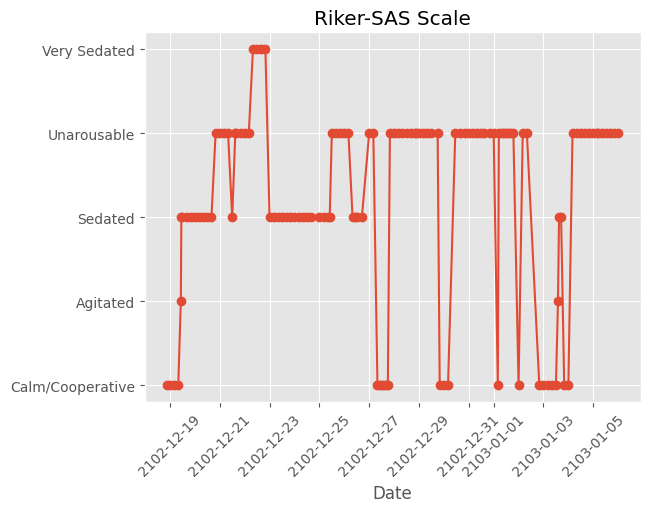

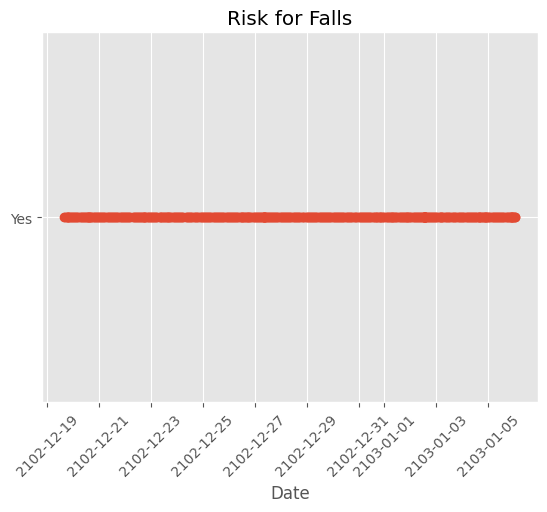

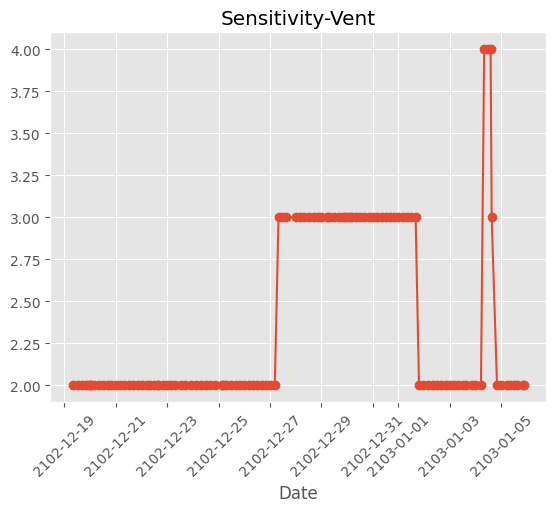

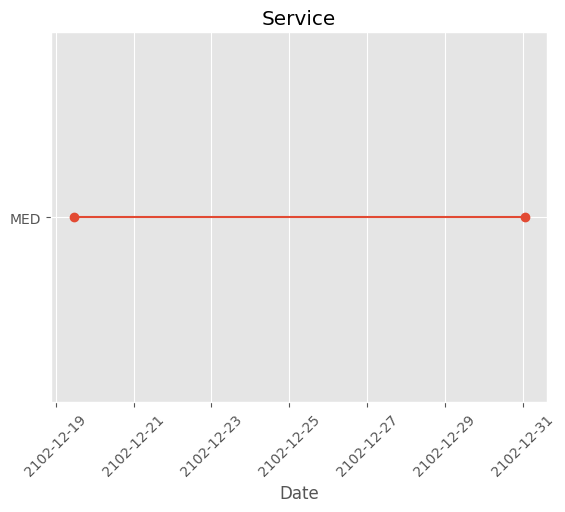

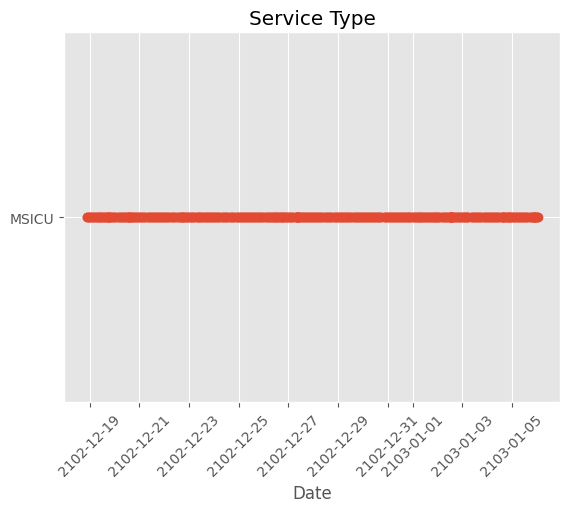

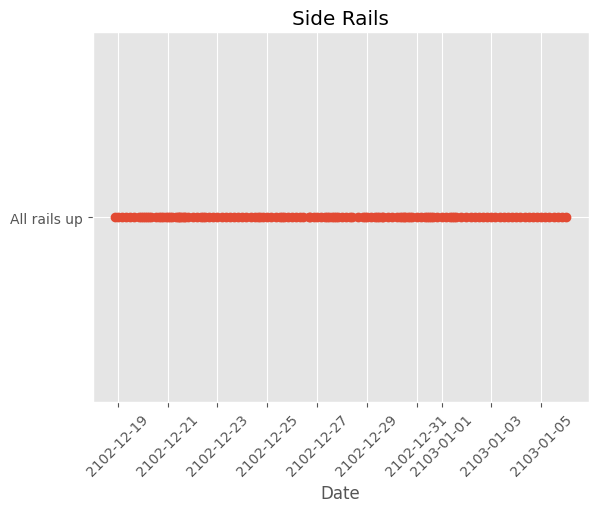

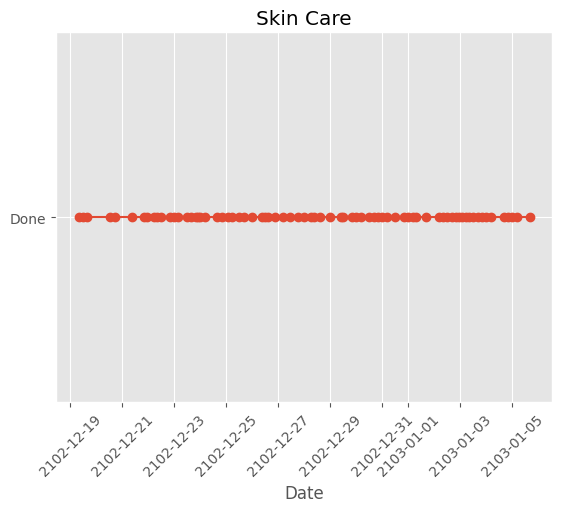

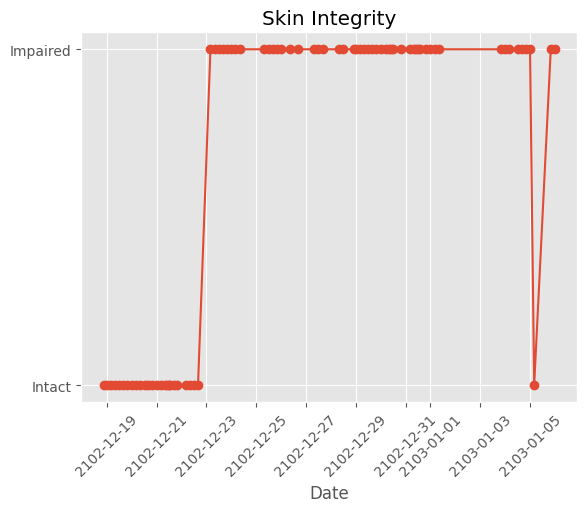

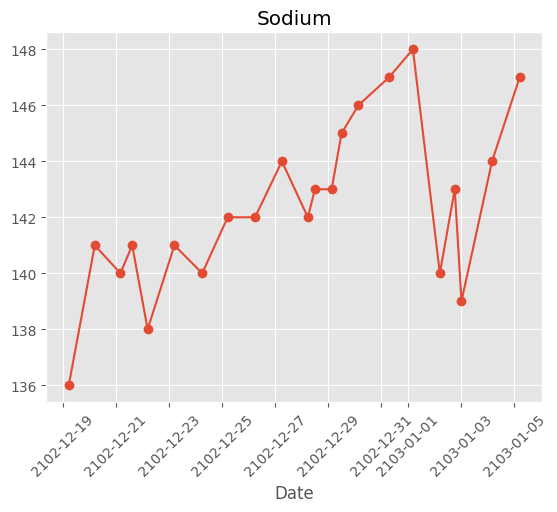

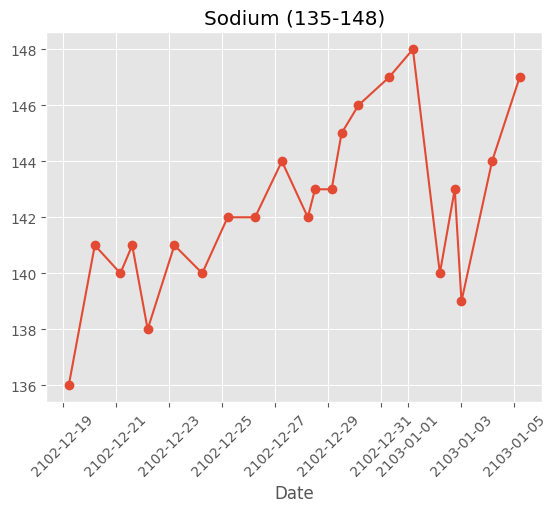

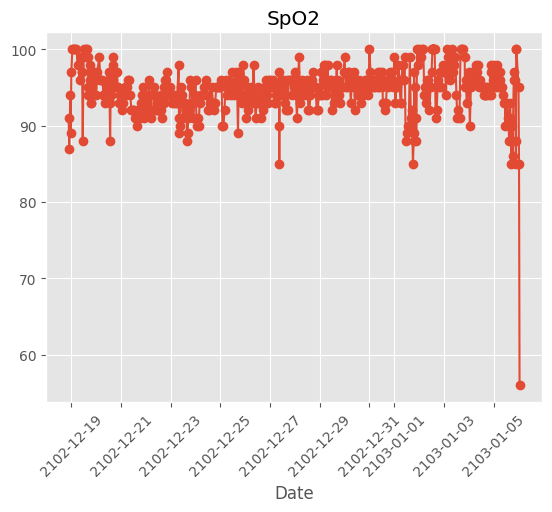

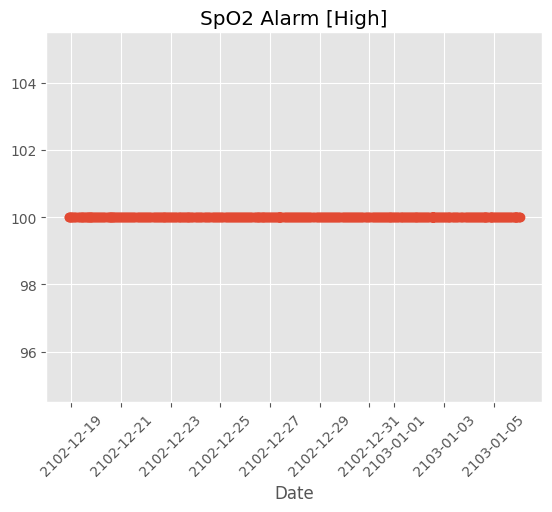

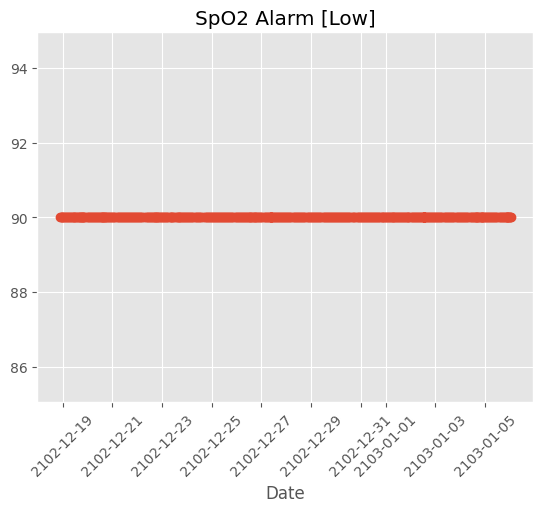

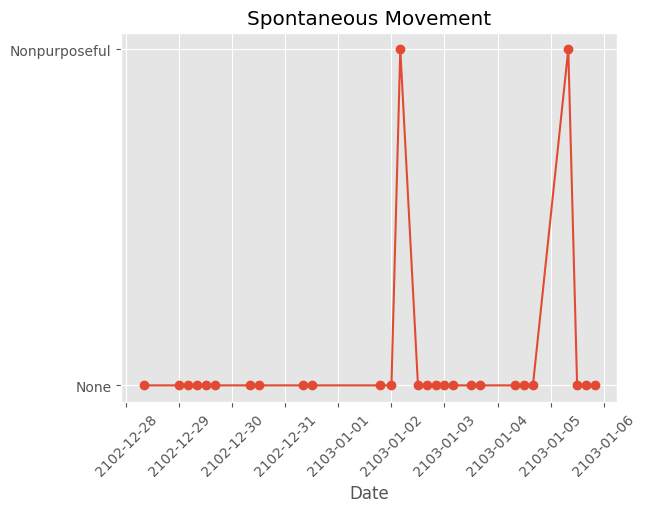

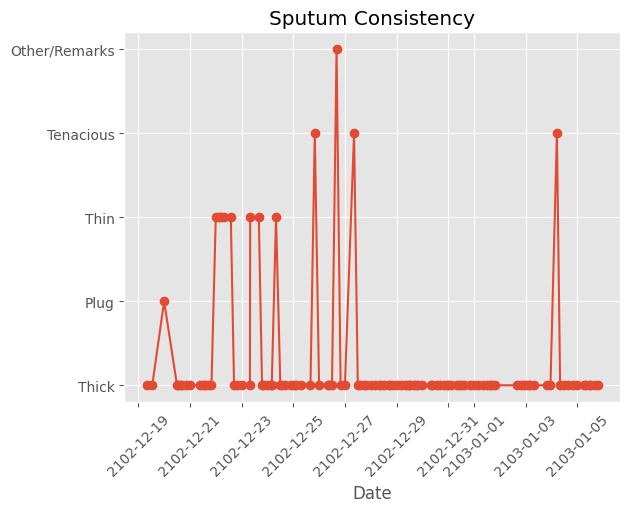

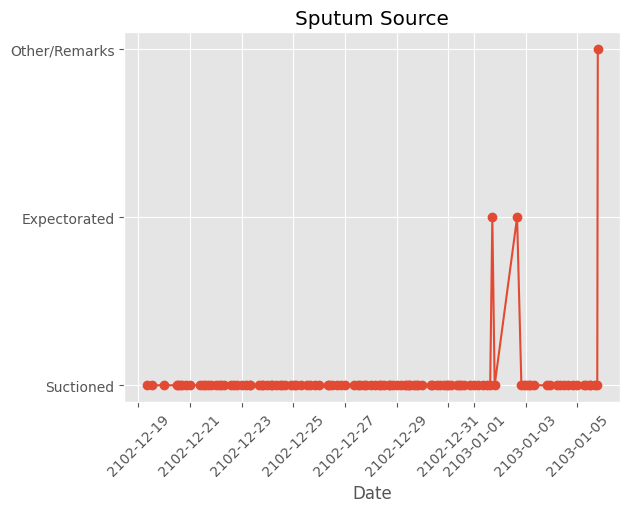

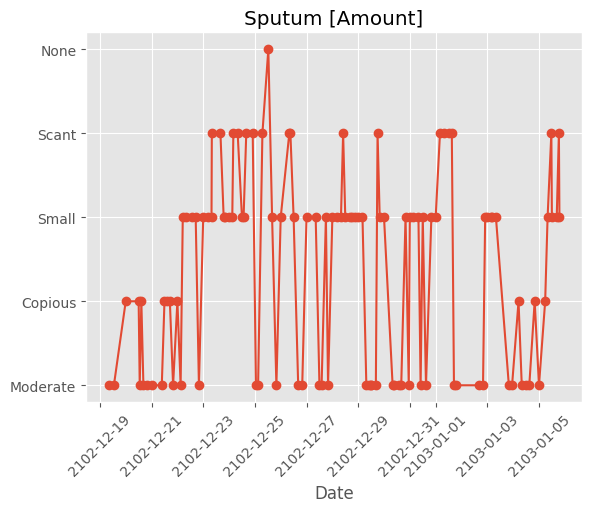

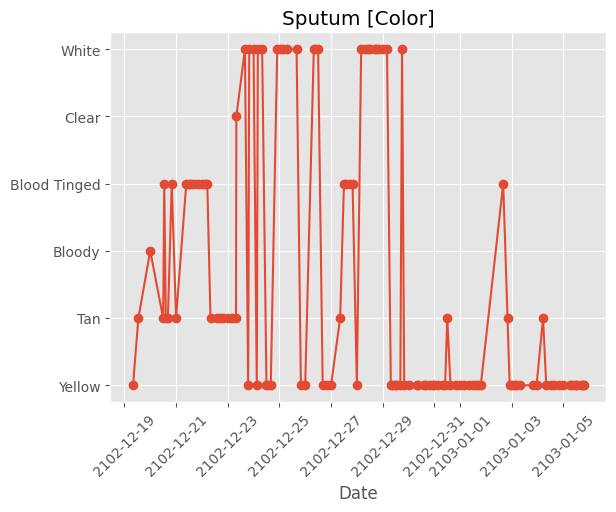

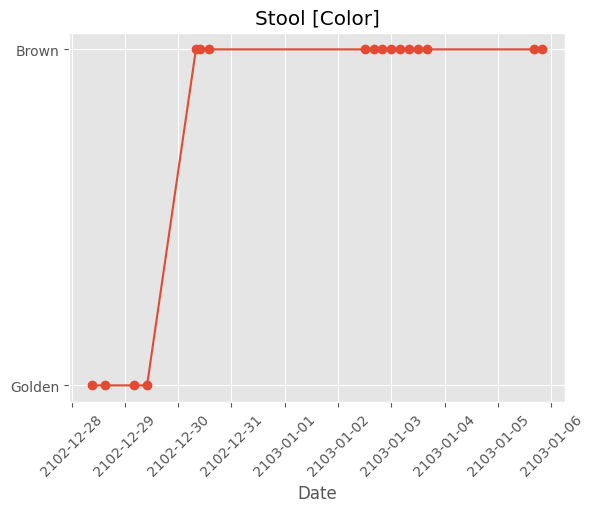

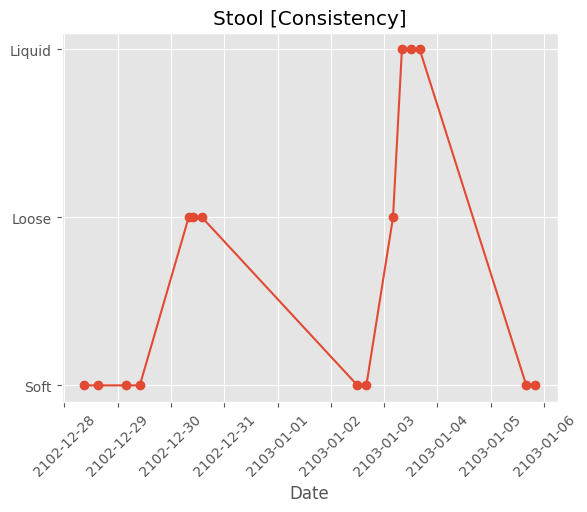

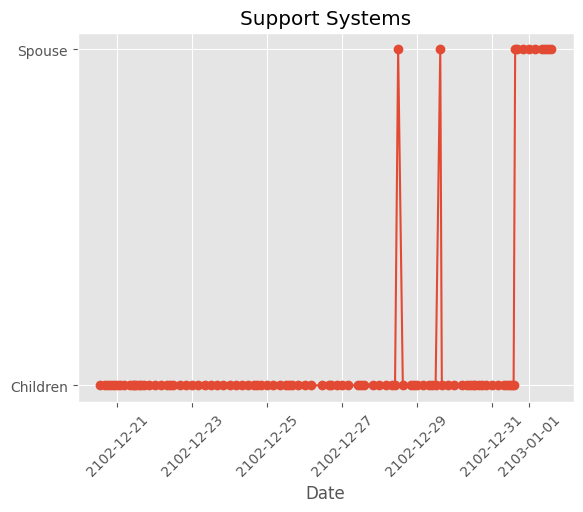

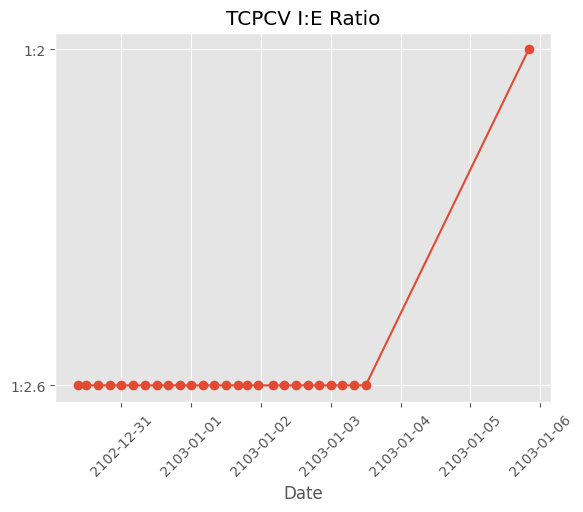

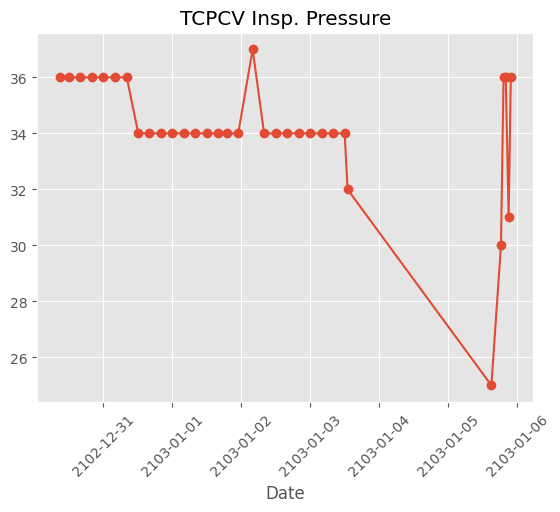

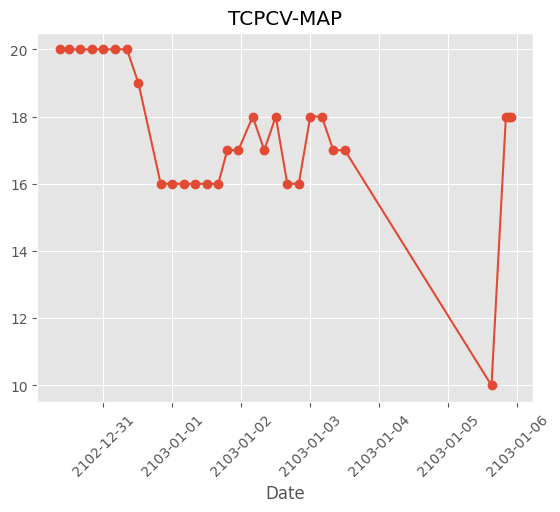

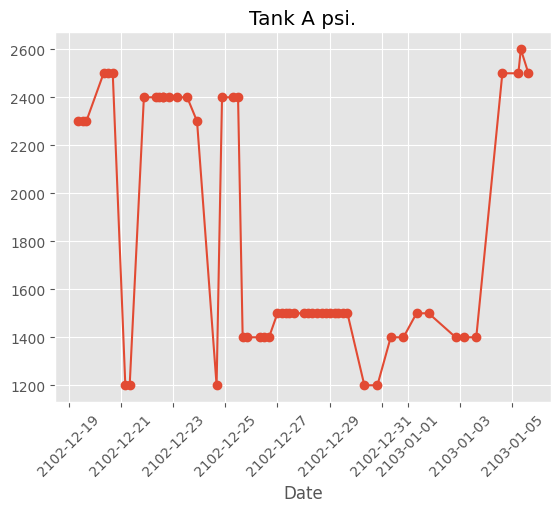

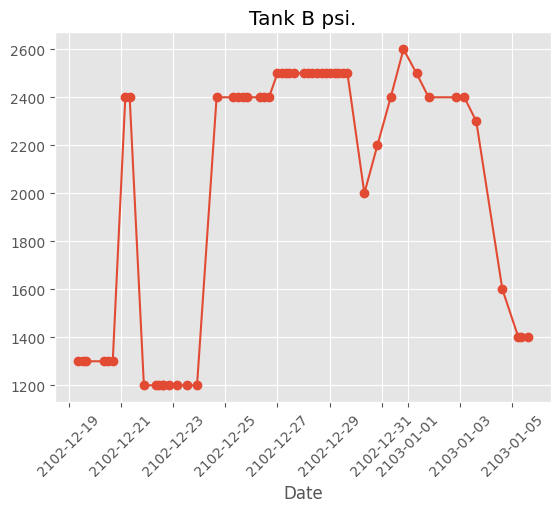

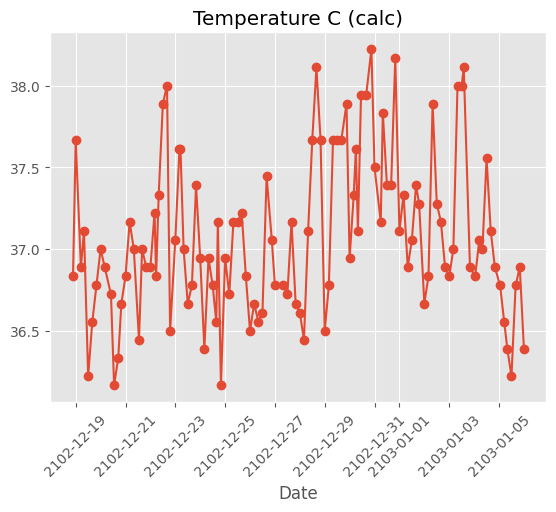

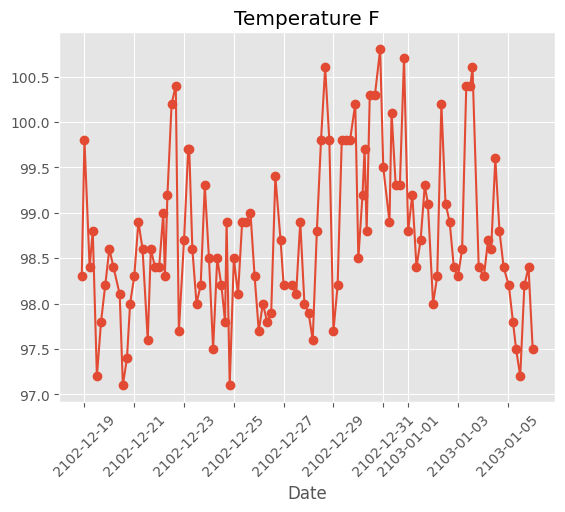

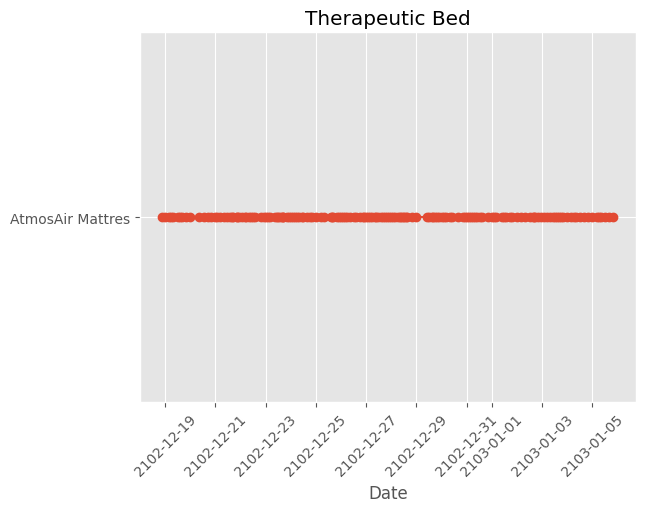

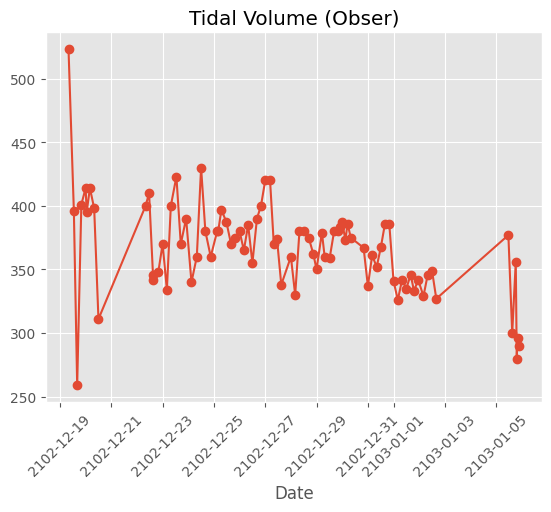

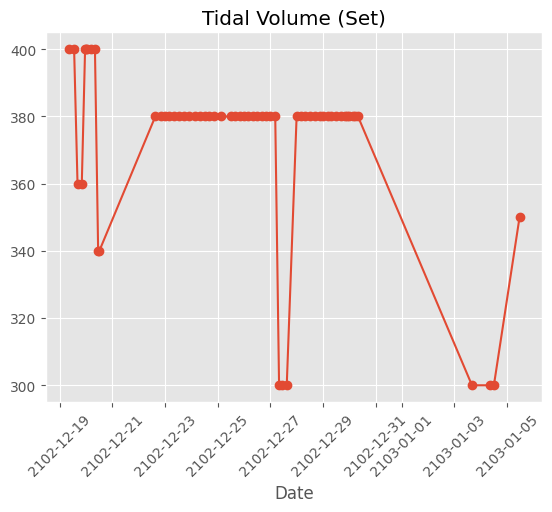

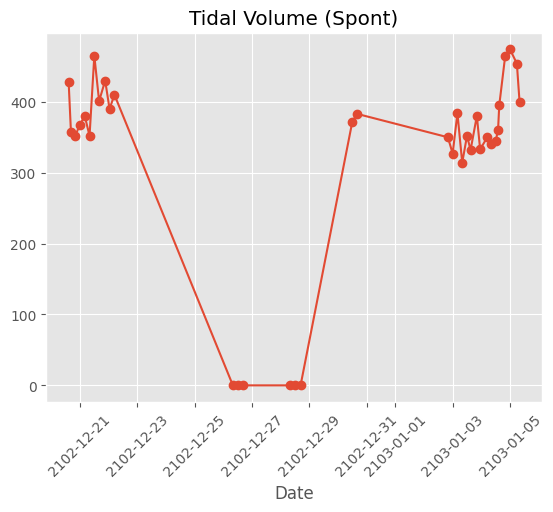

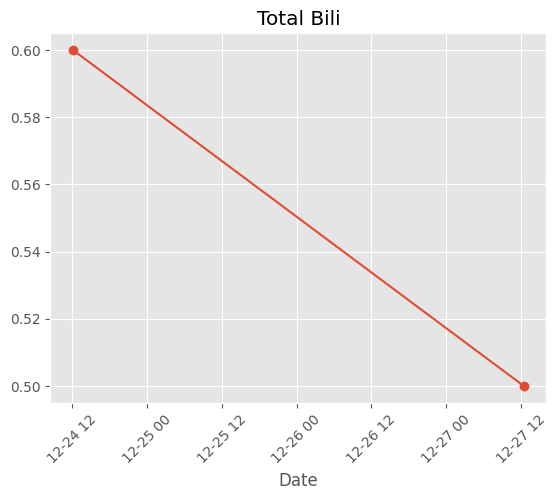

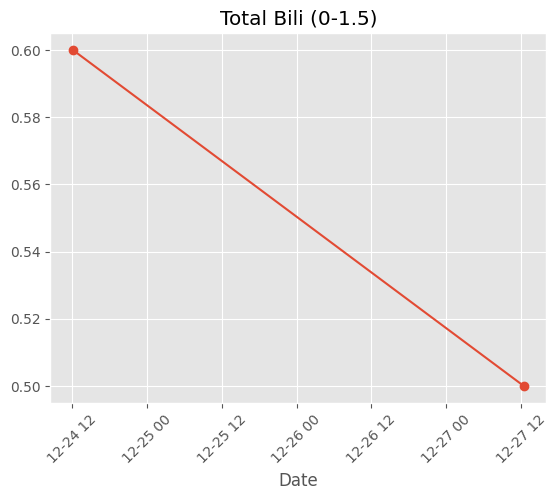

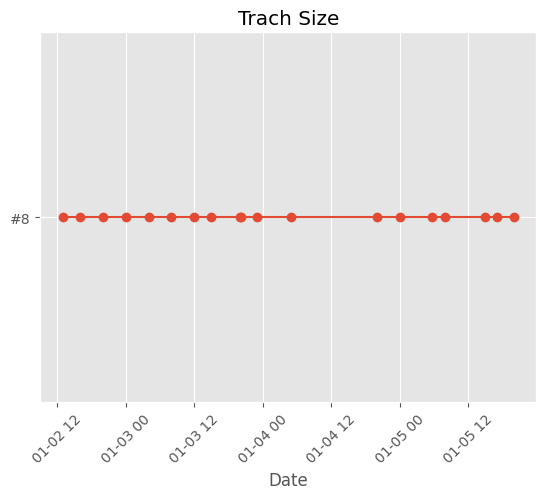

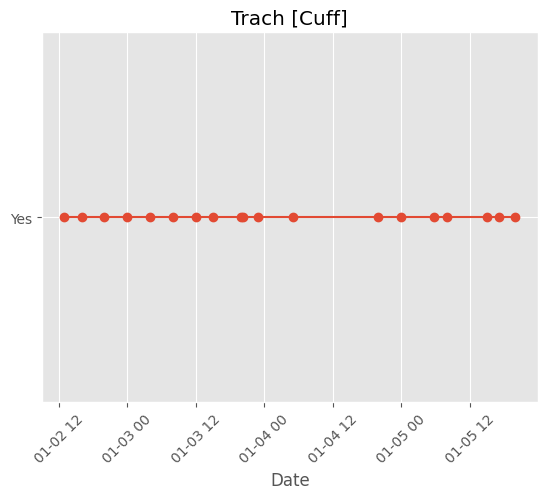

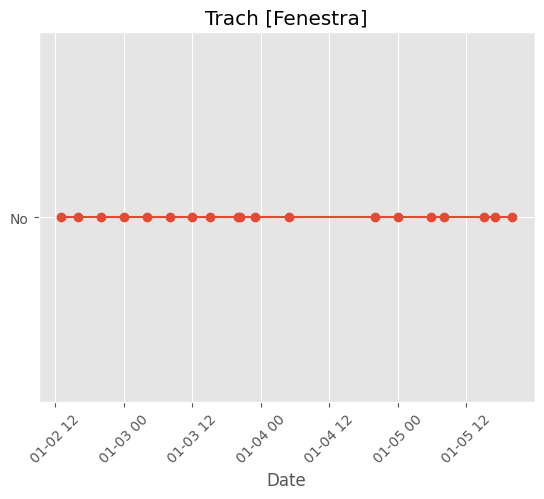

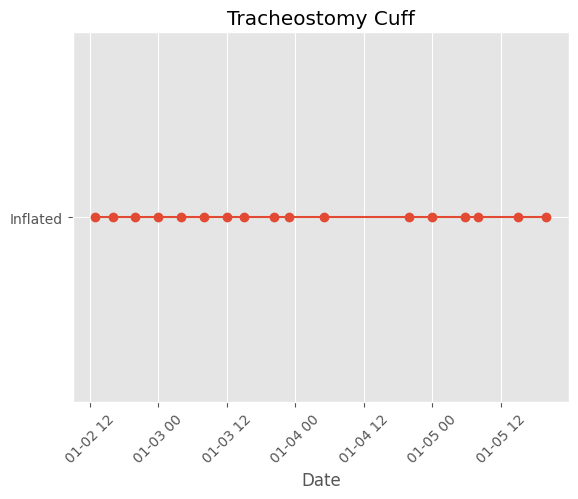

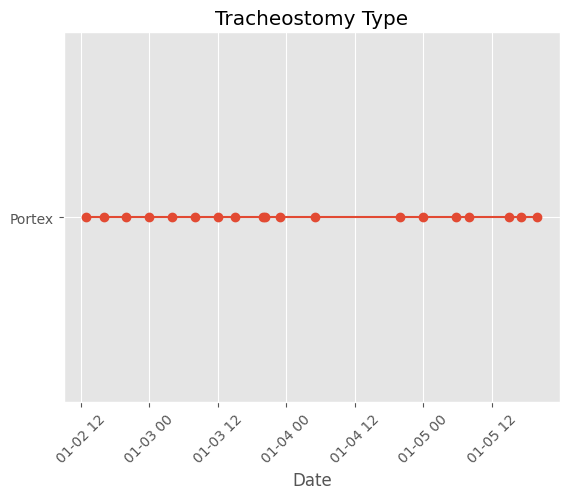

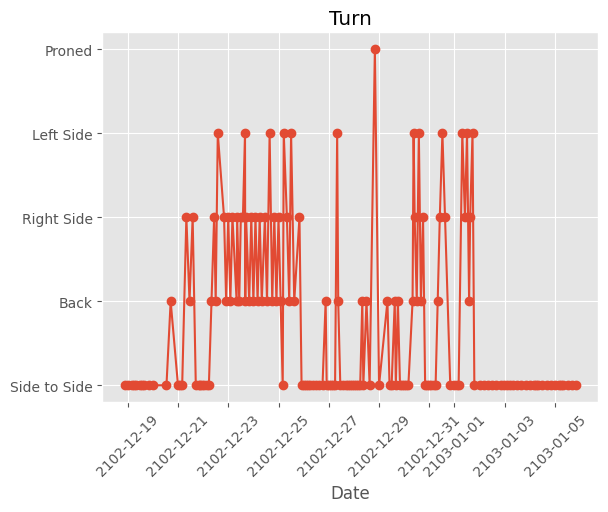

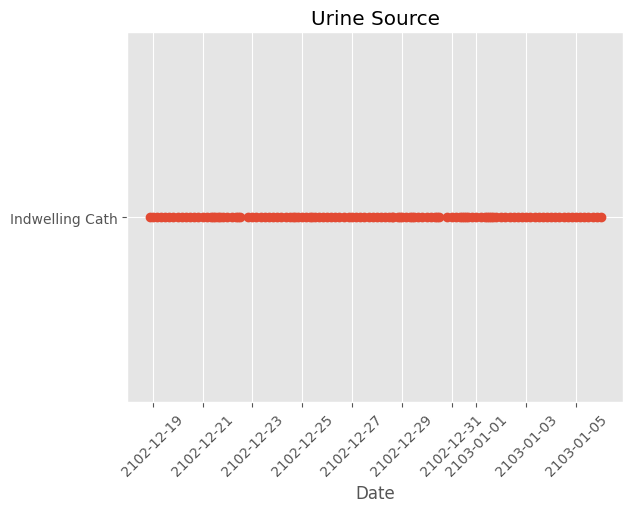

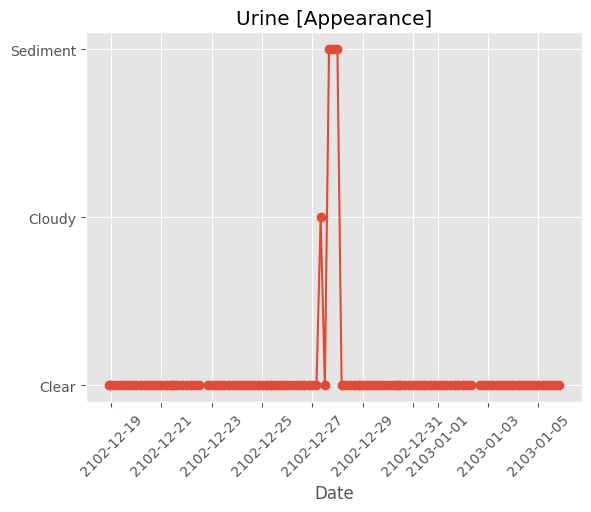

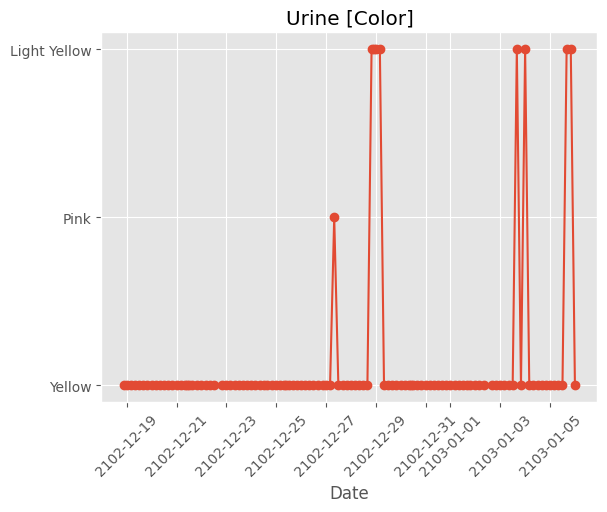

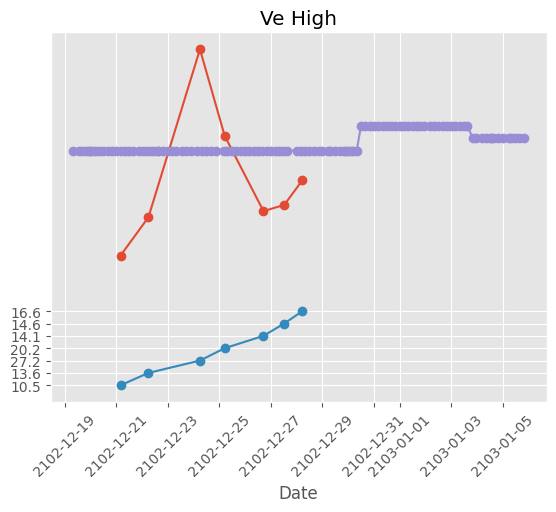

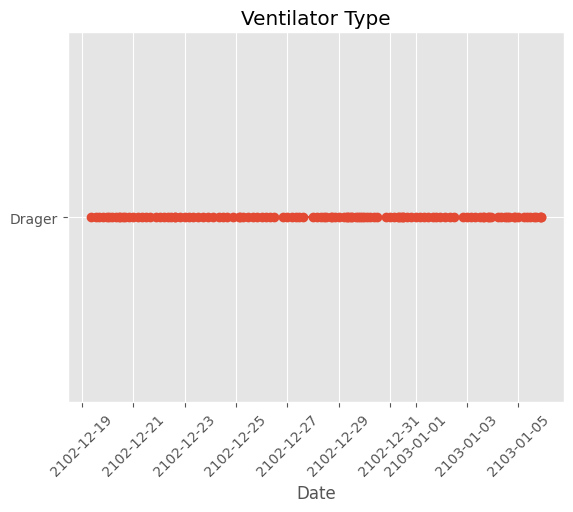

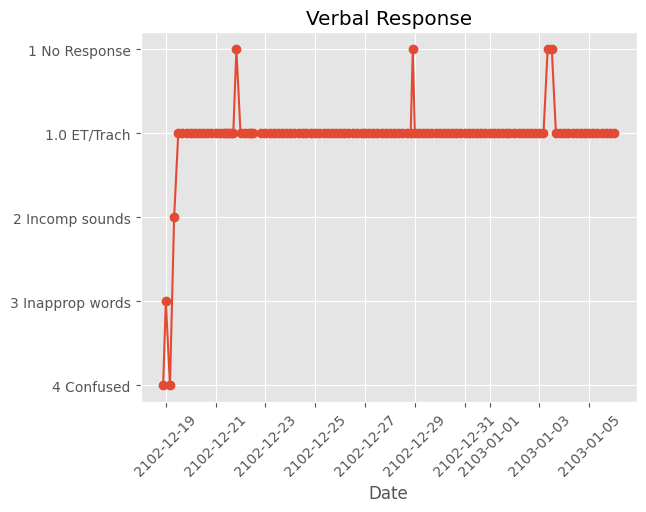

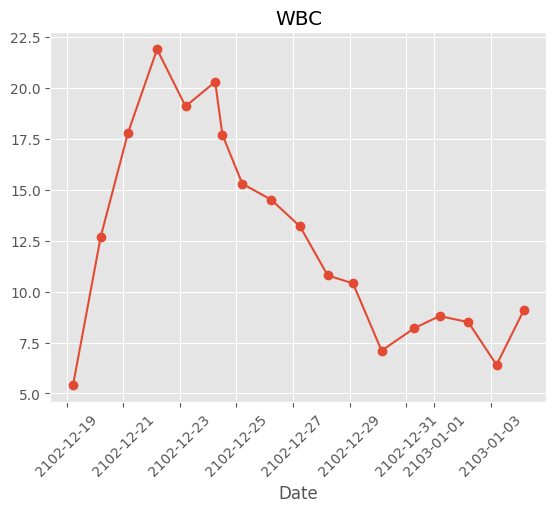

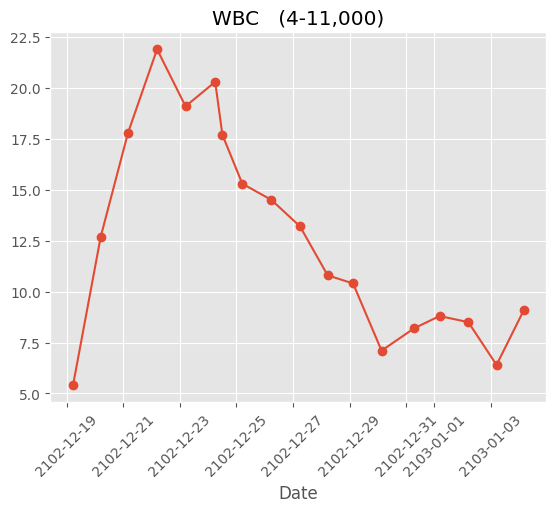

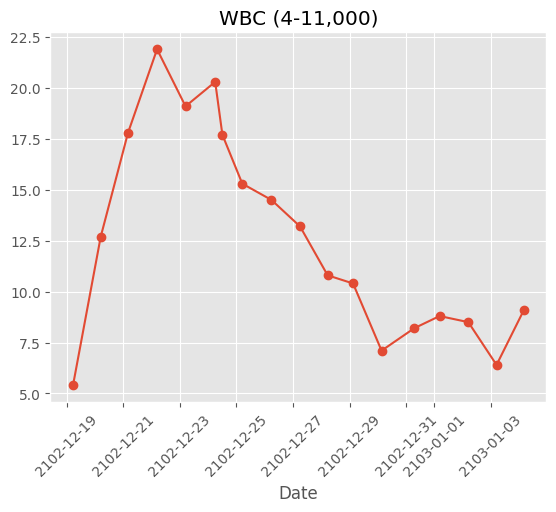

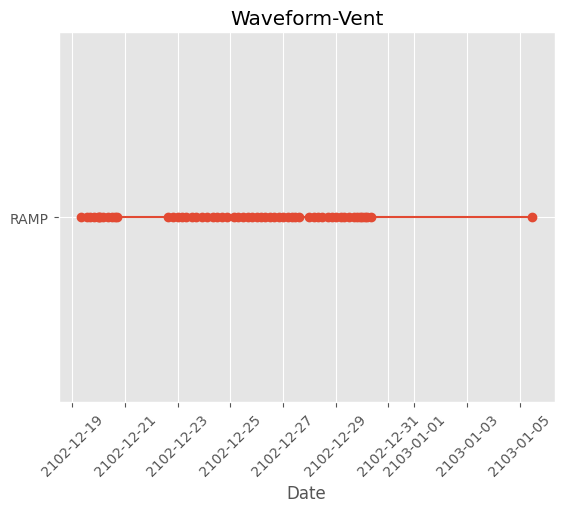

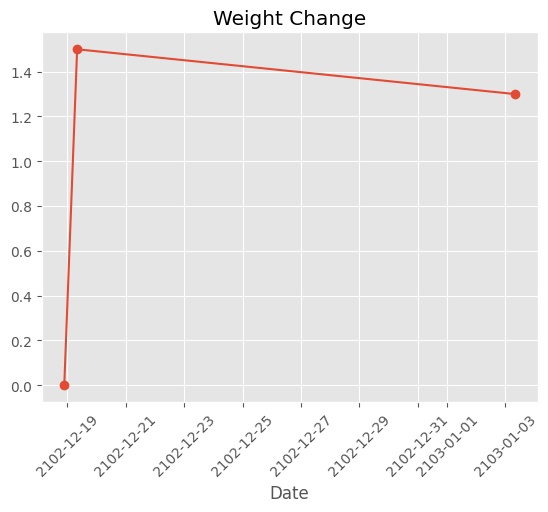

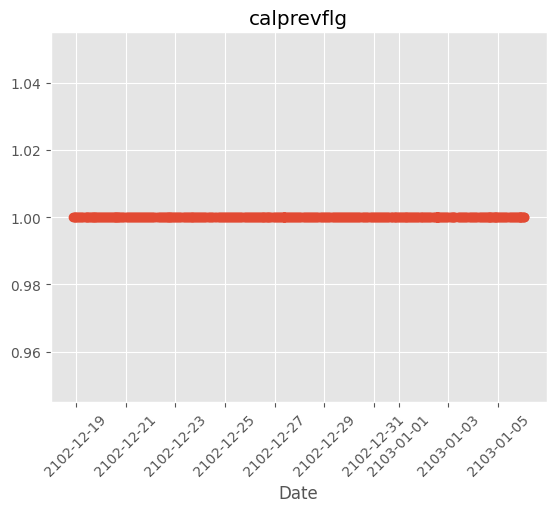

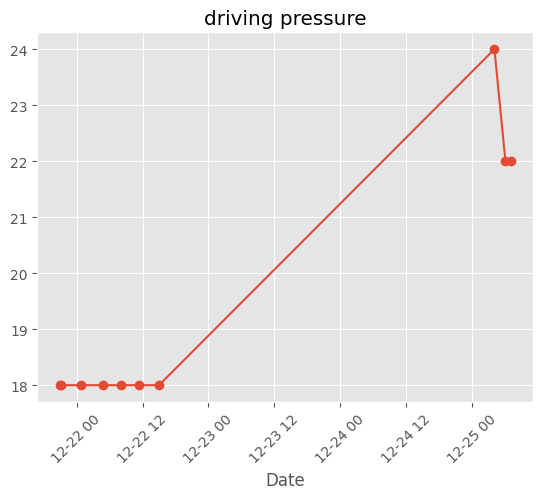

In [37]:
# plot_path = "plots/" + str(subject_id) + "/"
# if not os.path.exists(plot_path):
#     os.mkdir(plot_path)
# else:
#     for file in os.listdir(plot_path):
#         os.remove(os.path.join(plot_path, file))
        
for label in np.unique(df_CHARTEVENTS["label"]):
    try:
        df_work_of_breathing = df_CHARTEVENTS[df_CHARTEVENTS["label"]==label]

        if None not in list(df_work_of_breathing["value"]) and len(list(df_work_of_breathing["value"]))>1:
            try:
                list_plot = list(map(float, list(df_work_of_breathing["value"])))
                plt.plot(df_work_of_breathing["charttime"], list_plot, 'o-')
                plt.xlabel("Date")
                plt.xticks(rotation=45)
                plt.title(label)
                plt.savefig(plot_path+f'{label}.png')
                plt.show()
            except:
                list_plot = df_work_of_breathing["value"]
                plt.plot(df_work_of_breathing["charttime"], list_plot, 'o-')
                plt.xlabel("Date")
                plt.xticks(rotation=45)
                plt.title(label)
                plt.savefig(plot_path+f'{label}.png')
                plt.show()
            
    except:
        pass

In [38]:
query = query_schema + """
SELECT label, fluid, value, value, flag, charttime
FROM LABEVENTS
JOIN D_LABITEMS ON D_LABITEMS.itemid = LABEVENTS.itemid
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "LAB_EVENTS")
df.head(195)

Number of rows : 863


,label,fluid,value,value,flag,charttime
0,Nitrite,Urine,NEG,NEG,None,2103-01-01 17:30:00
1,Alanine Aminotransferase (ALT),Blood,6,6,None,2102-12-18 14:40:00
2,Alkaline Phosphatase,Blood,92,92,None,2102-12-18 14:40:00
3,Anion Gap,Blood,19,19,None,2102-12-18 14:40:00
4,Asparate Aminotransferase (AST),Blood,43,43,abnormal,2102-12-18 14:40:00
...,...,...,...,...,...,...
190,Bicarbonate,Blood,15,15,abnormal,2102-12-20 04:52:00
191,"Calcium, Total",Blood,7.3,7.3,abnormal,2102-12-20 04:52:00
192,Chloride,Blood,114,114,abnormal,2102-12-20 04:52:00
193,Creatinine,Blood,1.0,1.0,None,2102-12-20 04:52:00


In [39]:
query = query_schema + """
SELECT *
FROM MICROBIOLOGYEVENTS
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "MICROBIOLOGY_EVENTS")
df.head(10)

Number of rows : 29


,row_id,subject_id,hadm_id,chartdate,charttime,spec_itemid,spec_type_desc,org_itemid,org_name,isolate_num,ab_itemid,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation
0,406963,30941,164022,2102-12-18,2102-12-18 14:40:00,70012,BLOOD CULTURE,NaN,None,NaN,NaN,None,None,None,NaN,None
1,406964,30941,164022,2102-12-18,2102-12-18 15:20:00,70079,URINE,NaN,None,NaN,NaN,None,None,None,NaN,None
2,406965,30941,164022,2102-12-18,2102-12-18 20:50:00,70012,BLOOD CULTURE,NaN,None,NaN,NaN,None,None,None,NaN,None
3,406966,30941,164022,2102-12-19,2102-12-19 02:02:00,70079,URINE,NaN,None,NaN,NaN,None,None,None,NaN,None
4,406967,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90012.0,GENTAMICIN,<=0.5,<=,1.0,S
5,406968,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90025.0,LEVOFLOXACIN,0.25,=,0.0,S
6,406969,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90008.0,TRIMETHOPRIM/SULFA,<=0.5,<=,1.0,S
7,406970,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90016.0,OXACILLIN,0.5,=,1.0,S
8,406971,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90002.0,PENICILLIN,=>0.5,=>,1.0,R
9,406972,30941,164022,2102-12-19,2102-12-19 11:25:00,70062,SPUTUM,80023.0,STAPH AUREUS COAG +,1.0,90006.0,ERYTHROMYCIN,<=0.25,<=,0.0,S


In [18]:
query = query_schema + """
SELECT *
FROM PRESCRIPTIONS
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
save_info(df, "PRESCRIPTIONS")
df.head(100)

Number of rows : 149


,row_id,subject_id,hadm_id,icustay_id,startdate,enddate,drug_type,drug,drug_name_poe,drug_name_generic,formulary_drug_cd,gsn,ndc,prod_strength,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,route
0,2932854,30941,164022,276555.0,2102-12-19,2103-01-06,MAIN,Influenza Virus Vaccine,Influenza Virus Vaccine,Influenza Virus Vaccine,INFV,061242,58160087346,0.5mL Syringe,0.5,ml,1,SYR,IM
1,2932855,30941,164022,276555.0,2102-12-19,2103-01-05,MAIN,Heparin,Heparin,Heparin Sodium,HEPA5I,006549,00641040025,5000 Units / mL- 1mL Vial,5000,UNIT,1,ml,SC
2,2932856,30941,164022,276555.0,2102-12-19,2102-12-19,MAIN,Carbidopa-Levodopa CR (50-200),Carbidopa-Levodopa CR (50-200),Carbidopa-Levodopa CR (50-200),SINC50200,016043,00056052168,50-200 mg Tab,1,TAB,1,TAB,PO
3,2932857,30941,164022,276555.0,2102-12-19,2102-12-21,MAIN,Dipyridamole-Aspirin,Dipyridamole-Aspirin,Dipyridamole-Aspirin,AGGRCAP,040303,00597000160,25-200mg Capsule,1,CAP,1,CAP,PO
4,2932858,30941,164022,276555.0,2102-12-19,2102-12-28,MAIN,Mirtazapine,Mirtazapine,Mirtazapine,MIRT15,046450,51079008620,15mg Tab,15,mg,1,TAB,PO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2934363,30941,164022,276555.0,2102-12-25,2102-12-25,BASE,NS,None,None,NS1000,001210,00338004904,1000mL Bag,1000,ml,1,BAG,IV
96,2934364,30941,164022,276555.0,2102-12-25,2102-12-29,BASE,D5W,None,None,D5W250,001972,00338001702,250mL Bag,250,ml,250,ml,IV
97,2934365,30941,164022,276555.0,2102-12-25,2102-12-26,BASE,NS,None,None,NS1000,001210,00338004904,1000mL Bag,1000,ml,1,BAG,IV
98,2934366,30941,164022,276555.0,2103-01-01,2103-01-02,BASE,D5W,None,None,D5W1000,001972,00338001704,1000mL Bag,1000,ml,1000,ml,IV


In [19]:
query = query_schema + """
SELECT *
FROM INPUTEVENTS_MV
WHERE subject_id = {subject_id}
"""

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
if len(df) == 0:
    query = query_schema + """
    SELECT *
    FROM INPUTEVENTS_CV
    WHERE subject_id = {subject_id}
    """

df = pd.read_sql_query(query.format(subject_id=subject_id), con)
print("Number of rows :", len(df))
df.head()

Number of rows : 1856


,row_id,subject_id,hadm_id,icustay_id,charttime,itemid,amount,amountuom,rate,rateuom,...,orderid,linkorderid,stopped,newbottle,originalamount,originalamountuom,originalroute,originalrate,originalrateuom,originalsite
0,554676,30941,164022,276555,2102-12-18 23:00:00,30013,500.0,ml,NaN,None,...,718899,718899,None,NaN,100.0,ml,Intravenous Push,NaN,None,None
1,554677,30941,164022,276555,2102-12-19 02:00:00,30013,250.0,ml,NaN,None,...,1590472,718899,None,NaN,100.0,ml,Intravenous Push,NaN,None,None
2,554678,30941,164022,276555,2102-12-19 10:00:00,30013,50.0,ml,NaN,None,...,321390,718899,None,NaN,100.0,ml,Intravenous Push,NaN,None,None
3,554679,30941,164022,276555,2102-12-19 11:00:00,30013,1000.0,ml,NaN,None,...,9896164,718899,None,NaN,100.0,ml,Intravenous Push,NaN,None,None
4,554680,30941,164022,276555,2102-12-19 16:00:00,30013,250.0,ml,NaN,None,...,7727835,718899,None,NaN,100.0,ml,Intravenous Push,NaN,None,None
